# GCE 17yr — Comprehensive Visualization Notebook

Aggregates all final results from the 17yr pipeline, plus a set of diagnostic figures
ported from the 12yr validation notebook.

**Output plots** (saved to `./GCE_17yr_results_plots/`):

| #  | Plot                                | Source / inspiration                                  |
|----|-------------------------------------|-------------------------------------------------------|
| 01 | GCE counts map (3 E bands)          | Daylan+ 2014 Fig 7                                    |
| 02 | Masked counts map (PSC + disk)      | —                                                     |
| 03 | **SED decomposition (5 comp + GCE)**| 12yr V2 (per-bin fit coefficients applied)            |
| 04 | **80-model envelope + best-5 + σ_sys** | Cholis+ 2022 Fig 6 / Fig 12 (best-5 ±2σ style)     |
| 05 | Covariance matrix visualization     | new — heatmap + diagonal σ_sys profile                |
| 06 | **Multi-model coefficient comparison** | 12yr V10 (c_π+br, c_ICS, c_GCE, c_bub, c_iso)      |
| 07 | **Spatial residual maps + profiles**| 12yr V11 — (data − model)/data                        |
| 08 | bb̄ χ² contour (PPPC4)              | —                                                     |
| 09 | 4b χ² contour (MG5 SFDM)            | —                                                     |
| 10 | 4τ / 2b2τ χ² contours (MG5)         | —                                                     |
| 11 | bb̄ contour + dSph / p̄ overlay     | 12yr V22 / V26 (graceful fallback if files absent)    |
| 12 | Cholis 2022 published vs 17yr       | 12yr V24 + V25 (flux + DM contour)                    |
| 13 | Best-fit DM SED overlay             | —                                                     |

The cells use a defensive `SELECTED_MODEL` lookup, support multi-model comparison
(`MODELS_TO_COMPARE`), and gracefully skip overlays when external files aren't present.


In [46]:
# Cell 1 — Imports + paths + constants
import os, sys, glob, time, warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, SymLogNorm
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator, FixedLocator, FormatStrFormatter
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import LogStretch, ImageNormalize
from scipy.interpolate import interp1d, RegularGridInterpolator

warnings.filterwarnings('ignore')

# === Paths ===
WORK_DIR     = '.'
ANALYSIS_DIR = './GC_analysis_FL16Y'
RESULTS_DIR  = './results_17yr'
COV_DIR      = './results_cov_17yr'
PLOTS_DIR    = './GCE_17yr_results_plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

# Result file patterns
GCE_DAT_PATTERN = f'{RESULTS_DIR}/GCE_model_{{model}}_front_17yr_cholis.dat'
GCE_NPZ_PATTERN = f'{RESULTS_DIR}/GCE_model_{{model}}_front_17yr_cholis_fit.npz'
GCE_LH_PATTERN  = f'{RESULTS_DIR}/GCE_model_{{model}}_front_17yr_cholis_likelihood_value'
COV_NPZ         = f'{COV_DIR}/GCE_systematic_covariance_matrix_17yr.npz'

# Component fits file patterns (gtsrcmaps output, in ANALYSIS_DIR)
FRONT  = '_front'    # FRONT-only IRF
def comp_path(name, model=None, convol=True):
    """Build path for a component fits file.

    Examples:
      comp_path('pion', 'X')           -> ANALYSIS_DIR/GC_pion_modelX_17yr_front_clean.fits
      comp_path('pion', 'X', False)    -> ...GC_pion_modelX_17yr_front_clean_no_convol.fits
      comp_path('GCE')                 -> ANALYSIS_DIR/GC_GCE_model_17yr_front_clean.fits
                                          (GCE/bubble/isotropic don't take a Roman model)
    """
    suffix = 'clean' if convol else 'clean_no_convol'
    if model is None:
        return f'{ANALYSIS_DIR}/GC_{name}_model_17yr{FRONT}_{suffix}.fits'
    return f'{ANALYSIS_DIR}/GC_{name}_model{model}_17yr{FRONT}_{suffix}.fits'

# DM spectrum sources (paths from recent_updates)
PPPC4_CANDIDATES = [
    '/home/haebarg/GCE-Chi-square-fitting/PPPC4/particle_data',
    '/home/haebarg/GCE-Chi-square-fitting/PPPC4',
    '/home/haebarg/GCE-Chi-square-fitting',
]
PPPC4_DIR = None
for p in PPPC4_CANDIDATES:
    if os.path.exists(f'{p}/AtProduction_gammas.dat'):
        PPPC4_DIR = p
        break
if PPPC4_DIR is None:
    print('[warn] PPPC4 AtProduction_gammas.dat not found; defaulting to first candidate')
    PPPC4_DIR = PPPC4_CANDIDATES[0]

MG5_BASE = '/home/haebarg/MG5_aMC_v3_5_12'
MG5_CHANNEL_DIRS = {
    '4b':     f'{MG5_BASE}/Spectra_Data_sfdm_4b_r0.5',
    '4tau':   f'{MG5_BASE}/Spectra_Data_sfdm_4tau_r0.5',
    '2b2tau': f'{MG5_BASE}/Spectra_Data_sfdm_2b2tau_r0.5',
}

# === Physical constants (Sanghwan 16yr / Cholis convention) ===
J_FACTOR = 3.5251837158376415e+21   # GeV^2 cm^-5 sr  (NFW γ=1.2, 40°×40° masked)
SR       = 0.4288213187542626       # sr (40°×40° ROI solid angle, |b|>2° cut)

# Reference data — Cholis Zenodo (12yr published fluxes)
CHOLIS_REF_DIR = './GCE_TEMPLATES_FILES_v3/Figures_12_and_14_GCE_Spectra'

# Cholis Fig 18 (DM contour reference) — same dir as 12yr if available
CHOLIS_FIG18_CANDIDATES = [
    './GCE_TEMPLATES_FILES_v3/Figures_18_DM_contour',
    '/home/sanghwan/FermiLAT/Sanghwan/GCE_references',
]
CHOLIS_FIG18_DIR = next((p for p in CHOLIS_FIG18_CANDIDATES if os.path.exists(p)), None)

# External constraints (received from collaborators) — graceful fallback if absent
EXTERNAL_DATA_CANDIDATES = [
    '/home/haebarg/GCE-Chi-square-fitting/GCE_17yr_data',
    './external_constraints',
]
EXTERNAL_DATA_DIR = next((p for p in EXTERNAL_DATA_CANDIDATES if os.path.exists(p)), None)

# Roman numerals for 80 models
def roman(n):
    val = [(1000,'M'),(900,'CM'),(500,'D'),(400,'CD'),(100,'C'),(90,'XC'),
           (50,'L'),(40,'XL'),(10,'X'),(9,'IX'),(5,'V'),(4,'IV'),(1,'I')]
    out = ''
    for v, s in val:
        while n >= v:
            out += s; n -= v
    return out
ALL_MODELS = [roman(i) for i in range(1, 81)]

# === Sanity check ===
print(f'WORK_DIR        : {os.path.abspath(WORK_DIR)}')
print(f'RESULTS_DIR     : {RESULTS_DIR}')
print(f'ANALYSIS_DIR    : {ANALYSIS_DIR}')
print(f'PLOTS_DIR       : {PLOTS_DIR}')
print(f'COV_NPZ         : {COV_NPZ}')
print(f'PPPC4_DIR       : {PPPC4_DIR}')
print(f'MG5_BASE        : {MG5_BASE}')
print(f'CHOLIS_FIG18_DIR: {CHOLIS_FIG18_DIR}')
print(f'EXTERNAL_DATA   : {EXTERNAL_DATA_DIR}')
print(f'80 models       : {ALL_MODELS[:5]} ... {ALL_MODELS[-3:]}')
print(f'J_FACTOR (GeV²/cm⁵·sr) = {J_FACTOR:.3e}')
print(f'SR (sr)                = {SR:.4f}')

print(f'\n=== Path checks ===')
checks = [
    (RESULTS_DIR,                                'results dir'),
    (ANALYSIS_DIR,                               'analysis dir'),
    (f'{PPPC4_DIR}/AtProduction_gammas.dat',     'PPPC4 file'),
    (MG5_CHANNEL_DIRS['4b'],                     'MG5 4b dir'),
    (COV_NPZ,                                    'cov matrix npz'),
    (CHOLIS_REF_DIR,                             'Cholis Zenodo flux dir (optional)'),
    (CHOLIS_FIG18_DIR or '',                     'Cholis Fig 18 contour (optional)'),
]
for path, label in checks:
    ok = path and os.path.exists(path)
    print(f'  [{"OK" if ok else "MISS"}] {label}: {path}')


WORK_DIR        : /home/haebarg/GCE-Chi-square-fitting/GCE_17yr_reproduce
RESULTS_DIR     : ./results_17yr
ANALYSIS_DIR    : ./GC_analysis_FL16Y
PLOTS_DIR       : ./GCE_17yr_results_plots
COV_NPZ         : ./results_cov_17yr/GCE_systematic_covariance_matrix_17yr.npz
PPPC4_DIR       : /home/haebarg/GCE-Chi-square-fitting/PPPC4/particle_data
MG5_BASE        : /home/haebarg/MG5_aMC_v3_5_12
CHOLIS_FIG18_DIR: /home/sanghwan/FermiLAT/Sanghwan/GCE_references
EXTERNAL_DATA   : /home/haebarg/GCE-Chi-square-fitting/GCE_17yr_data
80 models       : ['I', 'II', 'III', 'IV', 'V'] ... ['LXXVIII', 'LXXIX', 'LXXX']
J_FACTOR (GeV²/cm⁵·sr) = 3.525e+21
SR (sr)                = 0.4288

=== Path checks ===
  [OK] results dir: ./results_17yr
  [OK] analysis dir: ./GC_analysis_FL16Y
  [OK] PPPC4 file: /home/haebarg/GCE-Chi-square-fitting/PPPC4/particle_data/AtProduction_gammas.dat
  [OK] MG5 4b dir: /home/haebarg/MG5_aMC_v3_5_12/Spectra_Data_sfdm_4b_r0.5
  [OK] cov matrix npz: ./results_cov_17yr/GCE_systemati

## Model selection (V0_SETUP)

Defines `SELECTED_MODEL` (used by SED decomposition, residual map, single-model plots)
and `MODELS_TO_COMPARE` (used by the multi-model coefficient comparison).
Helper `list_available_models()` shows which `.dat` files exist on disk.

**Change `SELECTED_MODEL` and re-run the dependent cells.**


In [47]:
# Cell 2 — SELECTED_MODEL + MODELS_TO_COMPARE (ported from 12yr V0_SETUP)
SELECTED_MODEL    = "X"                       # ← change to inspect a different model
MODELS_TO_COMPARE = ["X", "I", "XLIX"]         # ← coefficient comparison + best-N envelope

def list_available_models(verbose=True):
    """Return models with completed .dat on disk, sorted newest-first."""
    dats = glob.glob(GCE_DAT_PATTERN.format(model='*'))
    info = []
    for p in dats:
        # Roman label between 'GCE_model_' and '_front_17yr_cholis.dat'
        base = os.path.basename(p)
        lab  = base.replace('GCE_model_', '').replace('_front_17yr_cholis.dat', '')
        st   = os.stat(p)
        info.append((lab, p, st.st_size, st.st_mtime))
    info.sort(key=lambda r: -r[3])

    if verbose:
        if not info:
            print(f"[info] No completed .dat files in {RESULTS_DIR}/")
        else:
            print(f"  Found {len(info)} completed models:")
            print(f"  {'model':<10} {'size':>8}  {'modified':<20}")
            print('  ' + '-' * 50)
            for lab, p, size, mtime in info[:15]:
                ts = time.strftime('%Y-%m-%d %H:%M', time.localtime(mtime))
                print(f"  {lab:<10} {size:>8} B  {ts:<20}")
            if len(info) > 15:
                print(f"  ... and {len(info) - 15} more")
    return [lab for lab, *_ in info]

_avail = list_available_models(verbose=True)

if SELECTED_MODEL not in _avail and _avail:
    print(f"\n⚠ SELECTED_MODEL = {SELECTED_MODEL!r} not found in {RESULTS_DIR}/")
    print(f"  Falling back to {_avail[0]!r} (newest)")
    SELECTED_MODEL = _avail[0]
elif not _avail:
    print(f"\n⚠ No models available — cells that depend on data will skip gracefully.")
else:
    print(f"\n✓ SELECTED_MODEL    = {SELECTED_MODEL!r}")
    print(f"  MODELS_TO_COMPARE = {MODELS_TO_COMPARE}")


  Found 80 completed models:
  model          size  modified            
  --------------------------------------------------
  LXXX           1750 B  2026-05-16 19:34    
  LXXIX          1750 B  2026-05-16 19:32    
  LXXVIII        1750 B  2026-05-16 19:26    
  LXXVII         1750 B  2026-05-16 18:18    
  LXXV           1750 B  2026-05-16 17:51    
  LXXVI          1750 B  2026-05-16 17:51    
  LXXIV          1750 B  2026-05-16 17:43    
  LXXIII         1750 B  2026-05-16 16:26    
  LXXII          1750 B  2026-05-16 16:05    
  LXXI           1750 B  2026-05-16 16:02    
  LXX            1750 B  2026-05-16 14:53    
  LXIX           1750 B  2026-05-16 14:42    
  LXVIII         1750 B  2026-05-16 14:22    
  LXVII          1750 B  2026-05-16 14:19    
  LXV            1750 B  2026-05-16 12:57    
  ... and 65 more

✓ SELECTED_MODEL    = 'X'
  MODELS_TO_COMPARE = ['X', 'I', 'XLIX']


## DM Spectrum Loaders

Two sources for DM annihilation γ-ray spectra:

- **PPPC4** (Cirelli+ 2011): 2-body channels, with electroweak corrections
- **MG5 cascade** (MadGraph5_aMC@NLO): 4-body channels for SFDM model


In [48]:
# Cell 3 — PPPC4 loader  (Sanghwan chi-square notebook style, channel index = 13 for bb̄)
def exctractcirellitable(DMmass, DMchannel, particle='gammas', EWcorr='Yes'):
    """Load PPPC4 dN/dE for given (mass, channel).

    DMchannel column index (with EW=Yes): 4=e⁺e⁻, 7=μ⁺μ⁻, 10=τ⁺τ⁻, 13=bb̄, 14=tt̄,
    17=W⁺W⁻, 20=ZZ, 22=gg, 23=hh.

    Returns: (E [GeV], dN/dE [1/GeV])
    """
    fname = (f'{PPPC4_DIR}/AtProduction_gammas.dat' if EWcorr == 'Yes'
             else f'{PPPC4_DIR}/AtProductionNoEW_gammas.dat')
    table = np.loadtxt(fname, skiprows=1)
    masses  = np.unique(table[:, 0])
    nearest = masses[np.argmin(np.abs(masses - DMmass))]
    rows    = table[table[:, 0] == nearest]
    log10x  = rows[:, 1]
    dNdlog10x = rows[:, DMchannel]
    x   = 10**log10x
    E   = x * nearest
    dNdE = dNdlog10x / (E * np.log(10))
    return E, dNdE

E_test, dNdE_test = exctractcirellitable(50.0, 13, 'gammas', 'Yes')
print(f'PPPC4 bb̄ at m_DM=50 GeV: {len(E_test)} points, '
      f'E ∈ [{E_test[0]:.2e}, {E_test[-1]:.2e}] GeV, peak dN/dE={dNdE_test.max():.3e}')


PPPC4 bb̄ at m_DM=50 GeV: 179 points, E ∈ [6.29e-08, 5.00e+01] GeV, peak dN/dE=4.723e+01


In [49]:
# Cell 4 — MG5 cascade interpolator
_MG5_CACHE = {}

class MG5Interpolator:
    """2D interpolator on (DM_mass, log10(E)) grid for SFDM cascade spectra."""
    def __init__(self, mass, channel='4b', base_dir=None):
        self.mass = mass
        self.channel = channel
        if base_dir is None:
            base_dir = MG5_CHANNEL_DIRS[channel]
        self.base_dir = base_dir
        if channel not in _MG5_CACHE:
            self._load_table()
        self.interp     = _MG5_CACHE[channel]['interp']
        self.dm_masses  = _MG5_CACHE[channel]['masses']

    def _load_table(self):
        files = sorted(glob.glob(f'{self.base_dir}/MM_mpsi*GeV_*_photon.csv'))
        if not files:
            raise FileNotFoundError(f'No MG5 csv files in {self.base_dir}')
        masses, e_lists, dN_lists = [], [], []
        for f in files:
            base = os.path.basename(f)
            try:
                m = float(base.split('mpsi')[1].split('GeV')[0])
            except (IndexError, ValueError):
                continue
            try:
                data = np.loadtxt(f, delimiter=',', skiprows=1)
            except Exception:
                continue
            if data.size == 0:
                continue
            if data.ndim == 1:
                data = data.reshape(1, -1)
            masses.append(m); e_lists.append(data[:, 0]); dN_lists.append(data[:, 1])
        masses = np.array(masses)
        all_E = np.unique(np.concatenate(e_lists))
        all_E = all_E[all_E > 0]
        log10E_grid = np.linspace(np.log10(all_E.min()), np.log10(all_E.max()), 500)
        flux_mat = np.zeros((len(masses), len(log10E_grid)))
        for i, (e_arr, d_arr) in enumerate(zip(e_lists, dN_lists)):
            valid = e_arr > 0
            if valid.sum() < 2:
                continue
            f_int = interp1d(np.log10(e_arr[valid]), d_arr[valid],
                             bounds_error=False, fill_value=0.0)
            flux_mat[i] = f_int(log10E_grid)
        order = np.argsort(masses)
        masses, flux_mat = masses[order], flux_mat[order]
        interp = RegularGridInterpolator(
            (masses, log10E_grid), flux_mat,
            bounds_error=False, fill_value=0.0)
        _MG5_CACHE[self.channel] = {
            'interp': interp, 'masses': masses, 'log10E_grid': log10E_grid}
        print(f'  [MG5] loaded {self.channel}: {len(masses)} mass files, '
              f'm ∈ [{masses.min():.1f}, {masses.max():.1f}] GeV')

    def interpolated_table(self):
        log10E_grid = _MG5_CACHE[self.channel]['log10E_grid']
        E_arr = 10**log10E_grid
        pts = np.column_stack([np.full_like(log10E_grid, self.mass), log10E_grid])
        dNdE = self.interp(pts)
        dNdE = np.where(E_arr > self.mass, 0.0, dNdE)
        return E_arr, dNdE


# Pre-load all 3 MG5 channels (cache reused later)
for ch in ['4b', '4tau', '2b2tau']:
    try:
        E_t, dNdE_t = MG5Interpolator(50.0, ch).interpolated_table()
        n_nz = (dNdE_t > 0).sum()
        print(f'  [test] {ch} at m=50 GeV: {n_nz} non-zero pts, '
              f'peak dN/dE={dNdE_t.max():.3e}')
    except Exception as e:
        print(f'  [warn] {ch} load failed: {e}')


  [MG5] loaded 4b: 88 mass files, m ∈ [19.0, 1000.0] GeV
  [test] 4b at m=50 GeV: 375 non-zero pts, peak dN/dE=6.522e-01
  [MG5] loaded 4tau: 100 mass files, m ∈ [11.0, 1000.0] GeV
  [test] 4tau at m=50 GeV: 418 non-zero pts, peak dN/dE=8.686e-01
  [MG5] loaded 2b2tau: 88 mass files, m ∈ [19.0, 1000.0] GeV
  [test] 2b2tau at m=50 GeV: 418 non-zero pts, peak dN/dE=8.692e-01


## GCE Flux + Component Templates + Covariance Loader

**This cell loads everything subsequent plots need:**

- All 80-model `.dat` files (E, flux, stat_err, lo, hi)
- Per-model `.npz` fit-coefficient files (when present)
- Component templates (π⁰+bremss, ICS, GCE, bubble, isotropic) for `SELECTED_MODEL`
- Per-model log-likelihood (for best-N ranking in Plot 4)
- Systematic covariance matrix → `cov_total = cov_stat + cov_sys`

Component-template loading uses the same convention as the main runner:
masked-disk-area-weighted average of `(component_map / exposure)` per energy bin.


In [50]:
# Cell 5 — Load all 80 .dat, the cov matrix, and components for SELECTED_MODEL
# ----------------------------------------------------------------------------
# Output variables used downstream:
#   ALL .dat:       all_flux (dict: model -> {E,flux,stat_err,lower,upper}),
#                   all_loglike (dict: model -> sum log L)
#   Reference:      E, flux_X, stat_err
#   Cov:            cov_sys, sigma_sys, cov_total, inv_cov
#   Components:     pion, bremss, ics, GCE_t, bubble, isotropic, counts_per_exp,
#                   counts_per_exp_err, delta_E
#   Coefficients:   c_pion, c_ics, c_gce, c_bub, c_iso (from .npz, if present)
#   Multi-model:    coef_dict = {model: {c_pion, ..., c_iso}}

# ---- Load .dat for all 80 models ----
def load_model_flux(model):
    p = GCE_DAT_PATTERN.format(model=model)
    if not os.path.exists(p):
        return None
    d = np.loadtxt(p)
    return {
        'E':        d[:, 0],
        'flux':     d[:, 1],
        'stat_err': d[:, 2] if d.shape[1] > 2 else d[:, 1] * 0.1,
        'lower':    d[:, 3] if d.shape[1] > 3 else d[:, 1] - d[:, 2],
        'upper':    d[:, 4] if d.shape[1] > 4 else d[:, 1] + d[:, 2],
    }

all_flux    = {}
all_loglike = {}
for m in ALL_MODELS:
    res = load_model_flux(m)
    if res is None:
        continue
    all_flux[m] = res
    lh = GCE_LH_PATTERN.format(model=m)
    if os.path.exists(lh):
        try:
            all_loglike[m] = float(np.sum(np.loadtxt(lh)))
        except Exception:
            all_loglike[m] = np.nan
    else:
        all_loglike[m] = np.nan
print(f'Loaded {len(all_flux)} model .dat files; '
      f'{sum(np.isfinite(v) for v in all_loglike.values())} have log-likelihood')

# Reference (SELECTED_MODEL preferred, fallback to first available)
if SELECTED_MODEL in all_flux:
    _ref_model = SELECTED_MODEL
elif all_flux:
    _ref_model = next(iter(all_flux))
    print(f'[warn] SELECTED_MODEL={SELECTED_MODEL} missing; using {_ref_model} as ref')
else:
    _ref_model = None

if _ref_model:
    ref       = all_flux[_ref_model]
    E         = ref['E']
    flux_X    = ref['flux']
    stat_err  = ref['stat_err']
    n_bins    = len(E)
    print(f'Reference: Model {_ref_model}, '
          f'E ∈ [{E[0]:.3f}, {E[-1]:.1f}] GeV, peak flux={flux_X.max():.3e}')
else:
    E = flux_X = stat_err = None
    n_bins = 0

# ---- Load cov matrix ----
if os.path.exists(COV_NPZ):
    cov_data  = np.load(COV_NPZ)
    cov_sys   = cov_data['cov_matrix']
    sigma_sys = np.sqrt(np.diag(cov_sys))
    print(f'\nCov matrix: shape={cov_sys.shape}, '
          f'σ_sys peak={sigma_sys.max():.3e} at E={cov_data["E"][sigma_sys.argmax()]:.2f} GeV')
    if E is not None:
        cov_stat  = np.diag(stat_err**2)
        cov_total = cov_stat + cov_sys
        inv_cov   = np.linalg.inv(cov_total)
        print(f'cov_total condition number: {np.linalg.cond(cov_total):.2e}')
else:
    print(f'[warn] cov matrix not found: {COV_NPZ}')
    cov_sys = sigma_sys = cov_total = inv_cov = None


# ---- Load component templates for SELECTED_MODEL ----
def _build_component_loader():
    """Builds bin-wise (disk-mask-averaged) flux extractor for component cubes."""
    ccube_p   = f'{ANALYSIS_DIR}/GC_ccube_17yr{FRONT}_clean.fits'
    expcube_p = f'{ANALYSIS_DIR}/GC_expcube_center_17yr{FRONT}_clean.fits'
    disk_p    = f'{ANALYSIS_DIR}/Model/GC_disk_mask_60x60_definitions.npy'
    for p, label in [(ccube_p, 'CCUBE'), (expcube_p, 'expcube'), (disk_p, 'disk mask')]:
        if not os.path.exists(p):
            print(f'  [warn] {label} missing: {p}')
            return None
    raw = fits.open(ccube_p)
    wcs = WCS(raw[0].header).dropaxis(2)
    W, H = raw[0].data.shape[1], raw[0].data.shape[2]
    # solid-angle per pixel
    srp = np.zeros((W, H))
    for i in range(H):
        for j in range(W):
            _, b = wcs.wcs_pix2world(j, i, 0)
            srp[i, j] = np.radians(0.1)**2 * np.cos(np.radians(b))
    exp = fits.open(expcube_p)[0].data[:, 100:500, 100:500] * srp[100:500, 100:500]
    disk = np.load(disk_p)[100:500, 100:500]
    n_E_loc = exp.shape[0]
    raw.close()

    def comp_flux_array(fname):
        out = np.zeros(n_E_loc)
        if not fname or not os.path.exists(fname):
            return out
        d = fits.open(fname)[0].data
        for i in range(n_E_loc):
            out[i] = np.sum(disk * (d[i][100:500, 100:500] / exp[i])) / np.sum(disk)
        return out
    return comp_flux_array, n_E_loc, exp, disk

_loader_info = _build_component_loader()
if _loader_info is None or _ref_model is None:
    pion = bremss = ics = GCE_t = bubble = isotropic = None
    counts_per_exp = counts_per_exp_err = delta_E = None
    print('\n[warn] component templates not loaded — SED decomposition + residual map will skip')
else:
    comp_flux_array, _n_E, _exp_arr, _disk_arr = _loader_info
    M = _ref_model
    pion      = comp_flux_array(comp_path('pion',          M, convol=False))
    bremss    = comp_flux_array(comp_path('bremss',        M, convol=False))
    ics       = comp_flux_array(comp_path('ics',           M, convol=False))
    GCE_t     = comp_flux_array(comp_path('GCE',           None, convol=False))
    bubble    = comp_flux_array(comp_path('fermi_bubble',  None, convol=False))
    isotropic = comp_flux_array(comp_path('isotropic',     None, convol=False))

    # Observed counts/exposure (for SED decomposition observed point)
    ccube_arr = fits.open(f'{ANALYSIS_DIR}/GC_ccube_17yr{FRONT}_clean.fits')[0].data
    counts_per_exp     = np.zeros(_n_E)
    counts_per_exp_err = np.zeros(_n_E)
    for i in range(_n_E):
        c_in_roi = ccube_arr[i][100:500, 100:500]
        counts_per_exp[i]     = np.sum(_disk_arr * (c_in_roi / _exp_arr[i])) / np.sum(_disk_arr)
        counts_per_exp_err[i] = (np.sqrt(np.sum((np.sqrt(_disk_arr * c_in_roi) / _exp_arr[i])**2))
                                 / np.sum(_disk_arr))

    # Energy bin widths (from CCUBE EBOUNDS HDU, in keV → GeV)
    ebounds = fits.open(f'{ANALYSIS_DIR}/GC_ccube_17yr{FRONT}_clean.fits')[1].data
    delta_E = np.array([(b['E_MAX'] - b['E_MIN']) * 1e-6 for b in ebounds])
    print(f'\nComponents loaded for Model {M}:')
    print(f'  π+br peak={(pion+bremss).max():.3e}, ICS peak={ics.max():.3e}, '
          f'GCE peak={GCE_t.max():.3e}')
    print(f'  bubble peak={bubble.max():.3e}, iso peak={isotropic.max():.3e}')


# ---- Load fit coefficients (.npz) for SELECTED_MODEL + comparison set ----
def _load_coefs(model, n):
    p = GCE_NPZ_PATTERN.format(model=model)
    if not os.path.exists(p):
        return None
    npz = np.load(p)
    fp = npz['fitted_params']
    if fp.ndim == 2 and fp.shape[0] == 5:
        # main-runner format (5, n_bins)
        return dict(c_pion=fp[0], c_ics=fp[1], c_gce=fp[2], c_bub=fp[3], c_iso=fp[4])
    elif fp.ndim == 1 and fp.size == 5 * n:
        # flat (5*n,) format (12yr)
        return dict(c_pion=fp[0*n:1*n], c_ics=fp[1*n:2*n], c_gce=fp[2*n:3*n],
                    c_bub=fp[3*n:4*n],  c_iso=fp[4*n:5*n])
    print(f'  [warn] unknown fitted_params shape for {model}: {fp.shape}')
    return None

c_pion = c_ics = c_gce = c_bub = c_iso = None
coef_dict = {}
if E is not None:
    for m in [SELECTED_MODEL] + [m for m in MODELS_TO_COMPARE if m != SELECTED_MODEL]:
        cd = _load_coefs(m, n_bins)
        if cd is not None:
            coef_dict[m] = cd
    if SELECTED_MODEL in coef_dict:
        c = coef_dict[SELECTED_MODEL]
        c_pion, c_ics, c_gce, c_bub, c_iso = (c['c_pion'], c['c_ics'], c['c_gce'],
                                              c['c_bub'], c['c_iso'])
        print(f'\nFit coefficients for Model {SELECTED_MODEL} (mean ± std):')
        print(f'  c_π+br = {c_pion.mean():.3f} ± {c_pion.std():.3f}')
        print(f'  c_ICS  = {c_ics.mean():.3f} ± {c_ics.std():.3f}')
        print(f'  c_GCE  = {c_gce.mean():.3f} ± {c_gce.std():.3f}')
        print(f'  c_bub  = {c_bub.mean():.3f} ± {c_bub.std():.3f}')
        print(f'  c_iso  = {c_iso.mean():.3f} ± {c_iso.std():.3f}')
    else:
        print(f'\n[info] no .npz coefficients for {SELECTED_MODEL} — '
              f'SED decomposition will use raw templates (c=1).')
    if len(coef_dict) > 1:
        print(f'\nLoaded coefficients for comparison: {list(coef_dict.keys())}')


# === [Patch] Cov fallback + chi^2 bin filter ===
# This block tries multiple cov sources, then falls back to stat-only.
# Defines CHI2_USE_BINS and inv_cov_fit unconditionally (for chi^2 cells).
if inv_cov is None and E is not None:
    # Try 1: archived (pre-bubble-fix) cov in standard location
    _archived_cov = './archive/pre_bubble_fix_cov/GCE_systematic_covariance_matrix_17yr.npz'
    if os.path.exists(_archived_cov):
        _ad = np.load(_archived_cov)
        cov_sys   = _ad['cov_matrix']
        sigma_sys = np.sqrt(np.diag(cov_sys))
        cov_total = np.diag(stat_err**2) + cov_sys
        inv_cov   = np.linalg.inv(cov_total)
        print(f'\n[temporary] Loaded ARCHIVED (pre-bubble-fix) cov matrix.')
    else:
        print(f'\n[note] no archived cov at {_archived_cov}')

    # Try 2: stat-only fallback (no systematic; chi^2 will be tight)
    if inv_cov is None:
        cov_sys   = np.zeros((len(E), len(E)))
        sigma_sys = np.zeros(len(E))
        cov_total = np.diag(stat_err**2)
        inv_cov   = np.linalg.inv(cov_total)
        print(f'[fallback] Using STAT-ERROR-ONLY chi^2 (no systematic). '
              f'Replace with proper cov matrix when ready.')

# Bin filter: paper-exact — use ALL 14 bins (Cholis+2022).
# (Earlier slice(2,None) was a temporary test of dropping the
#  FL16Y mask boundary-stuck bins 0/1; reverted -> full 14-bin fit.)
CHI2_USE_BINS = slice(0, None)
if E is not None and inv_cov is not None:
    # Sub-cov for fit bins (2-13), then invert
    _cov_total_full = np.linalg.inv(inv_cov)
    _cov_total_fit  = _cov_total_full[CHI2_USE_BINS, CHI2_USE_BINS]
    inv_cov_fit = np.linalg.inv(_cov_total_fit)
    print(f'[fit] chi^2 will use bins {CHI2_USE_BINS.start}-{len(E)-1} '
          f'(E in [{E[CHI2_USE_BINS][0]:.2f}, {E[-1]:.1f}] GeV)')
else:
    inv_cov_fit = None
    print('[fit] inv_cov_fit = None (E or cov missing)')


Loaded 80 model .dat files; 80 have log-likelihood
Reference: Model X, E ∈ [0.313, 35.1] GeV, peak flux=7.712e-07

Cov matrix: shape=(14, 14), σ_sys peak=1.246e-06 at E=0.31 GeV
cov_total condition number: 7.10e+03

Components loaded for Model X:
  π+br peak=6.512e-06, ICS peak=5.419e-06, GCE peak=6.607e-08
  bubble peak=2.862e-07, iso peak=5.562e-07

Fit coefficients for Model X (mean ± std):
  c_π+br = 0.458 ± 0.098
  c_ICS  = 1.564 ± 0.102
  c_GCE  = 3.250 ± 1.355
  c_bub  = 0.848 ± 0.331
  c_iso  = 0.089 ± 0.217

Loaded coefficients for comparison: ['X', 'I', 'XLIX']
[fit] chi^2 will use bins 0-13 (E in [0.31, 35.1] GeV)


## Plot 1 — GCE Map (Raw Counts)

Raw photon counts in 3 energy bands, Galactic coordinates centred on the GC
(Daylan+ 2014 Fig 7 style).


CCUBE: shape=(14, 600, 600), E ∈ [0.313, 35.1] GeV
[saved] ./GCE_17yr_results_plots/01_gce_map.png


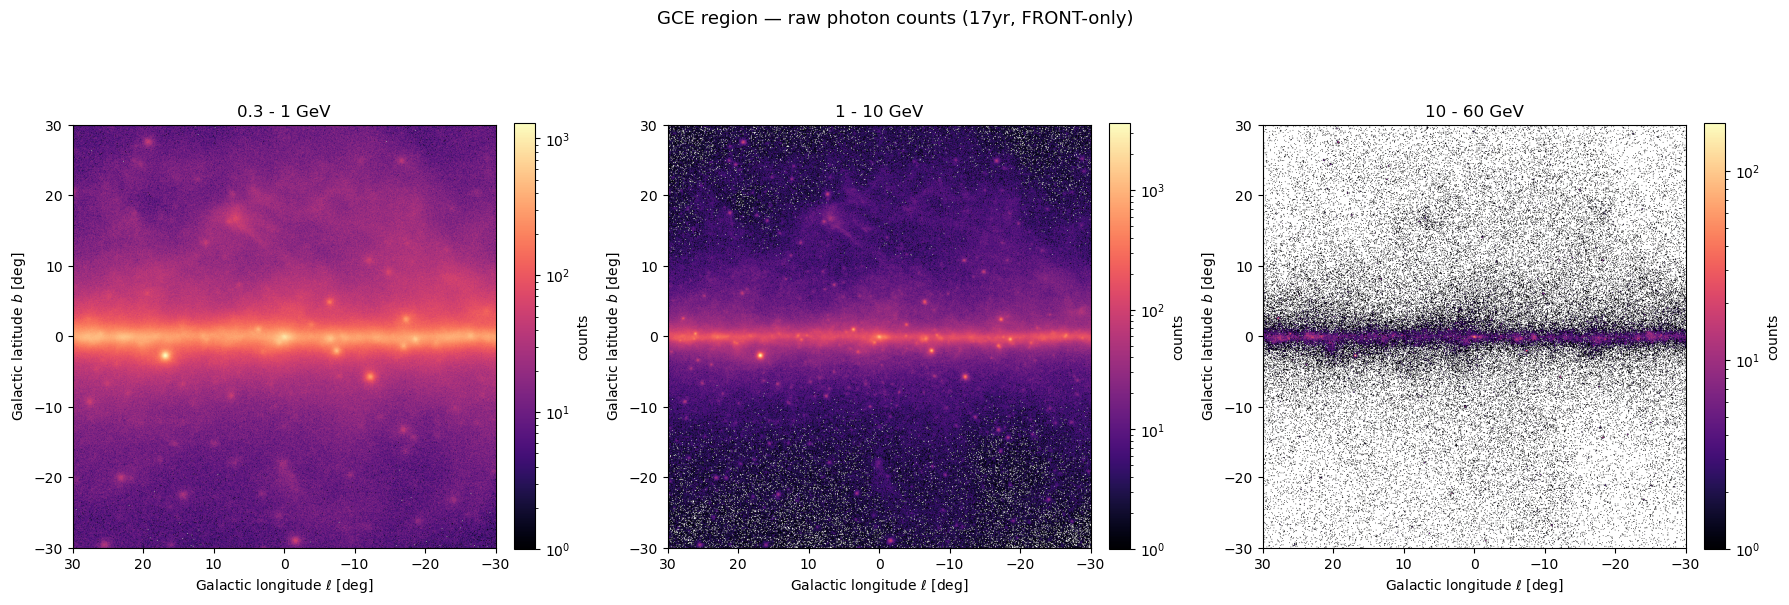

In [51]:
# Cell 6 — Plot 1: GCE counts map (3 E bands)
ccube_path = f'{ANALYSIS_DIR}/GC_ccube_17yr{FRONT}_clean.fits'
hdul = fits.open(ccube_path)
counts_cube = hdul[0].data
header      = hdul[0].header
n_E_full, ny, nx = counts_cube.shape

E_bounds = hdul[1].data
E_arr_ccube = np.array([np.sqrt(b['E_MIN'] * b['E_MAX'] * 1e-6) * 1e-3
                        for b in E_bounds])
print(f'CCUBE: shape={counts_cube.shape}, E ∈ [{E_arr_ccube[0]:.3f}, '
      f'{E_arr_ccube[-1]:.1f}] GeV')

# 3 E bands (Daylan-style)
bands = [
    (0.3, 1.0,  '0.3 - 1 GeV'),
    (1.0, 10.0, '1 - 10 GeV'),
    (10.0, 60.0,'10 - 60 GeV'),
]

extent = [-30, 30, -30, 30]   # 600 px × 0.1°/px = 60° centred on GC

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (e_lo, e_hi, label) in zip(axes, bands):
    sel = (E_arr_ccube >= e_lo) & (E_arr_ccube <= e_hi)
    summed = counts_cube[sel].sum(axis=0)
    im = ax.imshow(summed, origin='lower', cmap='magma',
                   extent=extent,
                   norm=LogNorm(vmin=max(1, summed.min() + 1), vmax=summed.max()))
    ax.set_title(label, fontsize=12)
    ax.set_xlabel(r'Galactic longitude $\ell$ [deg]')
    ax.set_ylabel('Galactic latitude $b$ [deg]')
    ax.invert_xaxis()  # ℓ increases to the left (astronomical convention)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='counts')

plt.suptitle('GCE region — raw photon counts (17yr, FRONT-only)', y=1.02, fontsize=13)
plt.tight_layout()
out = f'{PLOTS_DIR}/01_gce_map.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
print(f'[saved] {out}')
plt.show()


## Plot 2 — Masked Map

PSC + disk mask applied to the CCUBE, showing the area actually used in the fit.


[saved] ./GCE_17yr_results_plots/02_masked_map.png


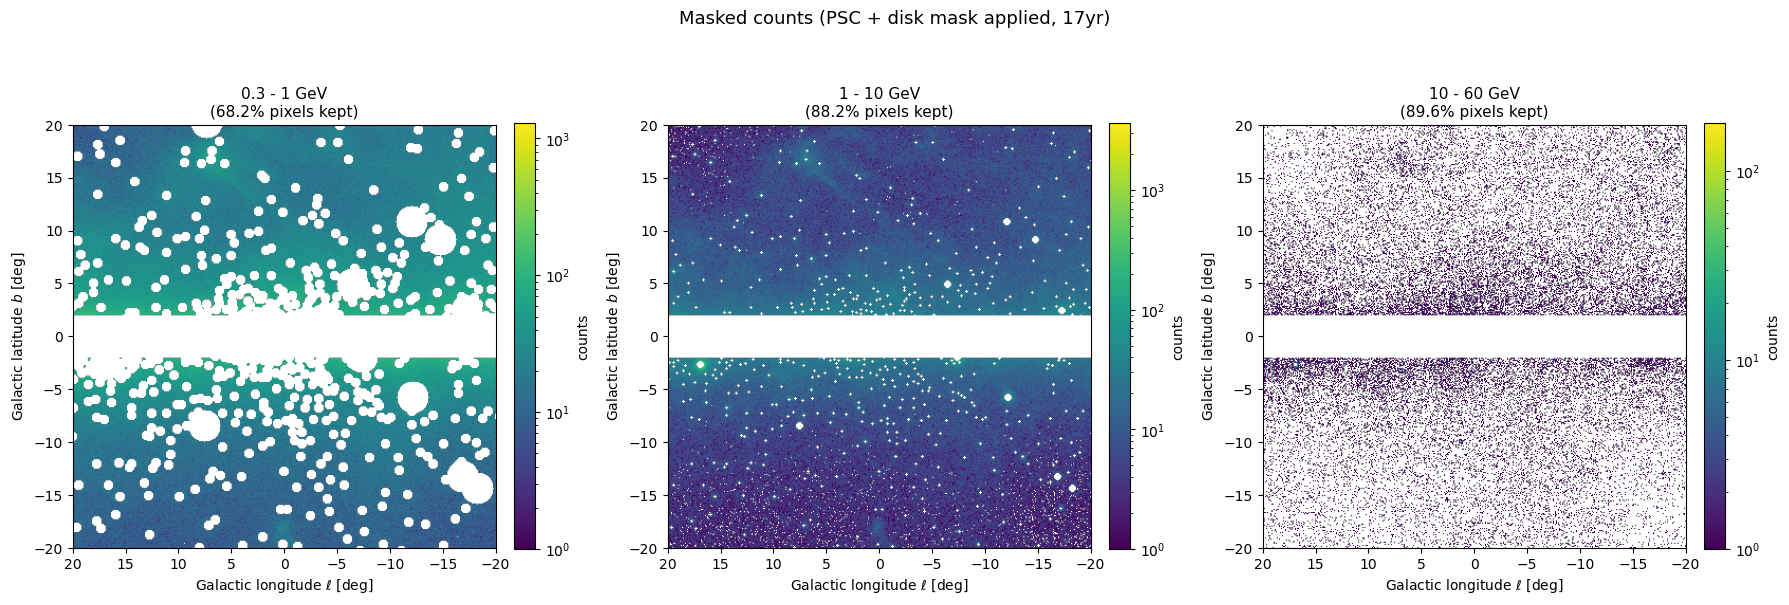

In [52]:
# Cell 7 — Plot 2: Masked counts map (PSC + disk mask)
psc_mask_path  = f'{ANALYSIS_DIR}/Model/GC_mask_60x60_definitions_FL16Y.npy'
disk_mask_path = f'{ANALYSIS_DIR}/Model/GC_disk_mask_60x60_definitions.npy'

psc_mask  = np.load(psc_mask_path)
disk_mask = np.load(disk_mask_path)

# Inner ROI 400×400 (40°×40°)
psc_inner   = psc_mask[:, 100:500, 100:500]
disk_inner  = disk_mask[100:500, 100:500]
counts_inner = counts_cube[:, 100:500, 100:500]
full_inner   = psc_inner * disk_inner[None, :, :]

extent_inner = [-20, 20, -20, 20]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (e_lo, e_hi, label) in zip(axes, bands):
    sel = (E_arr_ccube >= e_lo) & (E_arr_ccube <= e_hi)
    summed = counts_inner[sel].sum(axis=0)
    mask_b = full_inner[sel].max(axis=0)
    masked_disp = np.where(mask_b == 1, summed, np.nan)

    im = ax.imshow(masked_disp, origin='lower', cmap='viridis',
                   extent=extent_inner,
                   norm=LogNorm(vmin=1, vmax=summed.max()))
    frac_kept = mask_b.sum() / mask_b.size
    ax.set_title(f'{label}\n({frac_kept * 100:.1f}% pixels kept)', fontsize=11)
    ax.set_xlabel(r'Galactic longitude $\ell$ [deg]')
    ax.set_ylabel('Galactic latitude $b$ [deg]')
    ax.invert_xaxis()
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='counts')

plt.suptitle('Masked counts (PSC + disk mask applied, 17yr)', y=1.02, fontsize=13)
plt.tight_layout()
out = f'{PLOTS_DIR}/02_masked_map.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
print(f'[saved] {out}')
plt.show()


## Catalog comparison — 4FGL-DR2 vs FL16Y point sources

Reads the FL16Y point-source catalog (`gll_psc_v40.fit`) directly and computes the source counts and class breakdown in the analysis ROI. If a 4FGL-DR2 catalog file or the 12yr PSC XML is available, also lists the per-catalog totals for direct comparison.


FL16Y catalog: ./GC_analysis_FL16Y/gll_psc_v40.fit

FL16Y total PSC      (full sky): 7224
FL16Y total extended (full sky): 83

In ROI 60deg x 60deg : 1130 PSC + 27 extended = 1157
In ROI 40deg x 40deg : 681 PSC + 12 extended = 693

Newly found in FL16Y (no 4FGL_DR1/2/3 counterpart):
  ROI 60deg:  111 / 1130 (  9.8%)
  ROI 40deg:   69 / 681 ( 10.1%)

CLASS1 distribution in ROI 60deg (top 12):
  (unassoc)        590
  bcu              147
  bll               77
  unk               67
  spp               56
  MSP               38
  PSR               36
  fsrq              34
  glc               23
  msp               10
  bin                7
  SNR                6

Signif_Avg (~ sqrt(TS)) distribution in ROI 60deg:
  median: 7.4, max: 434.0
  Signif_Avg > 5  (TS > 25):   930
  Signif_Avg > 7  (TS > 49):   620    <- FL16Y theta_s/theta_l split
  Signif_Avg > 10 (TS > 100):  367

4FGL-DR2 PSC XML (12yr analysis): /home/haebarg/GCE-Chi-square-fitting/GCE_12yr_reproduce/GC_analysis_sanghwan/

  Number of <source> entries (point + diffuse + extended): 1176
    point source (SkyDirFunction):     1142
    extended (SpatialMap/Disk/Gauss):  34
    other (diffuse / isotropic etc):   0


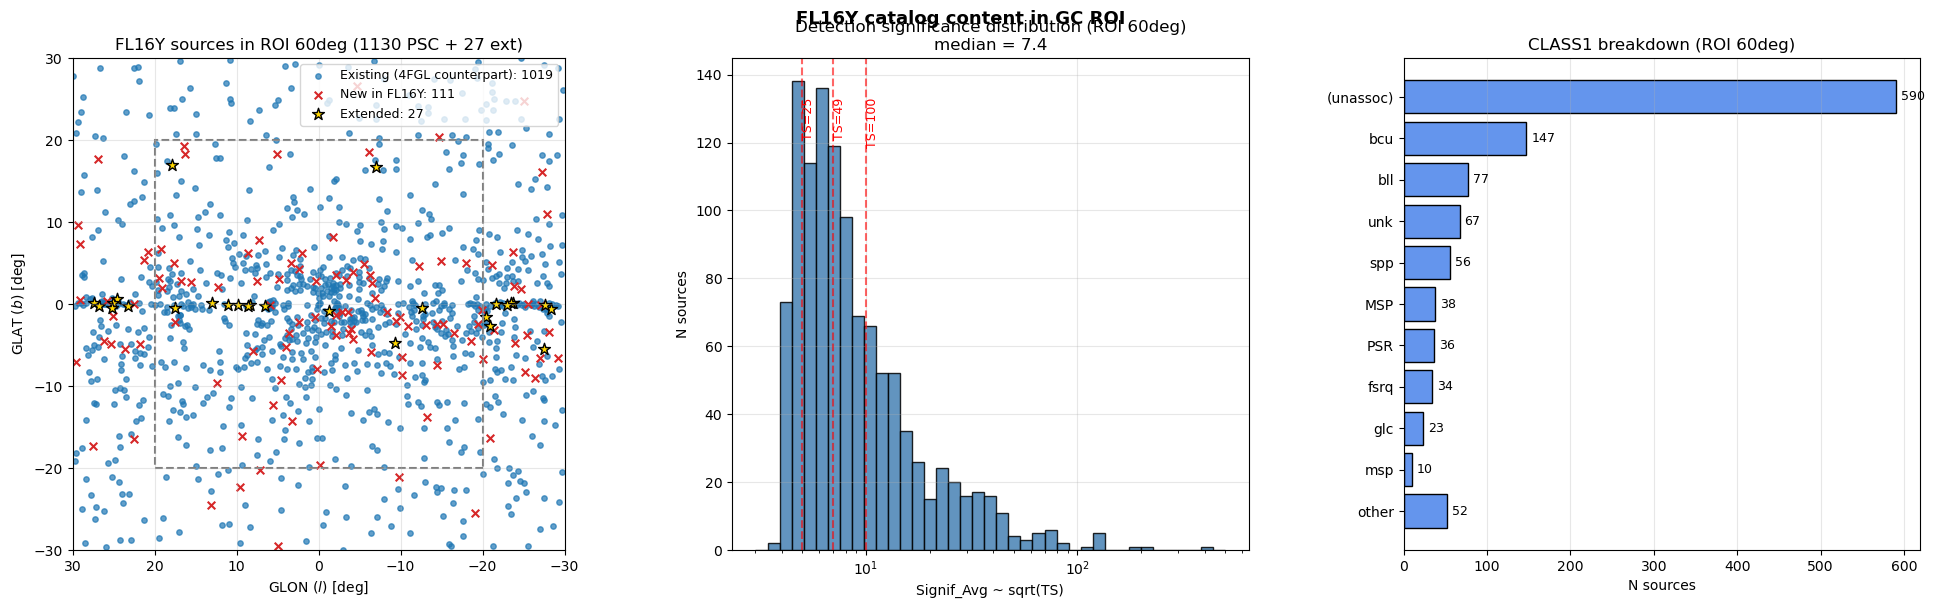


saved: ./GCE_17yr_results_plots/02a_catalog_FL16Y_breakdown.png


In [53]:
# Cell 7a - Catalog content comparison: 4FGL-DR2 vs FL16Y
# ---------------------------------------------------------
# Reads FL16Y FITS catalog and (optionally) DR2 source XML to count sources in ROI,
# break down by association status (new vs existing in 4FGL family), source class,
# and Signif_Avg distribution.
import xml.etree.ElementTree as ET

# Catalog file paths — try common locations, graceful skip if missing
FL16Y_FITS_CANDIDATES = [
    f'{ANALYSIS_DIR}/Model/gll_psc_v40.fit',
    f'{ANALYSIS_DIR}/gll_psc_v40.fit',
    f'./gll_psc_v40.fit',
    '/home/haebarg/GCE-Chi-square-fitting/GCE_17yr_reproduce/gll_psc_v40.fit',
]
DR2_XML_CANDIDATES = [
    '/home/haebarg/GCE-Chi-square-fitting/GCE_12yr_reproduce/GC_analysis_sanghwan/Model/GC_psc_model_DR2.xml',
]

def _first_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return None

fl16y_path = _first_existing(FL16Y_FITS_CANDIDATES)
dr2_path   = _first_existing(DR2_XML_CANDIDATES)

if fl16y_path is None:
    print('[skip] FL16Y catalog FITS not found in candidate paths.')
    print('       Tried:')
    for p in FL16Y_FITS_CANDIDATES:
        print(f'         {p}')
else:
    print(f'FL16Y catalog: {fl16y_path}')
    cat = fits.open(fl16y_path)
    psc = cat[1].data    # LAT_Point_Source_Catalog
    ext = cat[2].data    # ExtendedSources

    # Galactic coordinates with GLON wrap to [-180, 180]
    glon      = psc['GLON']
    glat      = psc['GLAT']
    glon_wrap = np.where(glon > 180, glon - 360, glon)
    ext_glon      = ext['GLON']
    ext_glat      = ext['GLAT']
    ext_glon_wrap = np.where(ext_glon > 180, ext_glon - 360, ext_glon)

    # ROI definitions
    roi60 = (np.abs(glon_wrap)     <= 30) & (np.abs(glat)     <= 30)
    roi40 = (np.abs(glon_wrap)     <= 20) & (np.abs(glat)     <= 20)
    ext60 = (np.abs(ext_glon_wrap) <= 30) & (np.abs(ext_glat) <= 30)
    ext40 = (np.abs(ext_glon_wrap) <= 20) & (np.abs(ext_glat) <= 20)

    n_psc_60 = int(roi60.sum()); n_ext_60 = int(ext60.sum())
    n_psc_40 = int(roi40.sum()); n_ext_40 = int(ext40.sum())

    print()
    print(f'FL16Y total PSC      (full sky): {len(psc)}')
    print(f'FL16Y total extended (full sky): {len(ext)}')
    print()
    print(f'In ROI 60deg x 60deg : {n_psc_60} PSC + {n_ext_60} extended = {n_psc_60 + n_ext_60}')
    print(f'In ROI 40deg x 40deg : {n_psc_40} PSC + {n_ext_40} extended = {n_psc_40 + n_ext_40}')

    # ASSOC_FGL based novelty: source has no 4FGL counterpart -> new in FL16Y
    def _empty_assoc(s):
        return s.strip() == '' or s.strip().lower() == 'none'
    assoc_60 = psc['ASSOC_FGL'][roi60]
    new_60 = np.array([_empty_assoc(s) for s in assoc_60])
    assoc_40 = psc['ASSOC_FGL'][roi40]
    new_40 = np.array([_empty_assoc(s) for s in assoc_40])

    print()
    print(f'Newly found in FL16Y (no 4FGL_DR1/2/3 counterpart):')
    print(f'  ROI 60deg: {new_60.sum():4d} / {n_psc_60} ({100*new_60.sum()/n_psc_60:5.1f}%)')
    print(f'  ROI 40deg: {new_40.sum():4d} / {n_psc_40} ({100*new_40.sum()/n_psc_40:5.1f}%)')

    # CLASS1 distribution in ROI 60
    print()
    print('CLASS1 distribution in ROI 60deg (top 12):')
    class1 = psc['CLASS1'][roi60]
    cleaned = np.array([c.strip() if c.strip() else '(unassoc)' for c in class1])
    unique, counts = np.unique(cleaned, return_counts=True)
    sort_idx = np.argsort(-counts)
    for u, c in zip(unique[sort_idx][:12], counts[sort_idx][:12]):
        print(f'  {u:<15} {c:>4}')

    # Signif_Avg distribution
    sig60 = psc['Signif_Avg'][roi60]
    print()
    print('Signif_Avg (~ sqrt(TS)) distribution in ROI 60deg:')
    print(f'  median: {np.nanmedian(sig60):.1f}, max: {np.nanmax(sig60):.1f}')
    print(f'  Signif_Avg > 5  (TS > 25):  {(sig60 > 5).sum():4d}')
    print(f'  Signif_Avg > 7  (TS > 49):  {(sig60 > 7).sum():4d}    <- FL16Y theta_s/theta_l split')
    print(f'  Signif_Avg > 10 (TS > 100): {(sig60 > 10).sum():4d}')

# DR2 XML count for direct comparison
if dr2_path is None:
    print()
    print('[note] 4FGL-DR2 PSC XML not found; FL16Y stats only.')
else:
    print()
    print(f'4FGL-DR2 PSC XML (12yr analysis): {dr2_path}')
    tree = ET.parse(dr2_path)
    root = tree.getroot()
    dr2_sources = root.findall('source')
    n_dr2 = len(dr2_sources)
    print(f'  Number of <source> entries (point + diffuse + extended): {n_dr2}')

    # Count by point vs extended (the XML mixes them; differentiate by spatialModel)
    n_dr2_point = 0; n_dr2_ext = 0; n_dr2_diff = 0
    for s in dr2_sources:
        sm = s.find('spatialModel')
        if sm is None:
            continue
        sm_type = sm.get('type', '')
        if sm_type == 'SkyDirFunction':
            n_dr2_point += 1
        elif sm_type in ('SpatialMap', 'RadialDisk', 'RadialGaussian'):
            n_dr2_ext += 1
        else:
            n_dr2_diff += 1
    print(f'    point source (SkyDirFunction):     {n_dr2_point}')
    print(f'    extended (SpatialMap/Disk/Gauss):  {n_dr2_ext}')
    print(f'    other (diffuse / isotropic etc):   {n_dr2_diff}')

# Visualization: 3-panel summary of FL16Y in ROI
if fl16y_path is not None:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Panel 1: source positions (l, b) in ROI 60, colored by new/existing
    ax = axes[0]
    glon_60 = glon_wrap[roi60]
    glat_60 = glat[roi60]
    ax.scatter(glon_60[~new_60], glat_60[~new_60], s=15, c='C0', alpha=0.7,
               label=f'Existing (4FGL counterpart): {(~new_60).sum()}')
    ax.scatter(glon_60[ new_60], glat_60[ new_60], s=30, c='C3', marker='x',
               label=f'New in FL16Y: {new_60.sum()}')
    # Extended sources too
    ax.scatter(ext_glon_wrap[ext60], ext_glat[ext60], s=80, marker='*',
               edgecolor='black', facecolor='gold', label=f'Extended: {n_ext_60}')
    # Inner 40 deg ROI box
    rect = plt.Rectangle((-20, -20), 40, 40, fill=False, ec='gray', ls='--', lw=1.5)
    ax.add_patch(rect)
    ax.set_xlim(30, -30); ax.set_ylim(-30, 30)
    ax.set_xlabel(r'GLON ($l$) [deg]'); ax.set_ylabel(r'GLAT ($b$) [deg]')
    ax.set_title(f'FL16Y sources in ROI 60deg ({n_psc_60} PSC + {n_ext_60} ext)')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

    # Panel 2: Signif_Avg histogram (log)
    ax = axes[1]
    sig_clean = sig60[~np.isnan(sig60)]
    bins = np.logspace(np.log10(3), np.log10(500), 40)
    ax.hist(sig_clean, bins=bins, color='steelblue', edgecolor='black', alpha=0.85)
    for v, lbl in [(5, 'TS=25'), (7, 'TS=49'), (10, 'TS=100')]:
        ax.axvline(v, ls='--', color='red', alpha=0.6)
        ax.text(v, ax.get_ylim()[1]*0.92, ' '+lbl, fontsize=9, color='red',
                rotation=90, va='top')
    ax.set_xscale('log')
    ax.set_xlabel('Signif_Avg ~ sqrt(TS)'); ax.set_ylabel('N sources')
    ax.set_title(f'Detection significance distribution (ROI 60deg)\nmedian = {np.nanmedian(sig60):.1f}')
    ax.grid(True, alpha=0.3)

    # Panel 3: CLASS1 breakdown bar chart
    ax = axes[2]
    top_n = 10
    cls_top = unique[sort_idx][:top_n]
    cnt_top = counts[sort_idx][:top_n]
    other = counts[sort_idx][top_n:].sum() if len(counts) > top_n else 0
    if other > 0:
        cls_top = np.append(cls_top, 'other')
        cnt_top = np.append(cnt_top, other)
    bars = ax.barh(np.arange(len(cls_top))[::-1], cnt_top, color='cornflowerblue', edgecolor='black')
    for bar, n in zip(bars, cnt_top):
        ax.text(bar.get_width() + max(cnt_top)*0.01, bar.get_y() + bar.get_height()/2,
                f'{n}', va='center', fontsize=9)
    ax.set_yticks(np.arange(len(cls_top))[::-1])
    ax.set_yticklabels(cls_top)
    ax.set_xlabel('N sources')
    ax.set_title(f'CLASS1 breakdown (ROI 60deg)')
    ax.grid(True, alpha=0.3, axis='x')

    fig.suptitle(f'FL16Y catalog content in GC ROI', fontsize=13, fontweight='bold', y=1.00)
    fig.subplots_adjust(top=0.92, bottom=0.10, left=0.05, right=0.98, wspace=0.30)

    out = f'{PLOTS_DIR}/02a_catalog_FL16Y_breakdown.png'
    plt.savefig(out, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'\nsaved: {out}')


## Mask Comparison — 4FGL-DR2 (12yr) vs FL16Y (17yr)

Catalog upgrade from 4FGL-DR2 to FL16Y identifies more PSCs near GC, particularly affecting low-energy bins where PSF is largest. Reproduces the side-by-side comparison from the slide.


12yr PSC: (17, 600, 600)  CCUBE: (17, 600, 600)
17yr PSC: (14, 600, 600)  CCUBE: (14, 600, 600)

Per-bin pixel retention (PSC * disk):
  bin  E[GeV]      DR2 60d     FL 60d     d 60d    DR2 40d     FL 40d     d 40d
  --------------------------------------------------------------------------------------------
  0    0.313         37.8%      30.9%     -7.0%      28.2%      24.5%     -3.8%
  1    0.407         47.1%      40.5%     -6.6%      37.1%      32.9%     -4.2%
  2    0.529         58.5%      52.9%     -5.7%      48.8%      44.6%     -4.1%
  3    0.688         70.1%      66.0%     -4.1%      61.5%      58.1%     -3.4%
  4    0.894         78.1%      75.3%     -2.8%      70.8%      68.2%     -2.7%
  5    1.160         82.8%      80.8%     -2.0%      76.6%      74.6%     -2.0%
  6    1.507         87.1%      85.9%     -1.2%      82.0%      80.7%     -1.2%
  7    1.963         88.5%      87.5%     -1.0%      83.7%      82.6%     -1.1%
  8    2.553         91.0%      90.5%     -0.5%   

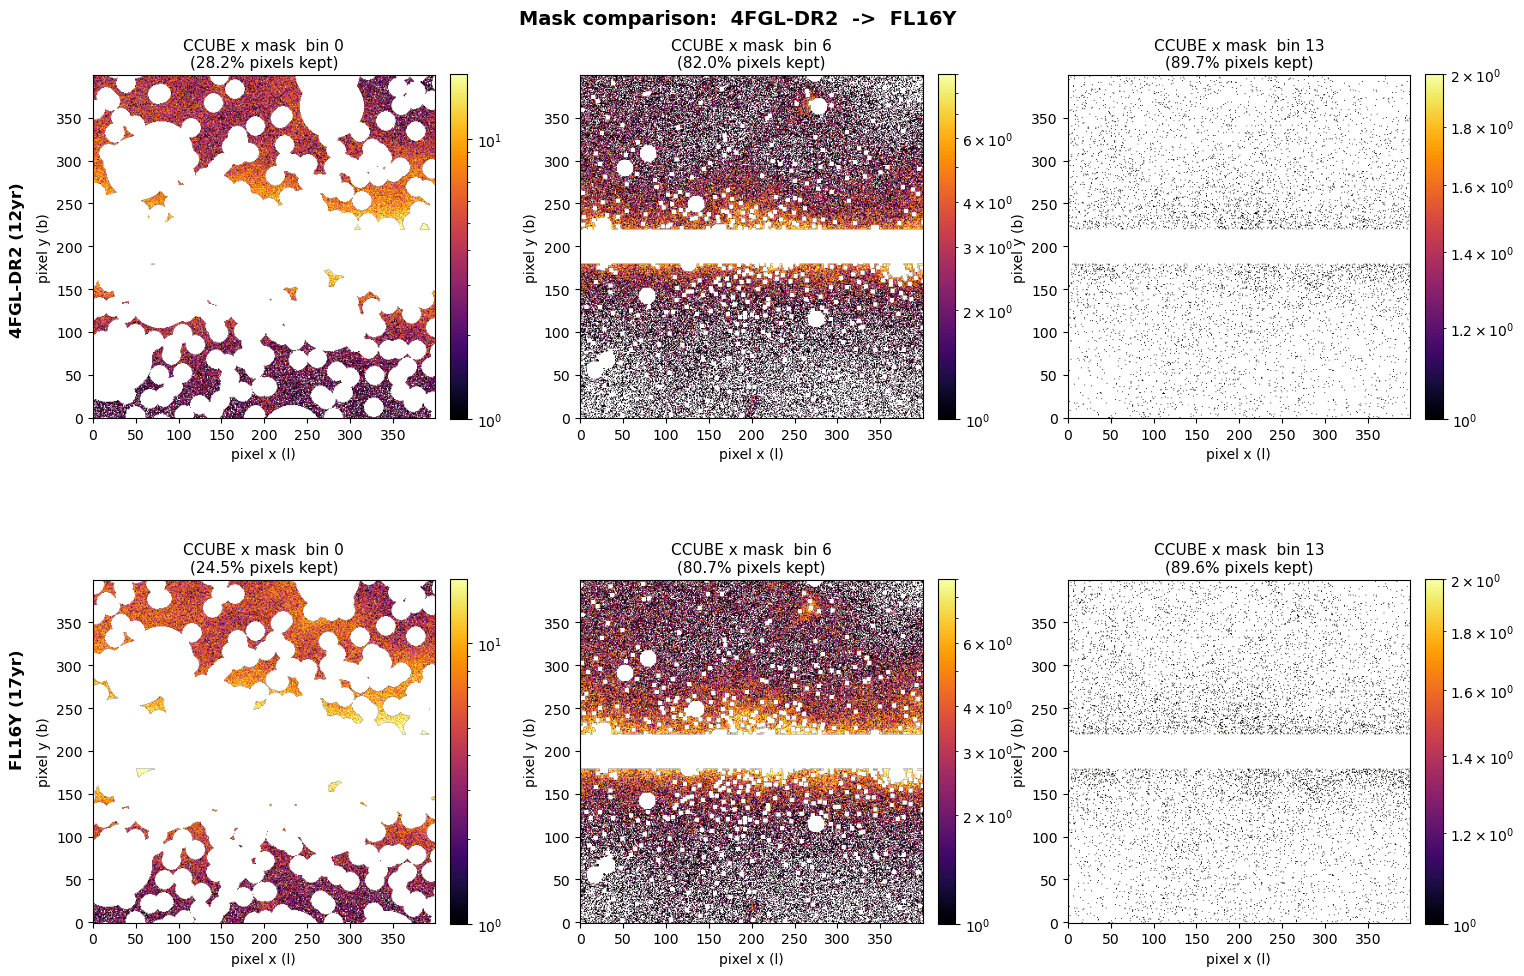


saved: ./GCE_17yr_results_plots/02b_mask_comparison_DR2_vs_FL16Y.png


In [54]:
# Cell 7b - Mask comparison: 4FGL-DR2 (12yr) vs FL16Y (17yr)
# ----------------------------------------------------------------
DR2_BASE      = '/home/haebarg/GCE-Chi-square-fitting/GCE_12yr_reproduce'
DR2_PSC_MASK  = f'{DR2_BASE}/GC_analysis_sanghwan/Model/GC_mask_60x60_definitions_DR2.npy'
DR2_DISK_MASK = f'{DR2_BASE}/GC_analysis_sanghwan/Model/GC_disk_mask_60x60_definitions.npy'
DR2_CCUBE     = f'{DR2_BASE}/GC_analysis_sanghwan/GC_ccube_12yr_front_clean.fits'
FL16Y_PSC_MASK = f'{ANALYSIS_DIR}/Model/GC_mask_60x60_definitions_FL16Y.npy'
FL16Y_DISK_MASK = f'{ANALYSIS_DIR}/Model/GC_disk_mask_60x60_definitions.npy'
FL16Y_CCUBE    = f'{ANALYSIS_DIR}/GC_ccube_17yr{FRONT}_clean.fits'

_paths = {
    '12yr PSC':   DR2_PSC_MASK,  '12yr disk':  DR2_DISK_MASK,  '12yr CCUBE': DR2_CCUBE,
    '17yr PSC':   FL16Y_PSC_MASK, '17yr disk':  FL16Y_DISK_MASK, '17yr CCUBE': FL16Y_CCUBE,
}
_missing = [k for k, v in _paths.items() if not os.path.exists(v)]
if _missing:
    print(f'[skip] mask comparison: missing {_missing}')
else:
    psc_dr2  = np.load(DR2_PSC_MASK)
    disk_dr2 = np.load(DR2_DISK_MASK)
    psc_16y  = np.load(FL16Y_PSC_MASK)
    disk_16y = np.load(FL16Y_DISK_MASK)
    ccube_dr2  = fits.open(DR2_CCUBE)[0].data
    ccube_16y  = fits.open(FL16Y_CCUBE)[0].data
    print(f'12yr PSC: {psc_dr2.shape}  CCUBE: {ccube_dr2.shape}')
    print(f'17yr PSC: {psc_16y.shape}  CCUBE: {ccube_16y.shape}')

    n_bc = min(psc_dr2.shape[0], psc_16y.shape[0])
    full_dr2 = (psc_dr2[:n_bc] * disk_dr2[None]).astype(bool)
    full_16y = (psc_16y[:n_bc] * disk_16y[None]).astype(bool)
    SL = (slice(100, 500), slice(100, 500))
    inner_size = 400 * 400
    full_size  = 600 * 600

    print()
    print('Per-bin pixel retention (PSC * disk):')
    print(f'  {"bin":<4} {"E[GeV]":<8}  {"DR2 60d":>9} {"FL 60d":>10} {"d 60d":>9}  {"DR2 40d":>9} {"FL 40d":>10} {"d 40d":>9}')
    print('  ' + '-' * 92)
    rows = []
    for k in range(n_bc):
        r60_dr2 = full_dr2[k].sum() / full_size * 100
        r60_16y = full_16y[k].sum() / full_size * 100
        r40_dr2 = full_dr2[k][SL].sum() / inner_size * 100
        r40_16y = full_16y[k][SL].sum() / inner_size * 100
        E_k = E[k] if (E is not None and k < n_bins) else float('nan')
        print(f'  {k:<4} {E_k:<8.3f}  '
              f'{r60_dr2:>8.1f}% {r60_16y:>9.1f}% {r60_16y - r60_dr2:>+8.1f}%  '
              f'{r40_dr2:>8.1f}% {r40_16y:>9.1f}% {r40_16y - r40_dr2:>+8.1f}%')
        rows.append((k, E_k, r60_dr2, r60_16y, r40_dr2, r40_16y))

    BINS_TO_PLOT = [0, 6, 13] if n_bc >= 14 else [0, n_bc//2, n_bc-1]

    fig, axes = plt.subplots(2, len(BINS_TO_PLOT), figsize=(5*len(BINS_TO_PLOT), 10))

    for col, bin_idx in enumerate(BINS_TO_PLOT):
        img_dr2 = (ccube_dr2[bin_idx] * full_dr2[bin_idx])[SL]
        img_16y = (ccube_16y[bin_idx] * full_16y[bin_idx])[SL]
        kept_dr2 = full_dr2[bin_idx][SL].sum() / inner_size * 100
        kept_16y = full_16y[bin_idx][SL].sum() / inner_size * 100

        vmax = max(np.percentile(img_dr2[img_dr2 > 0], 99) if (img_dr2 > 0).any() else 1,
                   np.percentile(img_16y[img_16y > 0], 99) if (img_16y > 0).any() else 1)
        vmin = max(0.5, min(np.percentile(img_dr2[img_dr2 > 0], 1) if (img_dr2 > 0).any() else 0.5,
                            np.percentile(img_16y[img_16y > 0], 1) if (img_16y > 0).any() else 0.5))

        ax_t = axes[0, col]
        im_t = ax_t.imshow(img_dr2, origin='lower', cmap='inferno', norm=LogNorm(vmin=vmin, vmax=vmax))
        ax_t.set_title(f'CCUBE x mask  bin {bin_idx}\n({kept_dr2:.1f}% pixels kept)', fontsize=11)
        ax_t.set_xlabel('pixel x (l)'); ax_t.set_ylabel('pixel y (b)')
        plt.colorbar(im_t, ax=ax_t, fraction=0.046, pad=0.04)

        ax_b = axes[1, col]
        im_b = ax_b.imshow(img_16y, origin='lower', cmap='inferno', norm=LogNorm(vmin=vmin, vmax=vmax))
        ax_b.set_title(f'CCUBE x mask  bin {bin_idx}\n({kept_16y:.1f}% pixels kept)', fontsize=11)
        ax_b.set_xlabel('pixel x (l)'); ax_b.set_ylabel('pixel y (b)')
        plt.colorbar(im_b, ax=ax_b, fraction=0.046, pad=0.04)

    fig.suptitle('Mask comparison:  4FGL-DR2  ->  FL16Y', fontsize=14, fontweight='bold', y=0.98)
    fig.text(0.015, 0.73, '4FGL-DR2 (12yr)', rotation=90, va='center', fontsize=12, fontweight='bold')
    fig.text(0.015, 0.28, 'FL16Y (17yr)',    rotation=90, va='center', fontsize=12, fontweight='bold')
    fig.subplots_adjust(top=0.92, bottom=0.06, left=0.07, right=0.97, hspace=0.42, wspace=0.30)

    out = f'{PLOTS_DIR}/02b_mask_comparison_DR2_vs_FL16Y.png'
    plt.savefig(out, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'\nsaved: {out}')


## Plot 3 — SED Decomposition (NEW)

Single-model decomposition of the GCE region SED into the 5 background components
plus the GCE template, with fit coefficients applied. Ported from 12yr V2.

- π⁰+bremss, ICS, Fermi bubble, isotropic — backgrounds
- GCE — main signal (best-fit per-bin flux with 1σ band)
- Observed (CCUBE-masked) — black markers
- Sum of fitted components — gray dashed line (should overlap with observed)

Requires component templates and fit coefficients loaded in the previous cell.


[saved] ./GCE_17yr_results_plots/03_SED_decomposition_X.png


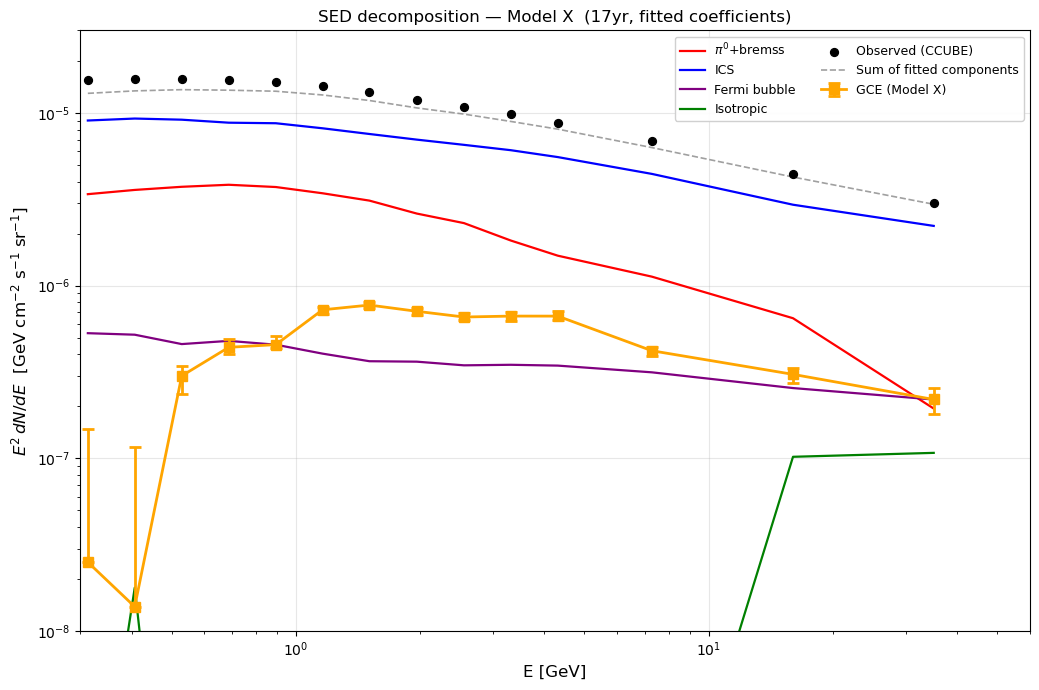

  Sum/obs ratio (1-10 GeV mean): 0.906 — ⚠ residual -9% (1-10 GeV)


In [55]:
# Cell 8 — Plot 3: Single-model SED decomposition (5 components + GCE + observed)
if (E is None) or (pion is None) or (delta_E is None):
    print('[skip] missing E / components / delta_E — re-run Cell 5')
else:
    n = len(E)
    have_coefs = (c_pion is not None)
    if not have_coefs:
        c_pion = c_ics = c_gce = c_bub = c_iso = np.ones(n)
        title_tag = 'raw templates (c=1 fallback)'
    else:
        title_tag = 'fitted coefficients'

    E2_dE = E**2 / delta_E

    pb_sed  = c_pion * (pion + bremss) * E2_dE
    ics_sed = c_ics  * ics             * E2_dE
    bub_sed = c_bub  * bubble          * E2_dE
    iso_sed = c_iso  * isotropic       * E2_dE

    # observed = (counts/exp/sr) × E²/dE
    obs_E2dN = counts_per_exp * E2_dE

    fig, ax = plt.subplots(figsize=(10.5, 7))
    ax.plot(E, pb_sed,  color='red',     lw=1.6, label=r'$\pi^0$+bremss')
    ax.plot(E, ics_sed, color='blue',    lw=1.6, label='ICS')
    ax.plot(E, bub_sed, color='purple',  lw=1.6, label='Fermi bubble')
    ax.plot(E, iso_sed, color='green',   lw=1.6, label='Isotropic')

    # Observed
    ax.scatter(E, obs_E2dN, color='black', marker='o', s=32,
               zorder=10, label='Observed (CCUBE)')

    # GCE: use main .dat results (asymmetric error bars)
    ref = all_flux[SELECTED_MODEL]
    yerr_lo = np.maximum(ref['flux'] - ref['lower'], 0)
    yerr_hi = np.maximum(ref['upper'] - ref['flux'], 0)
    ax.errorbar(E, ref['flux'], yerr=[yerr_lo, yerr_hi],
                ls='-', marker='s', color='orange', ms=7, lw=2,
                elinewidth=2, capsize=4, capthick=2,
                label=f'GCE (Model {SELECTED_MODEL})')

    # Sum of fitted
    if have_coefs:
        total = pb_sed + ics_sed + bub_sed + iso_sed + ref['flux']
        ax.plot(E, total, color='gray', ls='--', lw=1.2, alpha=0.75,
                label='Sum of fitted components')

    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(0.3, 60);  ax.set_ylim(1e-8, 3e-5)
    ax.set_xlabel('E [GeV]', fontsize=12)
    ax.set_ylabel(r'$E^2\,dN/dE$  [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', fontsize=12)
    ax.set_title(f'SED decomposition — Model {SELECTED_MODEL}  '
                 f'(17yr, {title_tag})', fontsize=12)
    ax.grid(True, alpha=0.3, which='major')
    ax.legend(loc='upper right', ncol=2, fontsize=9, framealpha=0.92)

    plt.tight_layout()
    out = f'{PLOTS_DIR}/03_SED_decomposition_{SELECTED_MODEL}.png'
    plt.savefig(out, dpi=130, bbox_inches='tight')
    print(f'[saved] {out}')
    plt.show()

    # Brief quality check
    if have_coefs and not np.isnan(obs_E2dN).all():
        sum_tot = pb_sed + ics_sed + bub_sed + iso_sed + ref['flux']
        with np.errstate(invalid='ignore', divide='ignore'):
            ratio = sum_tot / obs_E2dN
        m_in = (E >= 1) & (E <= 10)
        if m_in.any():
            r_mean = np.nanmean(ratio[m_in])
            verdict = ('✓ converged' if 0.95 < r_mean < 1.05
                       else f'⚠ residual {(r_mean - 1)*100:+.0f}% (1-10 GeV)')
            print(f'  Sum/obs ratio (1-10 GeV mean): {r_mean:.3f} — {verdict}')


## Plot 3b — Per-model post-fit SED decomposition + selected-bin breakdown

Reimplements the 16yr main-notebook **cell-59** component SED (dropped during the 17yr pipeline migration; logic matches `export_postfit_sed.py` / `run_one_model.py` L500-519). Set `PLOT_MODEL` and `PLOT_BIN`:

- **Left** — full 14-bin post-fit decomposition: raw data (errorbar), π⁰+brem, ICS, GCE, bubble, iso each as `c·template·E²/ΔE` with asymmetric chain band (`fitted_params_lower/upper`), plus the summed total. Selected bin marked with a guide.
- **Right** — the selected bin's component breakdown with chain error bars + the per-bin coefficient values (surfaces the bin 0–1 `c_iso→0` / FL16Y-mask boundary-stuck pathology honestly, not hidden).

`SAVE_V28D=True` also writes the 16-column V28d post-fit table (restores the dropped pipeline export). Templates use `_no_convol`, `[100:500,100:500]` slice, disk-mask-only average, `/exp_cube` (sr folded in) — identical convention to Cell 5.

[saved] ./GCE_17yr_results_plots/03b_postfit_SED_X_bin0.png


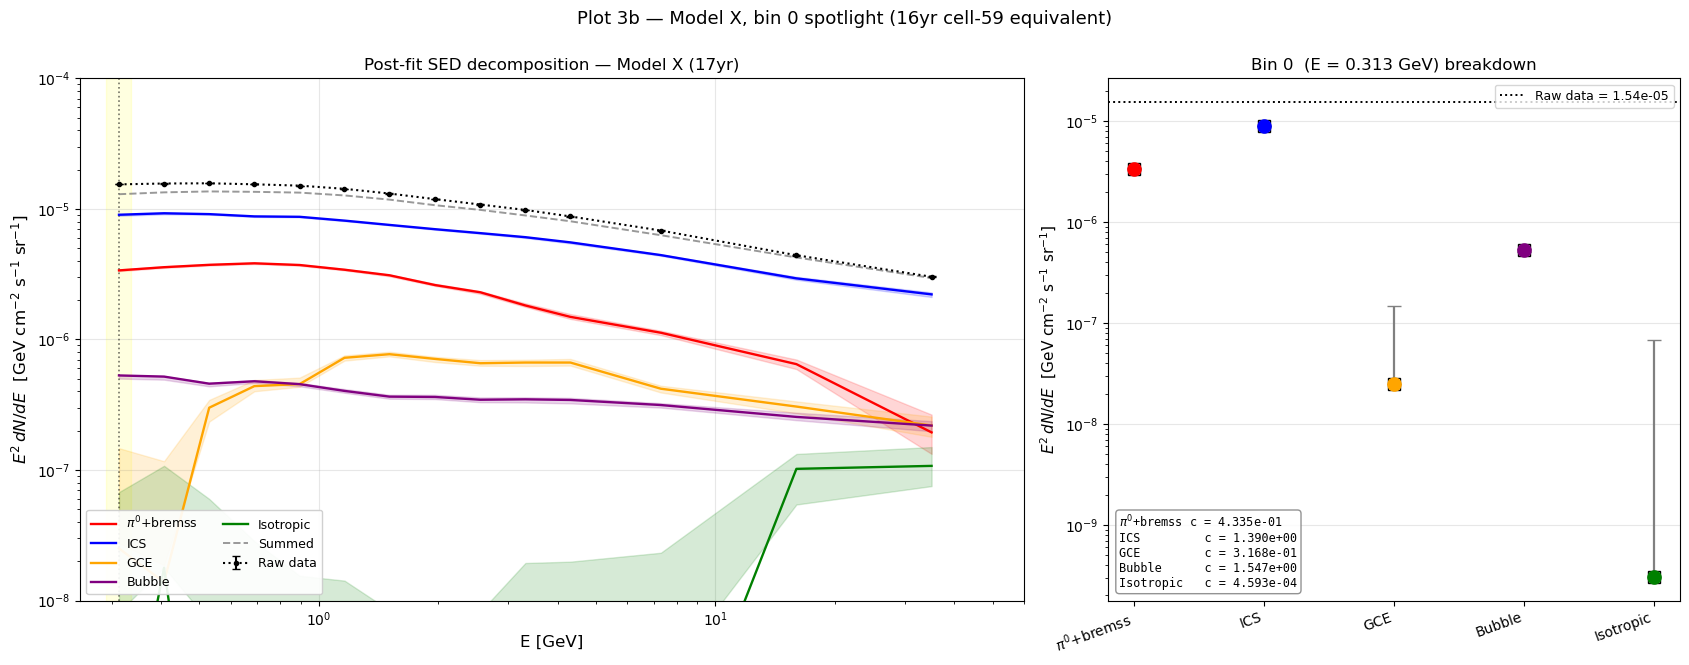

[saved] ./postfit_sed_v28d/V_17yr_postfit_ModelX_front.txt

Bin 0  E = 0.3133 GeV   Model X
  raw data        = 1.5411e-05
  $\pi^0$+bremss c=4.3354e-01  SED=3.3799e-06 [3.337e-06, 3.437e-06]
  ICS           c=1.3902e+00  SED=9.0199e-06 [8.855e-06, 9.018e-06]
  GCE           c=3.1679e-01  SED=2.5061e-08 [2.756e-08, 1.470e-07]
  Bubble        c=1.5468e+00  SED=5.3009e-07 [5.015e-07, 5.346e-07]
  Isotropic     c=4.5933e-04  SED=3.0590e-10 [8.165e-09, 6.772e-08]
  summed          = 1.2955e-05  (summed/raw = 0.841)


In [56]:
# Cell 8b - Plot 3b: Per-model post-fit SED decomposition + selected-bin breakdown
# -----------------------------------------------------------------------------
# Reimplements 16yr main-notebook cell-59 (dropped in 17yr migration).
# Convention == export_postfit_sed.py == run_one_model.py L500-519:
#   _no_convol fits, [100:500,100:500] slice, disk-mask-only average,
#   /exp_cube (sr_pp folded in -> no extra /sr), x E^2/delta_E,
#   delta_E = (E_MAX - E_MIN)*1e-6,  center = fitted_params (MAP).

# ===== selection =====
PLOT_MODEL = SELECTED_MODEL      # any Roman model with results_17yr/..._fit.npz
PLOT_BIN   = 0                   # 0..n-1 : energy bin to spotlight
SAVE_V28D  = True                # also dump the 16-col V28d post-fit table

from astropy.io import fits as _pf_fits
from astropy.wcs import WCS as _pf_WCS

_g = globals()
_reuse = (_g.get('E') is not None and _g.get('delta_E') is not None
          and _g.get('_exp_arr') is not None and _g.get('_disk_arr') is not None
          and _g.get('counts_per_exp') is not None)


def _pf_load_common():
    """Model-independent arrays. Reuse Cell 5 state if present, else rebuild
    (exact port of export_postfit_sed.load_common)."""
    if _reuse:
        return (E, delta_E, _disk_arr, _exp_arr,
                counts_per_exp, counts_per_exp_err, len(E))
    ccube_p = f'{ANALYSIS_DIR}/GC_ccube_17yr{FRONT}_clean.fits'
    expcb_p = f'{ANALYSIS_DIR}/GC_expcube_center_17yr{FRONT}_clean.fits'
    disk_p  = f'{ANALYSIS_DIR}/Model/GC_disk_mask_60x60_definitions.npy'
    for p in (ccube_p, expcb_p, disk_p):
        if not os.path.isfile(p):
            raise FileNotFoundError(p)
    eb = _pf_fits.open(ccube_p)[1].data
    nb = len(eb)
    Eg = np.array([np.sqrt(eb[i][2] * eb[i][1]) * 1e-6 for i in range(nb)])  # GeV
    dE = np.array([(eb[i][2] - eb[i][1]) * 1e-6 for i in range(nb)])         # GeV
    rm = _pf_fits.open(ccube_p)
    w  = _pf_WCS(rm[0].header).dropaxis(2)
    W, H = np.shape(rm[0].data[0])
    srp = np.zeros([W, H])
    for i in range(H):
        for j in range(W):
            _, b = w.wcs_pix2world(j, i, 0)
            srp[i, j] = np.radians(0.1) ** 2 * np.cos(np.radians(b))
    dmask = np.load(disk_p)[100:500, 100:500]
    ecube = (_pf_fits.open(expcb_p)[0].data[:, 100:500, 100:500]
             * srp[100:500, 100:500])
    cc = rm[0].data
    cpe = np.zeros(nb); cpe_e = np.zeros(nb); den = np.sum(dmask)
    for i in range(nb):
        ci = cc[i][100:500, 100:500]
        cpe[i]   = np.sum(dmask * (ci / ecube[i])) / den
        cpe_e[i] = np.sqrt(np.sum((np.sqrt(dmask * ci) / ecube[i]) ** 2)) / den
    rm.close()
    return Eg, dE, dmask, ecube, cpe, cpe_e, nb


def _pf_msed(path, dmask, ecube, nb):
    """Raw disk-mask-avg count/exp per bin; SED = c * this * E^2/delta_E."""
    d = _pf_fits.open(path)[0].data
    o = np.zeros(nb); den = np.sum(dmask)
    for i in range(nb):
        o[i] = np.sum(dmask * (d[i, 100:500, 100:500] / ecube[i])) / den
    return o


def _pf_load_model(model, nb):
    """Coefficients (5,nb) cen/lo/hi + the 6 no_convol template arrays."""
    npz_p = GCE_NPZ_PATTERN.format(model=model)
    if not os.path.isfile(npz_p):
        raise FileNotFoundError(npz_p)
    z = np.load(npz_p)
    fp  = np.array(z['fitted_params'])
    fpL = np.array(z['fitted_params_lower'])
    fpU = np.array(z['fitted_params_upper'])
    exp_shape = (5, nb)
    if fp.shape != exp_shape:
        if fp.size == 5 * nb:
            fp, fpL, fpU = (a.reshape(exp_shape) for a in (fp, fpL, fpU))
        else:
            raise ValueError(f'fitted_params shape {fp.shape} != {exp_shape}')
    paths = dict(
        pion=comp_path('pion',         model, convol=False),
        brem=comp_path('bremss',       model, convol=False),
        ics =comp_path('ics',          model, convol=False),
        gce =comp_path('GCE',          None,  convol=False),
        iso =comp_path('isotropic',    None,  convol=False),
        bub =comp_path('fermi_bubble', None,  convol=False),
    )
    miss = [os.path.basename(p) for p in paths.values() if not os.path.isfile(p)]
    if miss:
        raise FileNotFoundError(f'no_convol fits missing: {miss}')
    tpl = {k: _pf_msed(p, _DM, _EC, nb) for k, p in paths.items()}
    return fp, fpL, fpU, tpl


try:
    Ea, dEa, _DM, _EC, cpe, cpe_e, NB = _pf_load_common()
    PLOT_BIN = int(np.clip(PLOT_BIN, 0, NB - 1))
    fp, fpL, fpU, tpl = _pf_load_model(PLOT_MODEL, NB)
except Exception as _e:
    print(f'[skip] Plot 3b: {_e}')
else:
    E2dE = Ea ** 2 / dEa

    # component order/style (16yr cell-59 grouping: pion+bremss together)
    comps = [
        (r'$\pi^0$+bremss', 'red',    tpl['pion'] + tpl['brem'], 0),
        ('ICS',             'blue',   tpl['ics'],                1),
        ('GCE',             'orange', tpl['gce'],                2),
        ('Bubble',          'purple', tpl['bub'],                3),
        ('Isotropic',       'green',  tpl['iso'],                4),
    ]
    obs   = cpe   * E2dE
    obs_e = cpe_e * E2dE

    # post-fit cen/lo/hi per component
    pf = {}
    for name, col, tp, ci in comps:
        c, cl, cu = fp[ci], fpL[ci], fpU[ci]
        pf[name] = dict(col=col,
                        cen=c  * tp * E2dE,
                        lo =cl * tp * E2dE,
                        hi =cu * tp * E2dE,
                        c=c, cl=cl, cu=cu)
    summed = np.sum([pf[n]['cen'] for n, *_ in comps], axis=0)

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(17, 6.6),
                                   gridspec_kw={'width_ratios': [1.65, 1]})

    # ---- LEFT: full post-fit decomposition (cell-59 style) ----
    axL.errorbar(Ea, obs, yerr=obs_e, ls='dotted', marker='.', color='black',
                 elinewidth=1.5, capsize=3, label='Raw data', zorder=9)
    for name, col, _, _ in comps:
        d = pf[name]
        axL.plot(Ea, d['cen'], '-', color=col, lw=1.7, label=name, zorder=5)
        axL.fill_between(Ea, np.maximum(d['lo'], 1e-12),
                         np.maximum(d['hi'], 1e-12),
                         color=col, alpha=0.16, zorder=2)
    axL.plot(Ea, summed, color='gray', ls='--', lw=1.4, alpha=0.8,
             label='Summed', zorder=4)
    axL.axvline(Ea[PLOT_BIN], color='k', ls=':', lw=1.2, alpha=0.55)
    axL.axvspan(Ea[PLOT_BIN] * 0.93, Ea[PLOT_BIN] * 1.07,
                color='yellow', alpha=0.12, zorder=0)
    axL.set_xscale('log'); axL.set_yscale('log')
    axL.set_xlim(0.25, 60); axL.set_ylim(1e-8, 1e-4)
    axL.set_xlabel('E [GeV]', fontsize=12)
    axL.set_ylabel(r'$E^2\,dN/dE$  [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]',
                   fontsize=12)
    axL.set_title(f'Post-fit SED decomposition — Model {PLOT_MODEL} (17yr)',
                  fontsize=12)
    axL.grid(True, which='major', alpha=0.3)
    axL.legend(loc='lower left', ncol=2, fontsize=9, framealpha=0.92)

    # ---- RIGHT: selected-bin component breakdown ----
    b = PLOT_BIN
    names = [n for n, *_ in comps]
    cen_b = np.array([pf[n]['cen'][b] for n in names])
    lo_b  = np.array([pf[n]['lo'][b]  for n in names])
    hi_b  = np.array([pf[n]['hi'][b]  for n in names])
    cols  = [pf[n]['col'] for n in names]
    yerr  = np.vstack([np.maximum(cen_b - lo_b, 0),
                       np.maximum(hi_b - cen_b, 0)])
    xpos  = np.arange(len(names))
    axR.errorbar(xpos, np.maximum(cen_b, 1e-12), yerr=yerr, fmt='s',
                 ms=9, capsize=5, lw=1.6, ecolor='gray',
                 mfc='none', mec='black', zorder=5)
    for k, (xp, cv, cl) in enumerate(zip(xpos, cen_b, cols)):
        axR.scatter([xp], [max(cv, 1e-12)], s=90, color=cl, zorder=6)
    axR.axhline(obs[b], color='black', ls='dotted', lw=1.4,
                label=f'Raw data = {obs[b]:.2e}')
    axR.set_yscale('log')
    axR.set_xticks(xpos)
    axR.set_xticklabels(names, rotation=20, ha='right', fontsize=10)
    axR.set_ylabel(r'$E^2\,dN/dE$  [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]',
                   fontsize=11)
    axR.set_title(f'Bin {b}  (E = {Ea[b]:.3f} GeV) breakdown', fontsize=12)
    axR.grid(True, which='major', axis='y', alpha=0.3)
    axR.legend(loc='upper right', fontsize=9)
    # per-bin coefficient annotation (honest c_iso pathology surfacing)
    ctxt = '\n'.join(
        f'{n:<11s} c = {pf[n]["c"][b]:.3e}'
        + ('  ⚠ stuck' if pf[n]['c'][b] < 1e-4 else '')
        for n in names)
    axR.text(0.02, 0.02, ctxt, transform=axR.transAxes, fontsize=8.5,
             family='monospace', va='bottom', ha='left',
             bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.85))

    fig.suptitle(
        f'Plot 3b — Model {PLOT_MODEL}, bin {PLOT_BIN} spotlight '
        f'(16yr cell-59 equivalent)', fontsize=13, y=1.00)
    fig.tight_layout()
    out = f'{PLOTS_DIR}/03b_postfit_SED_{PLOT_MODEL}_bin{PLOT_BIN}.png'
    plt.savefig(out, dpi=120, bbox_inches='tight')
    print(f'[saved] {out}')
    plt.show()

    # ---- optional: V28d 16-col post-fit table (export_postfit_sed.py format) ----
    if SAVE_V28D:
        tbl = np.column_stack([
            Ea,
            pf['ICS']['cen'],            pf['ICS']['lo'],            pf['ICS']['hi'],
            pf[r'$\pi^0$+bremss']['cen'], pf[r'$\pi^0$+bremss']['lo'],
            pf[r'$\pi^0$+bremss']['hi'],
            pf['GCE']['cen'],            pf['GCE']['lo'],            pf['GCE']['hi'],
            pf['Isotropic']['cen'],      pf['Isotropic']['lo'],      pf['Isotropic']['hi'],
            pf['Bubble']['cen'],         pf['Bubble']['lo'],         pf['Bubble']['hi'],
        ])
        v28_dir = f'{WORK_DIR}/postfit_sed_v28d'
        os.makedirs(v28_dir, exist_ok=True)
        v28_p = f'{v28_dir}/V_17yr_postfit_Model{PLOT_MODEL}{FRONT}.txt'
        np.savetxt(v28_p, tbl, header=(
            f'17yr Model {PLOT_MODEL} post-fit ({FRONT[1:]}), 60x60 inner 40x40, '
            f'|b|>2 disk-only, no_convol (run_one_model L500-519 / V28d 12yr).\n'
            'cols: E_GeV, ICS(cen,lo,hi), Pi0+Brem(3), GCE(3), Iso(3), Bubble(3)'))
        print(f'[saved] {v28_p}')

    # ---- console diagnostic for the spotlighted bin ----
    print(f'\nBin {PLOT_BIN}  E = {Ea[PLOT_BIN]:.4f} GeV   Model {PLOT_MODEL}')
    print(f'  raw data        = {obs[PLOT_BIN]:.4e}')
    for n in names:
        d = pf[n]
        print(f'  {n:<13s} c={d["c"][PLOT_BIN]:.4e}  '
              f'SED={d["cen"][PLOT_BIN]:.4e} '
              f'[{d["lo"][PLOT_BIN]:.3e}, {d["hi"][PLOT_BIN]:.3e}]')
    print(f'  summed          = {summed[PLOT_BIN]:.4e}  '
          f'(summed/raw = {summed[PLOT_BIN] / max(obs[PLOT_BIN], 1e-30):.3f})')


## Plot 4 — 80-Model Envelope (improved)

Two-panel figure (Cholis+ 2022 Fig 6 / Fig 12 style):

- **Left**: all 80 models (light gray) + best-N envelope (16-84% percentile, orange band)
  + best-N median (red) + reference Model X with stat error + ±1σ_sys band
- **Right**: pairwise comparison of best-N pipeline result with Cholis Zenodo 12yr
  (matching colors per model)

The "best-N" selection uses total log-likelihood (`_likelihood_value` files); set
`N_BEST=80` to see the full distribution. Default N=5 matches Cholis Fig 12.


  Augmented 80/80 models with chain percentiles
  Top 5 models by Σ log L:
    1. Model II        Σ log L = -2077295.4  (c_GCE bin0 med=1.07e-07)
    2. Model XXXV      Σ log L = -2078276.7  (c_GCE bin0 med=2.01e-08)
    3. Model LXXX      Σ log L = -2078317.8  (c_GCE bin0 med=1.00e-08)
    4. Model LXXIX     Σ log L = -2078343.4  (c_GCE bin0 med=8.86e-09)
    5. Model LXXIII    Σ log L = -2078347.4  (c_GCE bin0 med=9.37e-09)

  Per-bin healthy models (flux > -inf):
    bin  0  E=  0.313 GeV :  80/80
    bin  1  E=  0.407 GeV :  80/80
    bin  2  E=  0.529 GeV :  80/80
    bin  3  E=  0.688 GeV :  80/80
    bin  4  E=  0.894 GeV :  80/80
    bin  5  E=  1.160 GeV :  80/80
    bin  6  E=  1.507 GeV :  80/80
    bin  7  E=  1.963 GeV :  80/80
    bin  8  E=  2.553 GeV :  80/80
    bin  9  E=  3.317 GeV :  80/80
    bin 10  E=  4.308 GeV :  80/80
    bin 11  E=  7.282 GeV :  80/80
    bin 12  E= 15.999 GeV :  80/80
    bin 13  E= 35.072 GeV :  80/80
[saved] ./GCE_17yr_results_plots/04_env

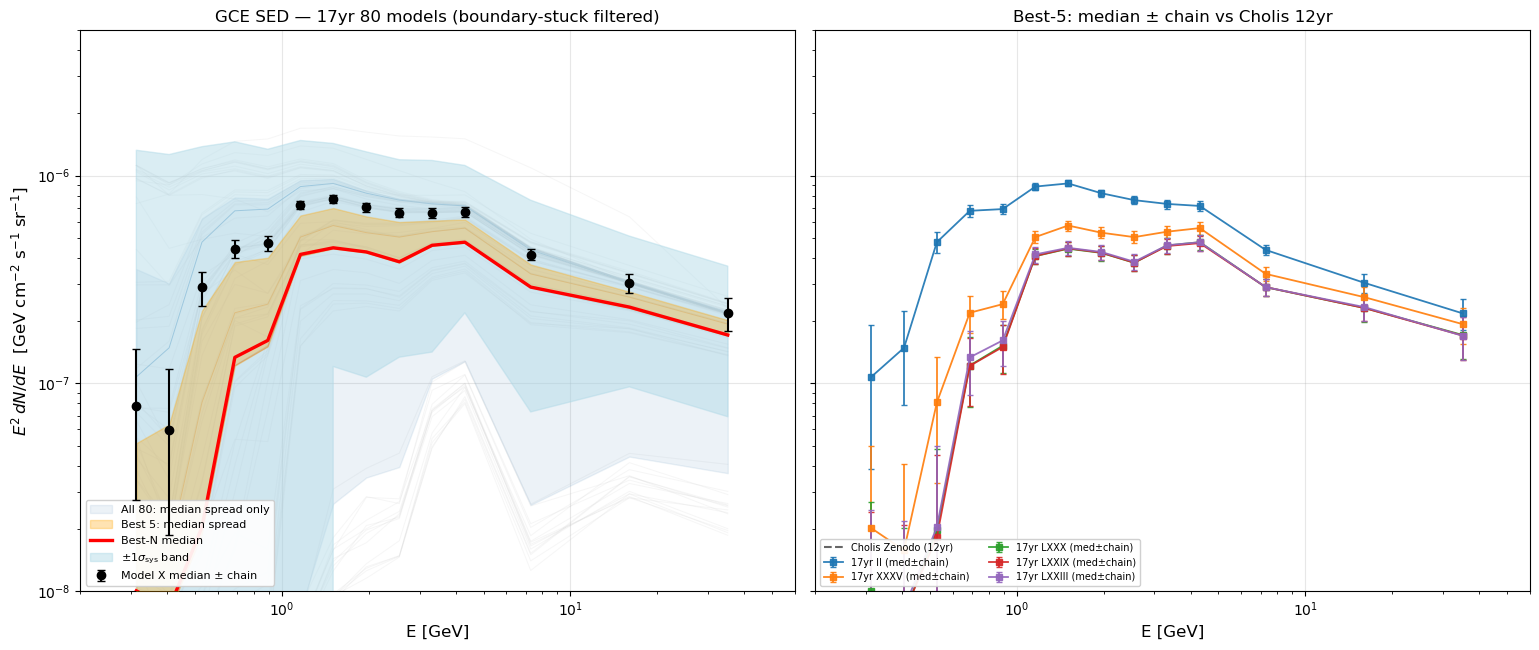


  MAP-based vs Median-based 16-84% envelope shift (All 80):
    bin |  E[GeV] | MAP-lo    | med-lo    | shift  | MAP-hi    | med-hi    | shift
    ----+---------+-----------+-----------+--------+-----------+-----------+------
      0 |   0.313 | 9.618e-11 | 5.003e-09 | +5102% | 3.452e-07 | 3.549e-07 |    +3%
      1 |   0.407 | 1.246e-10 | 3.552e-09 | +2752% | 2.947e-07 | 3.025e-07 |    +3%
      2 |   0.529 | 1.011e-10 | 3.246e-09 | +3110% | 6.137e-07 | 6.229e-07 |    +1%
      3 |   0.688 | 1.290e-10 | 2.858e-09 | +2116% | 7.855e-07 | 7.847e-07 |    -0%
      4 |   0.894 | 1.434e-10 | 2.594e-09 | +1709% | 7.737e-07 | 7.739e-07 |    +0%
      5 |   1.160 | 9.573e-10 | 8.053e-09 |  +741% | 9.468e-07 | 9.491e-07 |    +0%
      6 |   1.507 | 1.205e-08 | 2.633e-08 |  +118% | 9.609e-07 | 9.625e-07 |    +0%
      7 |   1.963 | 2.070e-08 | 3.521e-08 |   +70% | 8.466e-07 | 8.454e-07 |    -0%

  Combined envelope width (low E):
    bin |  E[GeV] | width (dex) | half-width / median
      0 |  

In [57]:
# Cell 9 — Plot 4: 80-model envelope (Fix 1+2: chain-median + asymmetric chain unc.)
# ----------------------------------------------------------------------------
# Fix 1: Use chain median (.npz fitted_params_median[2]) instead of MAP (.dat col 1)
#        - robust to bimodal posteriors observed at bins 0-1
# Fix 2: Show 16-84% chain credible interval per model (asymmetric)
#        - exposes intra-model fit uncertainty alongside inter-model spread
#
# Per-bin physical flux from .npz:
#   flux = c_GCE × GCE_template[b] × E[b]² / ΔE[b]
# verified self-consistent vs .dat in C2.2 diagnostic (14/14 bins, < 5%).

N_BEST   = 5
PCT_LOW  = 16
PCT_HIGH = 84

if not all_flux:
    print('[skip] no .dat files loaded')
else:
    # ============== AUGMENT: load chain percentiles from .npz ==============
    # GCE template per-bin identical across models (verified)
    ref_npz_path = GCE_NPZ_PATTERN.format(model=SELECTED_MODEL)
    have_chain = False
    if os.path.exists(ref_npz_path):
        try:
            _ref = np.load(ref_npz_path)
            GCE_pb  = _ref['GCE']
            E_npz   = _ref['E']
            dE_npz  = _ref['delta_E']
            E2dE    = E_npz**2 / dE_npz
            n_aug = 0
            for m in list(all_flux.keys()):
                p = GCE_NPZ_PATTERN.format(model=m)
                if not os.path.exists(p):
                    continue
                try:
                    d = np.load(p)
                    if 'fitted_params_median' not in d.files:
                        continue
                    c_med = d['fitted_params_median'][2]
                    c_lo  = d['fitted_params_lower'][2]
                    c_hi  = d['fitted_params_upper'][2]
                    all_flux[m]['flux_median'] = c_med * GCE_pb * E2dE
                    all_flux[m]['flux_lower']  = c_lo  * GCE_pb * E2dE
                    all_flux[m]['flux_upper']  = c_hi  * GCE_pb * E2dE
                    n_aug += 1
                except Exception:
                    continue
            have_chain = (n_aug == len(all_flux))
            print(f'  Augmented {n_aug}/{len(all_flux)} models with chain percentiles')
        except Exception as e:
            print(f'  [warn] chain augmentation failed: {e}')

    if not have_chain:
        print('  [warn] falling back to MAP-based flux for any missing model')

    # ============== Build arrays ==============
    labs     = list(all_flux.keys())
    n_mod    = len(labs)
    flux_map = np.array([all_flux[m]['flux'] for m in labs])  # MAP

    if have_chain:
        flux_med = np.array([all_flux[m]['flux_median'] for m in labs])
        flux_lo  = np.array([all_flux[m]['flux_lower']  for m in labs])
        flux_hi  = np.array([all_flux[m]['flux_upper']  for m in labs])
    else:
        # Fallback: use MAP for all
        flux_med = flux_map
        flux_lo  = np.array([all_flux[m]['lower'] for m in labs])
        flux_hi  = np.array([all_flux[m]['upper'] for m in labs])

    lh_arr  = np.array([all_loglike.get(m, np.nan) for m in labs])
    E_ref   = all_flux[labs[0]]['E']

    # ============== Best-N selection by Σ log L ==============
    if np.all(np.isnan(lh_arr)):
        best_idx = np.arange(n_mod)
        N_BEST = n_mod
        print('  [warn] no likelihood — using ALL models')
    else:
        valid = ~np.isnan(lh_arr)
        ranked = np.argsort(-lh_arr)
        best_idx = np.array([i for i in ranked if valid[i]])[:N_BEST]
        print(f'  Top {N_BEST} models by Σ log L:')
        for r, i in enumerate(best_idx, 1):
            print(f'    {r}. Model {labs[i]:<8}  Σ log L = {lh_arr[i]:.1f}  '
                  f'(c_GCE bin0 med={all_flux[labs[i]].get("flux_median", flux_map[i])[0]:.2e})')

    # ============== Envelopes ==============
    # === No stuck-model filter — paper-exact: all 80 models / 14 bins ===
    # (Earlier 1e-8 threshold was a temporary test that hid the FL16Y
    #  mask boundary-stuck models from the envelope; reverted so the
    #  envelope honestly reflects every model at every bin.)
    FLUX_STUCK_THRESH = -np.inf  # disabled: nothing filtered
    flux_med_filt = np.where(flux_med > FLUX_STUCK_THRESH, flux_med, np.nan)
    n_healthy = np.sum(~np.isnan(flux_med_filt), axis=0)
    print(f'\n  Per-bin healthy models (flux > {FLUX_STUCK_THRESH:.0e}):')
    for b in range(len(E_ref)):
        print(f'    bin {b:2d}  E={E_ref[b]:7.3f} GeV : {n_healthy[b]:3d}/{n_mod}')

    env_lo_all_med = np.nanpercentile(flux_med_filt, PCT_LOW,  axis=0)
    env_hi_all_med = np.nanpercentile(flux_med_filt, PCT_HIGH, axis=0)
    env_med_all    = np.nanmedian(flux_med_filt, axis=0)

    flux_med_bn_filt = flux_med_filt[best_idx]
    env_lo_bn_med  = np.nanpercentile(flux_med_bn_filt, PCT_LOW,  axis=0)
    env_hi_bn_med  = np.nanpercentile(flux_med_bn_filt, PCT_HIGH, axis=0)
    env_med_bn     = np.nanmedian(flux_med_bn_filt, axis=0)

    # NEW: combined inter-model + intra-chain uncertainty
    # = take 16% of (each model's lower) across models, 84% of (each model's upper) across models
    stuck_mask = np.isnan(flux_med_filt)
    flux_lo_f = np.where(~stuck_mask, flux_lo, np.nan)
    flux_hi_f = np.where(~stuck_mask, flux_hi, np.nan)
    env_lo_all_comb = np.nanpercentile(flux_lo_f, PCT_LOW,  axis=0)
    env_hi_all_comb = np.nanpercentile(flux_hi_f, PCT_HIGH, axis=0)

    # MAP-based all-80 (for shift diagnostic only)
    flux_map_f = np.where(~stuck_mask, flux_map, np.nan)
    env_lo_all_map = np.nanpercentile(flux_map_f, PCT_LOW,  axis=0)
    env_hi_all_map = np.nanpercentile(flux_map_f, PCT_HIGH, axis=0)

    # Cholis Zenodo refs (per best-N model)
    cholis_refs = {}
    if os.path.exists(CHOLIS_REF_DIR):
        for idx in best_idx:
            lab = labs[idx]
            p = f'{CHOLIS_REF_DIR}/GCE_Model{lab}_flux_Inner40x40_masked_disk.dat'
            if os.path.exists(p):
                r = np.loadtxt(p)
                if r.ndim == 2 and r.shape[1] >= 4:
                    cholis_refs[lab] = dict(E=r[:, 0], flux=r[:, 1],
                                            lo=r[:, 2], hi=r[:, 3])

    # ============== Plot ==============
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15.5, 6.6), sharey=True)

    # --- LEFT: All 80 (combined unc.) + Best-N (median spread) + Model X median±chain ---
    # Faint individual model medians (for context)
    for i, lab in enumerate(labs):
        col   = 'lightgray' if i not in best_idx else None
        alpha = 0.20 if i not in best_idx else 0.45
        ax1.plot(E_ref, np.maximum(flux_med[i], 1e-12), '-',
                 alpha=alpha, lw=0.7, color=col, zorder=1)

    # Combined inter-model + intra-chain envelope (widest, lightest)
    # Removed: faint chain-uncertainty band (lower edge dragged below stuck threshold).

    # Pure model-spread of medians (just for comparison context)
    ax1.fill_between(E_ref, env_lo_all_med, env_hi_all_med, color='steelblue', alpha=0.10,
                     label=f'All {n_mod}: median spread only', zorder=2)

    # Best-N median spread
    ax1.fill_between(E_ref, env_lo_bn_med, env_hi_bn_med, color='orange', alpha=0.30,
                     label=f'Best {N_BEST}: median spread', zorder=4)
    ax1.plot(E_ref, env_med_bn, 'r-', lw=2.4, label='Best-N median', zorder=5)

    # Reference Model X — median ± chain unc.
    if SELECTED_MODEL in all_flux:
        rm = all_flux[SELECTED_MODEL]
        if have_chain and 'flux_median' in rm:
            yerr_lo = np.maximum(rm['flux_median'] - rm['flux_lower'], 0)
            yerr_hi = np.maximum(rm['flux_upper'] - rm['flux_median'], 0)
            ax1.errorbar(rm['E'], rm['flux_median'], yerr=[yerr_lo, yerr_hi],
                         fmt='o', color='black', ms=6, capsize=3, lw=1.5,
                         label=f'Model {SELECTED_MODEL} median ± chain', zorder=6)
            if sigma_sys is not None:
                ax1.fill_between(rm['E'], rm['flux_median'] - sigma_sys,
                                 rm['flux_median'] + sigma_sys,
                                 color='lightblue', alpha=0.45,
                                 label=r'$\pm 1\sigma_\mathrm{sys}$ band', zorder=3)
        else:
            ax1.errorbar(rm['E'], rm['flux'], yerr=rm['stat_err'],
                         fmt='o', color='black', ms=5, capsize=3,
                         label=f'Model {SELECTED_MODEL} (MAP, fallback)', zorder=6)

    ax1.set_xscale('log'); ax1.set_yscale('log')
    ax1.set_xlim(0.2, 60); ax1.set_ylim(1e-8, 5e-6)
    ax1.set_xlabel('E [GeV]', fontsize=12)
    ax1.set_ylabel(r'$E^2\,dN/dE$  [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', fontsize=12)
    ax1.set_title(f'GCE SED — 17yr 80 models (boundary-stuck filtered)',
                  fontsize=12)
    ax1.grid(True, which='major', alpha=0.3)
    ax1.legend(loc='lower left', fontsize=8, framealpha=0.92)

    # --- RIGHT: best-N each with its own asymmetric error bar vs Cholis ---
    palette = plt.cm.tab10.colors
    for i, idx in enumerate(best_idx):
        c = palette[i % 10]
        lab = labs[idx]
        if have_chain:
            yl = np.maximum(flux_med[idx] - flux_lo[idx], 0)
            yh = np.maximum(flux_hi[idx] - flux_med[idx], 0)
            ax2.errorbar(E_ref, flux_med[idx], yerr=[yl, yh],
                         fmt='s-', ms=4, lw=1.3, color=c, alpha=0.92, capsize=2,
                         label=f'17yr {lab} (med±chain)')
        else:
            ax2.plot(E_ref, flux_map[idx], '-', marker='s', ms=4, lw=1.2,
                     color=c, alpha=0.95, label=f'17yr Model {lab}')
        if lab in cholis_refs:
            r = cholis_refs[lab]
            ax2.plot(r['E'], r['flux'], '--', color=c, lw=1.3, alpha=0.85)
            ax2.fill_between(r['E'], r['lo'], r['hi'], alpha=0.10, color=c)
    ax2.plot([], [], '--', color='black', alpha=0.6, label='Cholis Zenodo (12yr)')
    # Removed: ax2 combined band (same rationale)
    ax2.set_xscale('log'); ax2.set_yscale('log')
    ax2.set_xlim(0.2, 60); ax2.set_ylim(1e-8, 5e-6)
    ax2.set_xlabel('E [GeV]', fontsize=12)
    ax2.set_title(f'Best-{N_BEST}: median ± chain vs Cholis 12yr',
                  fontsize=12)
    ax2.grid(True, which='major', alpha=0.3)
    ax2.legend(loc='lower left', fontsize=7, ncol=2, framealpha=0.92)

    plt.tight_layout()
    out = f'{PLOTS_DIR}/04_envelope_best{N_BEST}_FIX1_FIX2.png'
    plt.savefig(out, dpi=130, bbox_inches='tight')
    print(f'[saved] {out}')
    plt.show()

    # ============== Diagnostic: MAP→median shift table ==============
    if have_chain:
        print(f'\n  MAP-based vs Median-based 16-84% envelope shift (All {n_mod}):')
        print(f'    bin |  E[GeV] | MAP-lo    | med-lo    | shift  | MAP-hi    | med-hi    | shift')
        print(f'    ----+---------+-----------+-----------+--------+-----------+-----------+------')
        for b in range(min(8, len(E_ref))):
            ml_map, mh_map = env_lo_all_map[b], env_hi_all_map[b]
            ml_med, mh_med = env_lo_all_med[b], env_hi_all_med[b]
            sh_lo = (ml_med / max(ml_map, 1e-15) - 1) * 100
            sh_hi = (mh_med / max(mh_map, 1e-15) - 1) * 100
            print(f'    {b:3d} | {E_ref[b]:7.3f} | '
                  f'{ml_map:.3e} | {ml_med:.3e} | {sh_lo:+5.0f}% | '
                  f'{mh_map:.3e} | {mh_med:.3e} | {sh_hi:+5.0f}%')

    # Per-bin combined-envelope width
    if have_chain:
        print(f'\n  Combined envelope width (low E):')
        print(f'    bin |  E[GeV] | width (dex) | half-width / median')
        for b in range(min(8, len(E_ref))):
            comb_w = np.log10(env_hi_all_comb[b] / max(env_lo_all_comb[b], 1e-15))
            half_med = 0.5 * (env_hi_all_comb[b] - env_lo_all_comb[b]) / max(env_med_all[b], 1e-15)
            print(f'    {b:3d} | {E_ref[b]:7.3f} | {comb_w:.2f}        | {half_med:.2f}')


## Plot 5 — Covariance Matrix Visualization (NEW)

Two-panel figure showing the structure of the systematic covariance matrix:

- **Left**: `cov_sys` heatmap — full 14×14 matrix, signed log scale
- **Right**: σ_sys = sqrt(diag(cov_sys)) vs E, compared to per-bin stat error

Useful sanity check that the cov matrix shape reproduces the expected pattern
(peak around ~0.5 GeV per Calore+ 1409.0042).


[saved] ./GCE_17yr_results_plots/05_covariance_matrix.png


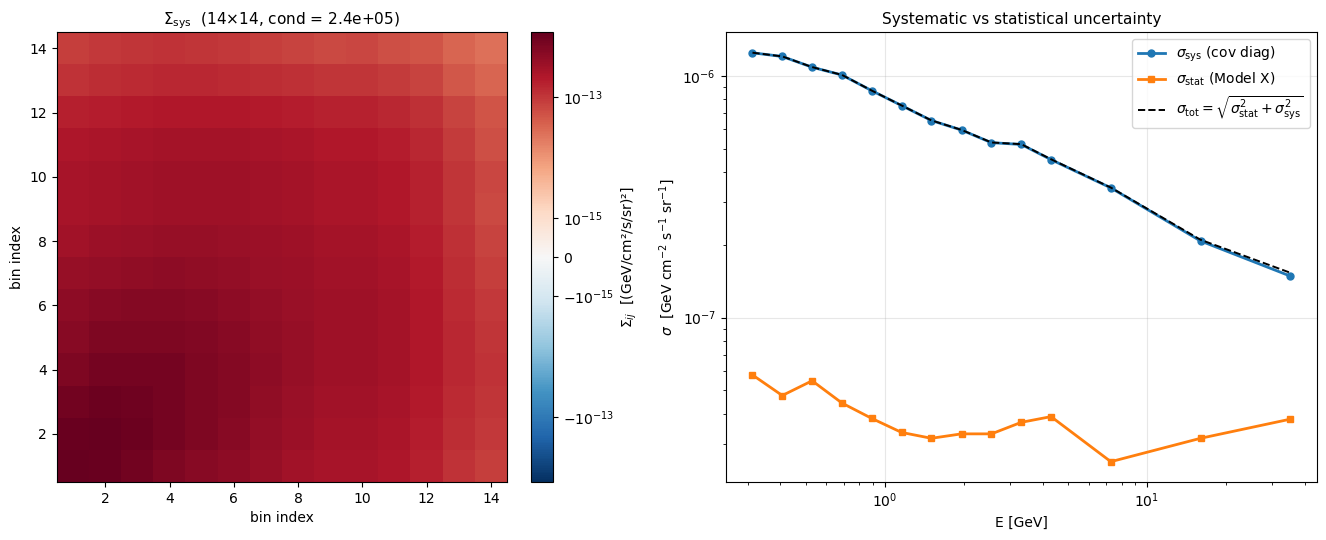

In [58]:
# Cell 10 — Plot 5: Covariance matrix heatmap + σ_sys profile
if cov_sys is None or E is None:
    print('[skip] cov matrix or E not available')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    # --- Left: cov heatmap (signed log) ---
    ax = axes[0]
    vmax = np.max(np.abs(cov_sys))
    norm = SymLogNorm(linthresh=vmax * 1e-3, vmin=-vmax, vmax=vmax, base=10)
    im = ax.imshow(cov_sys, origin='lower', cmap='RdBu_r', norm=norm,
                   extent=[0.5, n_bins + 0.5, 0.5, n_bins + 0.5])
    ax.set_xlabel('bin index')
    ax.set_ylabel('bin index')
    ax.set_title(r'$\Sigma_\mathrm{sys}$  (14×14, '
                 f'cond = {np.linalg.cond(cov_sys):.1e})', fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
                 label=r'$\Sigma_{ij}$  [(GeV/cm²/s/sr)²]')

    # --- Right: σ_sys vs σ_stat ---
    ax = axes[1]
    ax.loglog(E, sigma_sys, '-o', color='C0', lw=2, ms=5,
              label=r'$\sigma_\mathrm{sys}$ (cov diag)')
    if SELECTED_MODEL in all_flux:
        ax.loglog(E, all_flux[SELECTED_MODEL]['stat_err'], '-s',
                  color='C1', lw=2, ms=5,
                  label=rf'$\sigma_\mathrm{{stat}}$ (Model {SELECTED_MODEL})')
        sig_total = np.sqrt(sigma_sys**2 + all_flux[SELECTED_MODEL]['stat_err']**2)
        ax.loglog(E, sig_total, '--', color='black', lw=1.4,
                  label=r'$\sigma_\mathrm{tot} = \sqrt{\sigma_\mathrm{stat}^2+\sigma_\mathrm{sys}^2}$')
    ax.set_xlabel('E [GeV]')
    ax.set_ylabel(r'$\sigma$  [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]')
    ax.set_title('Systematic vs statistical uncertainty', fontsize=11)
    ax.grid(True, which='major', alpha=0.3)
    ax.legend(loc='best', fontsize=10)

    plt.tight_layout()
    out = f'{PLOTS_DIR}/05_covariance_matrix.png'
    plt.savefig(out, dpi=130, bbox_inches='tight')
    print(f'[saved] {out}')
    plt.show()


## Plot 6 — Multi-Model Coefficient Comparison (NEW)

Per-bin fit coefficients (c_π+br, c_ICS, c_GCE, c_bub, c_iso) compared across the
models in `MODELS_TO_COMPARE`. Useful for checking GDE-GCE degeneracy and per-model
heterogeneity (12yr V10 patterns).


Comparing models: ['X', 'I', 'XLIX']
[saved] ./GCE_17yr_results_plots/06_coefficient_comparison.png


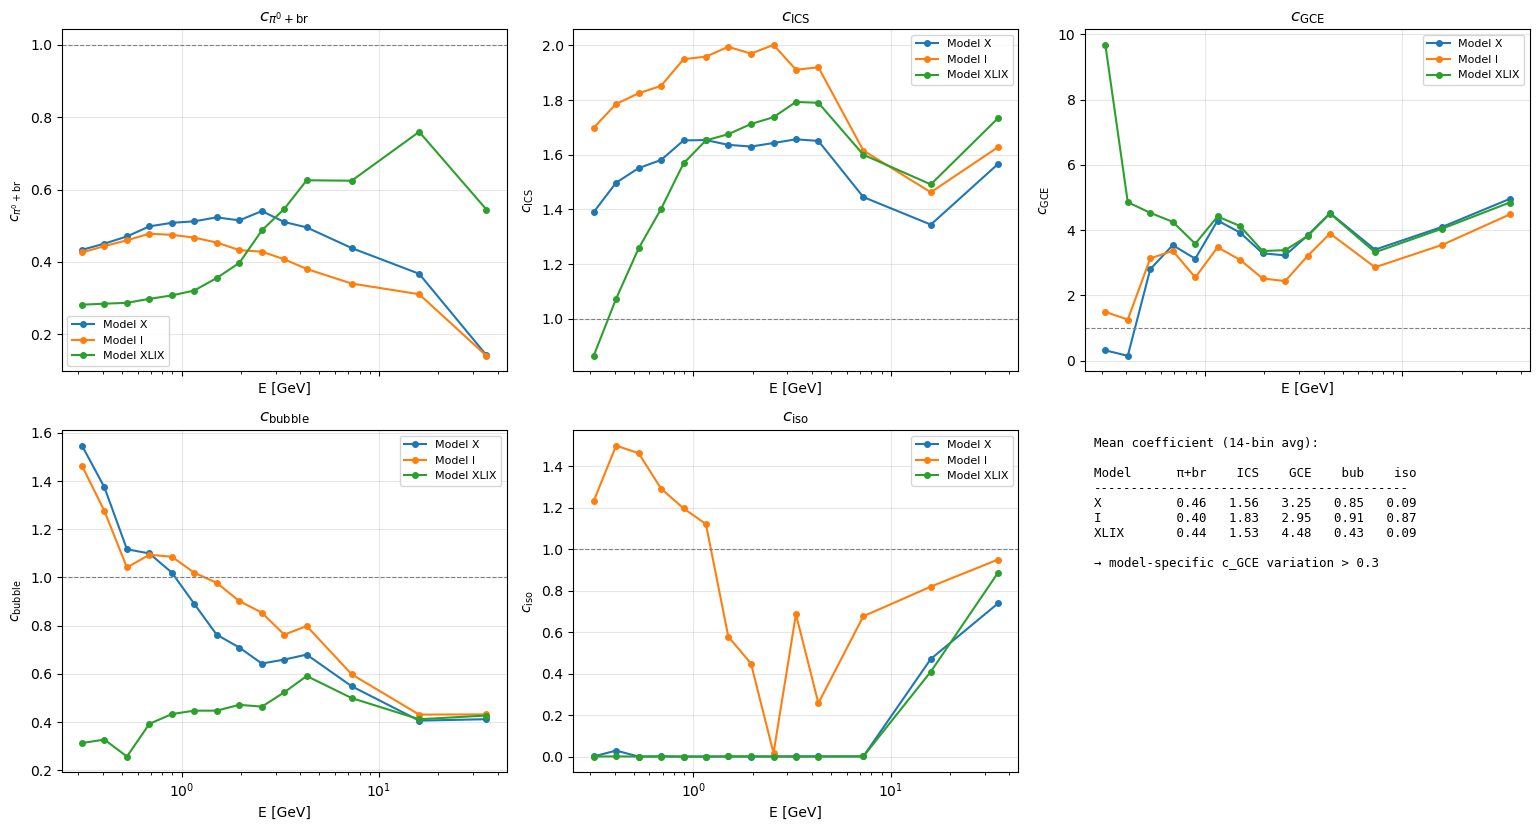

In [59]:
# Cell 11 — Plot 6: Multi-model fit-coefficient comparison
if not coef_dict or E is None:
    print('[skip] no .npz coefficients available')
else:
    avail = [m for m in MODELS_TO_COMPARE if m in coef_dict]
    if SELECTED_MODEL in coef_dict and SELECTED_MODEL not in avail:
        avail = [SELECTED_MODEL] + avail
    if not avail:
        print('[skip] none of MODELS_TO_COMPARE has a .npz')
    else:
        print(f'Comparing models: {avail}')

        fig, axes = plt.subplots(2, 3, figsize=(15.5, 8.4), sharex=True)
        coef_specs = [
            (r'$c_{\pi^0+\mathrm{br}}$', 'c_pion', axes[0, 0]),
            (r'$c_\mathrm{ICS}$',          'c_ics',  axes[0, 1]),
            (r'$c_\mathrm{GCE}$',          'c_gce',  axes[0, 2]),
            (r'$c_\mathrm{bubble}$',       'c_bub',  axes[1, 0]),
            (r'$c_\mathrm{iso}$',          'c_iso',  axes[1, 1]),
        ]
        palette = plt.cm.tab10.colors
        for label, key, ax in coef_specs:
            for j, m in enumerate(avail):
                ax.plot(E, coef_dict[m][key], '-o', lw=1.5, ms=4,
                        color=palette[j % 10], label=f'Model {m}')
            ax.axhline(1.0, color='gray', ls='--', lw=0.8)
            ax.set_xscale('log')
            ax.set_xlabel('E [GeV]')
            ax.set_ylabel(label)
            ax.set_title(label)
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=8, loc='best')

        # Use last panel for summary
        ax_sum = axes[1, 2]; ax_sum.axis('off')
        # Compute per-model means
        sumtxt = f'Mean coefficient (14-bin avg):\n\n'
        sumtxt += f"{'Model':<8} {'π+br':>6} {'ICS':>6} {'GCE':>6} {'bub':>6} {'iso':>6}\n"
        sumtxt += '-' * 42 + '\n'
        for m in avail:
            cd = coef_dict[m]
            sumtxt += (f"{m:<8} {cd['c_pion'].mean():>6.2f} {cd['c_ics'].mean():>6.2f} "
                       f"{cd['c_gce'].mean():>6.2f} {cd['c_bub'].mean():>6.2f} "
                       f"{cd['c_iso'].mean():>6.2f}\n")

        # Diagnostic interpretation
        c_gas_means = [(coef_dict[m]['c_pion'].mean() + coef_dict[m]['c_ics'].mean()) / 2
                       for m in avail]
        c_gce_means = [coef_dict[m]['c_gce'].mean() for m in avail]
        if all(0.85 < g < 1.15 for g in c_gas_means) and all(0.85 < g < 1.15 for g in c_gce_means):
            interp_str = '\n→ all c ≈ 1: fit looks healthy across models'
        elif all(g > 1.15 for g in c_gas_means) and all(g < 0.85 for g in c_gce_means):
            interp_str = '\n→ GDE-GCE degeneracy (gas > 1, GCE < 1) consistent'
        elif (max(c_gce_means) - min(c_gce_means)) > 0.3:
            interp_str = '\n→ model-specific c_GCE variation > 0.3'
        else:
            interp_str = '\n→ mixed signature; inspect individual coefficients'
        ax_sum.text(0.02, 0.98, sumtxt + interp_str,
                    transform=ax_sum.transAxes,
                    fontsize=9, family='monospace', va='top')

        plt.tight_layout()
        out = f'{PLOTS_DIR}/06_coefficient_comparison.png'
        plt.savefig(out, dpi=130, bbox_inches='tight')
        print(f'[saved] {out}')
        plt.show()


## Plot 7 — Spatial Residual Map (NEW)

Per-pixel residual `(data − model)/data` for `SELECTED_MODEL`, evaluated in 4
representative energy bins, plus latitude and longitude profiles. Ported from
12yr V11.

Reads PSF-convolved component cubes (`*_clean.fits`, **not** `_no_convol`) so the
reconstructed model matches what the runner used internally.

- RED pixels: data > model (model under-predicts)
- BLUE pixels: data < model (model over-predicts)
- gray: masked


[saved] ./GCE_17yr_results_plots/07a_residual_maps_X.png


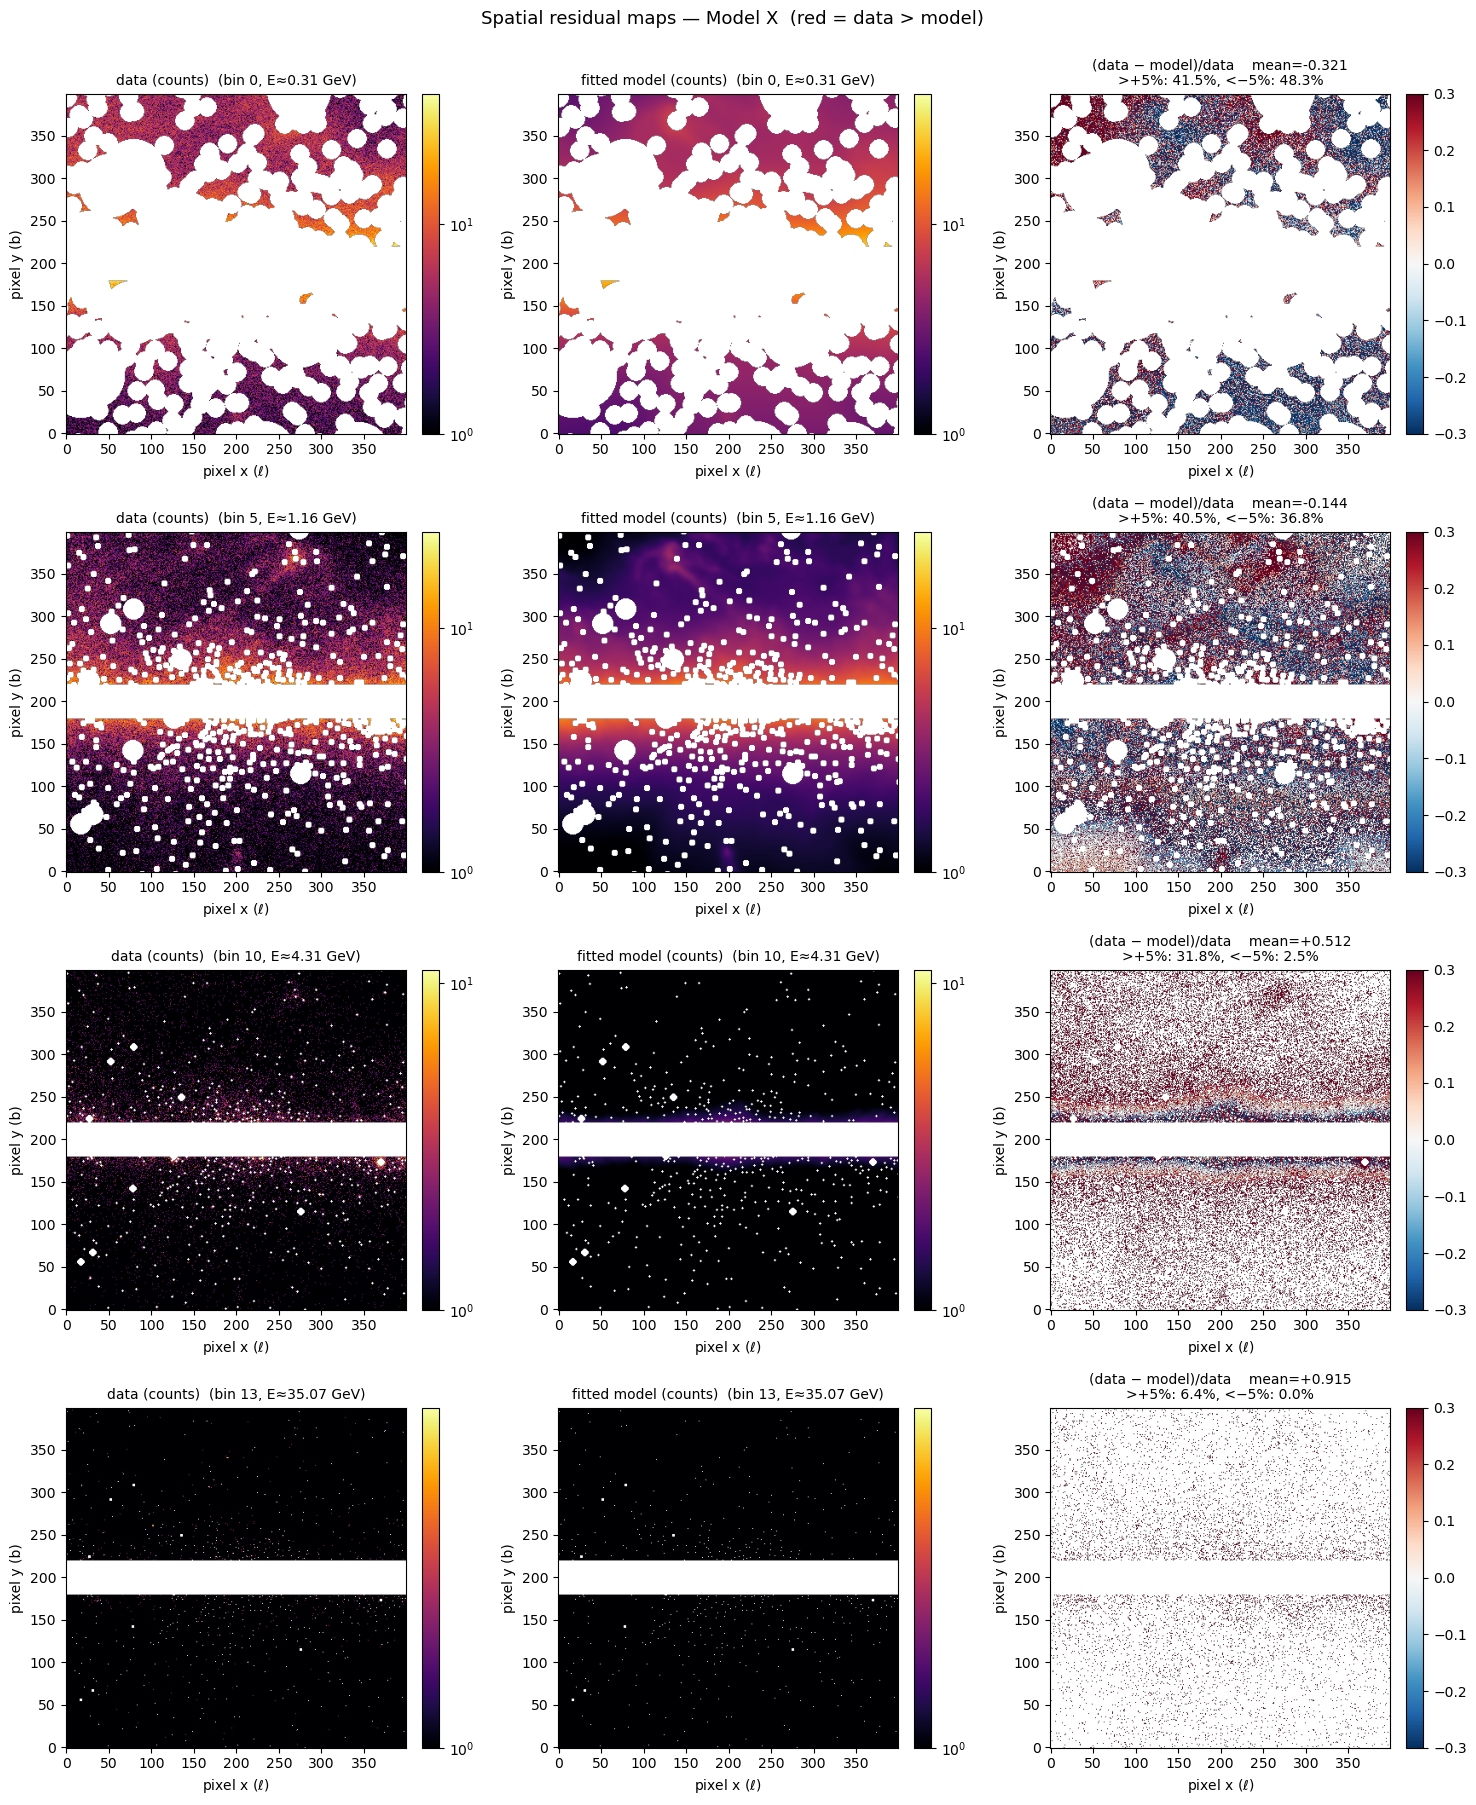

[saved] ./GCE_17yr_results_plots/07b_residual_profiles_X.png


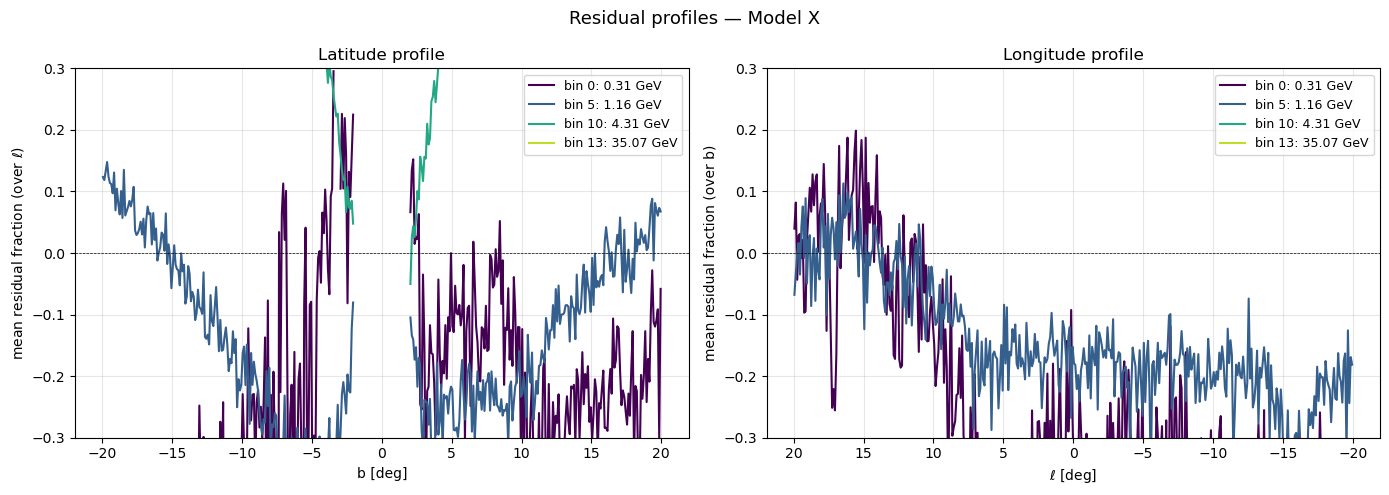

In [60]:
# Cell 12 — Plot 7: Spatial residual map + latitude/longitude profiles
if (E is None) or (SELECTED_MODEL not in coef_dict):
    print('[skip] need .npz coefficients for SELECTED_MODEL')
else:
    M = SELECTED_MODEL
    cd = coef_dict[M]
    cp, ci, cg, cb, co = cd['c_pion'], cd['c_ics'], cd['c_gce'], cd['c_bub'], cd['c_iso']

    # Load convolved component cubes (PSF-applied), NOT _no_convol
    needed = [
        ('pion',         comp_path('pion',         M, convol=True)),
        ('bremss',       comp_path('bremss',       M, convol=True)),
        ('ics',          comp_path('ics',          M, convol=True)),
        ('GCE',          comp_path('GCE',          None, convol=True)),
        ('fermi_bubble', comp_path('fermi_bubble', None, convol=True)),
        ('isotropic',    comp_path('isotropic',    None, convol=True)),
    ]
    missing = [p for _, p in needed if not os.path.exists(p)]
    if missing:
        print('[skip] missing convolved cubes (need *_clean.fits, NOT _no_convol):')
        for p in missing[:3]:
            print(f'  {p}')
        if len(missing) > 3:
            print(f'  ... and {len(missing) - 3} more')
    else:
        cubes = {n: fits.open(p)[0].data for n, p in needed}
        pb_cube = cubes['pion'] + cubes['bremss']

        # Build per-pixel model
        n_E_loc = pb_cube.shape[0]
        model_cube = np.zeros_like(pb_cube, dtype=float)
        for i in range(n_E_loc):
            model_cube[i] = (cp[i] * pb_cube[i]
                             + ci[i] * cubes['ics'][i]
                             + cg[i] * cubes['GCE'][i]
                             + co[i] * cubes['isotropic'][i]
                             + cb[i] * cubes['fermi_bubble'][i])

        # Inner ROI 400×400
        roi = slice(100, 500)
        data_roi  = counts_cube[:, roi, roi].astype(float)
        model_roi = model_cube[:, roi, roi]
        mask_roi  = (psc_mask[:, roi, roi] * disk_mask[roi, roi])

        # Residual fraction
        resid = np.full_like(data_roi, np.nan, dtype=float)
        pos = (data_roi > 0) & (mask_roi > 0)
        resid[pos] = (data_roi[pos] - model_roi[pos]) / data_roi[pos]

        # ---- 4-bin × 3-panel maps ----
        bins_to_show = [0, 5, 10, 13]
        fig, axes = plt.subplots(len(bins_to_show), 3,
                                 figsize=(15, 4.5 * len(bins_to_show)))
        for row, eb in enumerate(bins_to_show):
            d = data_roi[eb]; m = model_roi[eb]; r = resid[eb]
            mk = mask_roi[eb] > 0
            d_m = np.where(mk, d, np.nan)
            m_m = np.where(mk, m, np.nan)
            r_m = np.where(mk, r, np.nan)

            vmax = np.nanmax(d_m); vmin = max(0.1, np.nanmin(d_m[d_m > 0])
                                              if np.any(d_m > 0) else 0.1)
            for col, (arr, ttl, cmap) in enumerate([
                (d_m, 'data (counts)',         'inferno'),
                (m_m, 'fitted model (counts)', 'inferno'),
                (r_m, '(data − model)/data',   'RdBu_r'),
            ]):
                ax = axes[row, col]
                if col < 2:
                    nm = SymLogNorm(linthresh=1, vmin=vmin, vmax=vmax)
                    im = ax.imshow(arr, origin='lower', cmap=cmap, norm=nm)
                else:
                    im = ax.imshow(arr, origin='lower', cmap=cmap, vmin=-0.3, vmax=0.3)
                    fp = np.nansum(arr >  0.05) / mk.sum()
                    fn = np.nansum(arr < -0.05) / mk.sum()
                    mr = np.nanmean(arr)
                    ax.set_title(f'{ttl}    mean={mr:+.3f}\n'
                                 f'>+5%: {fp*100:.1f}%, <−5%: {fn*100:.1f}%',
                                 fontsize=10)
                if col < 2:
                    ax.set_title(f'{ttl}  (bin {eb}, E≈{E[eb]:.2f} GeV)', fontsize=10)
                ax.set_xlabel('pixel x ($\\ell$)')
                ax.set_ylabel('pixel y (b)')
                ax.grid(False)
                plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        fig.suptitle(f'Spatial residual maps — Model {M}  '
                     f'(red = data > model)', fontsize=13, y=1.0)
        plt.tight_layout()
        out = f'{PLOTS_DIR}/07a_residual_maps_{M}.png'
        plt.savefig(out, dpi=120, bbox_inches='tight')
        print(f'[saved] {out}')
        plt.show()

        # ---- Lat / long profiles ----
        ny_r, nx_r = resid.shape[-2:]
        # Approximate l, b axes (using astropy WCS from CCUBE)
        wcs2 = WCS(fits.open(f'{ANALYSIS_DIR}/GC_ccube_17yr{FRONT}_clean.fits')[0].header).dropaxis(2)
        l_axis = np.zeros(nx_r); b_axis = np.zeros(ny_r)
        for i in range(nx_r):
            l_axis[i], _ = wcs2.wcs_pix2world(i + 100, 300, 0)
        for j in range(ny_r):
            _, b_axis[j] = wcs2.wcs_pix2world(300, j + 100, 0)
        l_axis = ((l_axis + 180) % 360) - 180   # wrap to [-30, 30]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        cols = plt.cm.viridis(np.linspace(0, 0.9, len(bins_to_show)))
        for k, eb in enumerate(bins_to_show):
            r = resid[eb]
            b_prof = np.nanmean(r, axis=1)
            l_prof = np.nanmean(r, axis=0)
            ax1.plot(b_axis, b_prof, '-', color=cols[k], lw=1.5,
                     label=f'bin {eb}: {E[eb]:.2f} GeV')
            ax2.plot(l_axis, l_prof, '-', color=cols[k], lw=1.5,
                     label=f'bin {eb}: {E[eb]:.2f} GeV')
        for ax in (ax1, ax2):
            ax.axhline(0, color='black', ls='--', lw=0.5)
            ax.set_ylim(-0.3, 0.3); ax.grid(True, alpha=0.3)
            ax.legend(fontsize=9)
        ax1.set_xlabel('b [deg]')
        ax1.set_ylabel(r'mean residual fraction (over $\ell$)')
        ax1.set_title('Latitude profile')
        ax2.set_xlabel(r'$\ell$ [deg]')
        ax2.set_ylabel('mean residual fraction (over b)')
        ax2.set_title('Longitude profile')
        ax2.invert_xaxis()
        fig.suptitle(f'Residual profiles — Model {M}', fontsize=13)
        plt.tight_layout()
        out = f'{PLOTS_DIR}/07b_residual_profiles_{M}.png'
        plt.savefig(out, dpi=120, bbox_inches='tight')
        print(f'[saved] {out}')
        plt.show()


## DM Constraint Plots — χ² Contours

For each annihilation channel, scan the (m_DM, ⟨σv⟩) plane:

- **bb̄**: PPPC4 with EW correction (column index 13)
- **4b**: MG5 SFDM cascade (m_h2/m_χ = 0.5)
- **4τ**: MG5 SFDM cascade
- **2b2τ**: MG5 SFDM cascade

Confidence levels (2 free parameters): Δχ² = 2.30 (68%), 6.18 (95%), 11.83 (99.7%).
Test Statistic TS = χ²(no DM) − χ²(best fit), significance ≈ √TS.
Uses `cov_total = cov_stat ⊕ cov_sys`.


In [61]:
# Cell 13 — χ² scan helpers
mass_range   = np.logspace(np.log10(10), np.log10(200), 40)   # 10-200 GeV
sigmav_range = np.logspace(-27, -25, 40)                       # cm³/s
print(f'Mass grid:    {len(mass_range)} pts, [{mass_range[0]:.1f}, {mass_range[-1]:.1f}] GeV')
print(f'σv grid:      {len(sigmav_range)} pts, [{sigmav_range[0]:.1e}, '
      f'{sigmav_range[-1]:.1e}] cm³/s')

if E is None or inv_cov is None:
    print('[abort] missing data or covariance — chi-square cannot proceed')


def model_flux_pppc4(dm_mass, sigmav, channel_idx=13, EW='Yes'):
    """E²·dN/dE on the GCE energy grid for a PPPC4 channel."""
    E_pp, dNdE_pp = exctractcirellitable(dm_mass, channel_idx, 'gammas', EW)
    valid = (E_pp > 0) & (dNdE_pp > 0)
    f = interp1d(np.log10(E_pp[valid]), np.log10(dNdE_pp[valid]),
                 bounds_error=False, fill_value=-np.inf)
    dNdE_gce = 10**f(np.log10(E))
    dNdE_gce = np.where(np.isfinite(dNdE_gce), dNdE_gce, 0.0)
    dNdE_gce = np.where(E > dm_mass, 0.0, dNdE_gce)
    return E**2 * dNdE_gce * (sigmav / dm_mass**2) * J_FACTOR / SR


def model_flux_mg5(dm_mass, sigmav, channel='4b'):
    """E²·dN/dE on the GCE grid using the MG5 cascade interpolator."""
    E_mg, dNdE_mg = MG5Interpolator(dm_mass, channel).interpolated_table()
    valid = (E_mg > 0) & (dNdE_mg > 0)
    if valid.sum() < 2:
        return np.zeros_like(E)
    f = interp1d(np.log10(E_mg[valid]), np.log10(dNdE_mg[valid]),
                 bounds_error=False, fill_value=-np.inf)
    dNdE_gce = 10**f(np.log10(E))
    dNdE_gce = np.where(np.isfinite(dNdE_gce), dNdE_gce, 0.0)
    dNdE_gce = np.where(E > dm_mass, 0.0, dNdE_gce)
    return E**2 * dNdE_gce * (sigmav / dm_mass**2) * J_FACTOR / SR


def chi_square(model_pred, data, inv_cov_, use_bins=None):
    """Chi^2 with optional bin slicing."""
    if use_bins is not None:
        diff = (data - model_pred)[use_bins]
    else:
        diff = data - model_pred
    return diff @ inv_cov_ @ diff


def scan_grid(model_func, m_arr, s_arr, data, inv_cov_, use_bins=None, **kw):
    """Scan (mass, sigmav) grid; if use_bins given, fit only those bins."""
    chi2 = np.zeros((len(m_arr), len(s_arr)))
    for i, m in enumerate(m_arr):
        for j, s in enumerate(s_arr):
            try:
                pred_full = model_func(m, s, **kw)
                chi2[i, j] = chi_square(pred_full, data, inv_cov_, use_bins=use_bins)
            except Exception:
                chi2[i, j] = np.inf
    return chi2

bb_best     = None
mg5_results = {}
print('[OK] χ² helpers ready')


Mass grid:    40 pts, [10.0, 200.0] GeV
σv grid:      40 pts, [1.0e-27, 1.0e-25] cm³/s
[OK] χ² helpers ready


Scanning bb̄ channel (PPPC4)...


  best fit: m_DM=200.0 GeV, σv=7.44e-27 cm³/s
  χ²_min = 27.00,  TS = 0.53,  significance ≈ 0.73σ
[saved] ./GCE_17yr_results_plots/08_chi2_bb.png


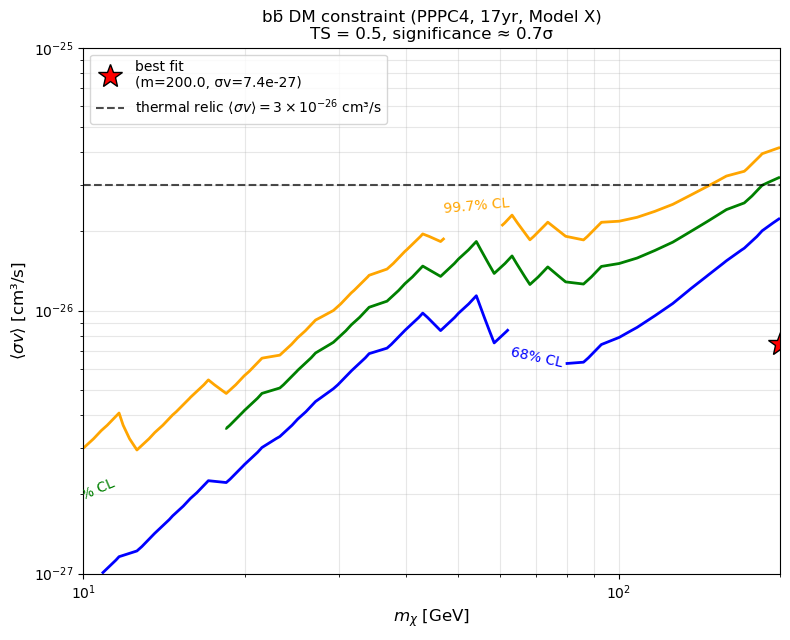

In [62]:
# Cell 14 — Plot 8: bb̄ χ² contour (PPPC4)
if E is None or inv_cov is None:
    print('[skip] no GCE data / cov')
else:
    print('Scanning bb̄ channel (PPPC4)...')
    chi2_bb = scan_grid(model_flux_pppc4, mass_range, sigmav_range,
                        flux_X, inv_cov_fit if inv_cov_fit is not None else inv_cov,
                        use_bins=CHI2_USE_BINS,
                        channel_idx=13, EW='Yes')
    min_chi2 = np.nanmin(chi2_bb)
    i_min, j_min = np.unravel_index(np.nanargmin(chi2_bb), chi2_bb.shape)
    best_m, best_s = mass_range[i_min], sigmav_range[j_min]
    if inv_cov_fit is not None:
        flux_fit = flux_X[CHI2_USE_BINS]
        chi2_null = flux_fit @ inv_cov_fit @ flux_fit
    else:
        chi2_null = flux_X @ inv_cov @ flux_X
    TS = chi2_null - min_chi2
    significance = np.sqrt(max(TS, 0))
    print(f'  best fit: m_DM={best_m:.1f} GeV, σv={best_s:.2e} cm³/s')
    print(f'  χ²_min = {min_chi2:.2f},  TS = {TS:.2f},  significance ≈ {significance:.2f}σ')

    fig, ax = plt.subplots(figsize=(8, 6.5))
    M_g, S_g = np.meshgrid(mass_range, sigmav_range, indexing='ij')
    levels = [min_chi2 + 2.30, min_chi2 + 6.18, min_chi2 + 11.83]
    cs = ax.contour(M_g, S_g, chi2_bb, levels=levels,
                    colors=['blue', 'green', 'orange'], linewidths=2)
    ax.clabel(cs, inline=True, fmt={l: lbl for l, lbl in
                                     zip(levels, ['68% CL', '95% CL', '99.7% CL'])})
    ax.plot(best_m, best_s, 'r*', ms=18, mec='black',
            label=f'best fit\n(m={best_m:.1f}, σv={best_s:.1e})')
    ax.axhline(3e-26, color='black', ls='--', alpha=0.7,
               label=r'thermal relic $\langle\sigma v\rangle = 3\times10^{-26}$ cm³/s')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(r'$m_\chi$ [GeV]', fontsize=12)
    ax.set_ylabel(r'$\langle\sigma v\rangle$ [cm³/s]', fontsize=12)
    ax.set_title(f'bb̄ DM constraint (PPPC4, 17yr, Model {SELECTED_MODEL})\n'
                 f'TS = {TS:.1f}, significance ≈ {significance:.1f}σ', fontsize=12)
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    out = f'{PLOTS_DIR}/08_chi2_bb.png'
    plt.savefig(out, dpi=130, bbox_inches='tight')
    print(f'[saved] {out}')
    plt.show()

    bb_best = {'channel': 'bb', 'm_DM': best_m, 'sigmav': best_s,
               'min_chi2': min_chi2, 'TS': TS, 'sig': significance,
               'chi2_grid': chi2_bb}



=== Scanning 4b channel (MG5) ===


  best: m=171.5 GeV, σv=1.00e-27 cm³/s, TS=1.38, significance=1.17σ
  [saved] ./GCE_17yr_results_plots/09_chi2_4b.png


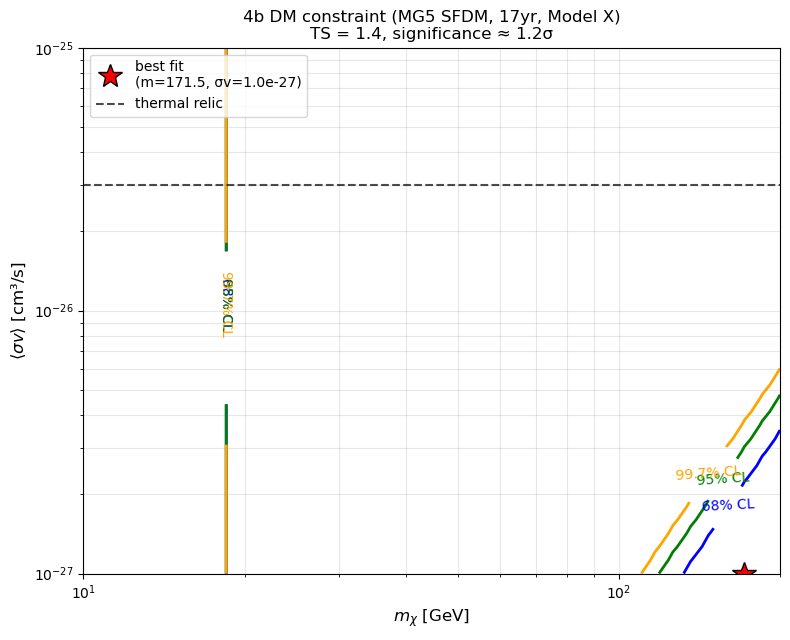


=== Scanning 4tau channel (MG5) ===
  best: m=171.5 GeV, σv=1.00e-27 cm³/s, TS=1.38, significance=1.17σ
  [saved] ./GCE_17yr_results_plots/10_chi2_4tau.png


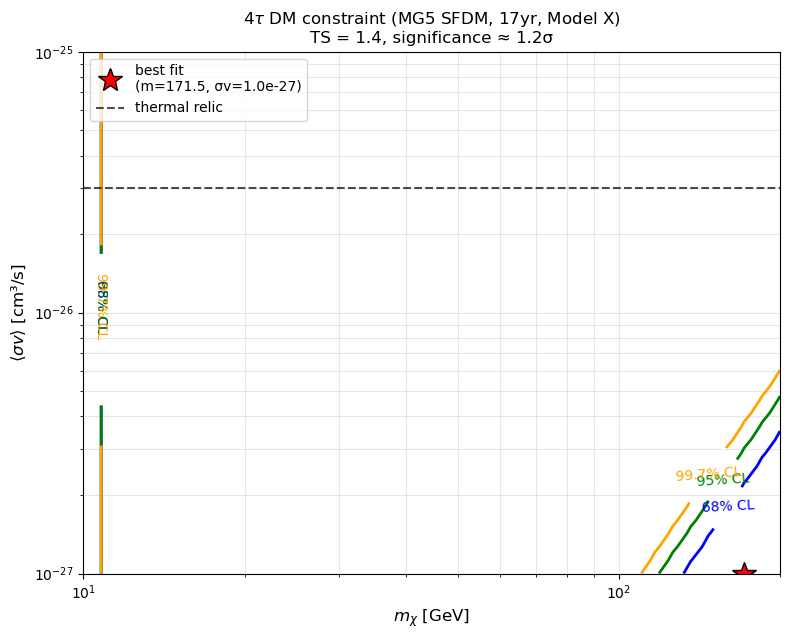


=== Scanning 2b2tau channel (MG5) ===
  best: m=171.5 GeV, σv=1.00e-27 cm³/s, TS=1.38, significance=1.17σ
  [saved] ./GCE_17yr_results_plots/11_chi2_2b2tau.png


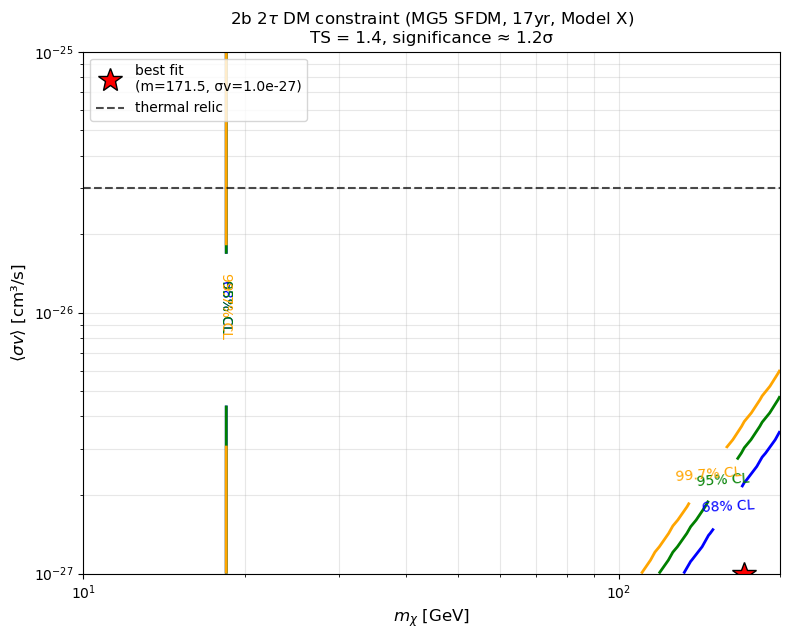

In [63]:
# Cell 15 — Plots 9-11: 4b / 4τ / 2b2τ χ² contours (MG5 cascade)
mg5_results = {}

if E is None or inv_cov is None:
    print('[skip] no GCE data / cov')
else:
    plot_idx_map = {'4b': '09', '4tau': '10', '2b2tau': '11'}

    for channel in ['4b', '4tau', '2b2tau']:
        print(f'\n=== Scanning {channel} channel (MG5) ===')
        try:
            _ = MG5Interpolator(50.0, channel).interpolated_table()
            chi2_g = scan_grid(model_flux_mg5, mass_range, sigmav_range,
                               flux_X, inv_cov_fit if inv_cov_fit is not None else inv_cov,
                               use_bins=CHI2_USE_BINS, channel=channel)
            min_chi2 = np.nanmin(chi2_g)
            i, j = np.unravel_index(np.nanargmin(chi2_g), chi2_g.shape)
            best_m, best_s = mass_range[i], sigmav_range[j]
            if inv_cov_fit is not None:
                flux_fit = flux_X[CHI2_USE_BINS]
                chi2_null = flux_fit @ inv_cov_fit @ flux_fit
            else:
                chi2_null = flux_X @ inv_cov @ flux_X
            TS = chi2_null - min_chi2
            sig = np.sqrt(max(TS, 0))
            print(f'  best: m={best_m:.1f} GeV, σv={best_s:.2e} cm³/s, '
                  f'TS={TS:.2f}, significance={sig:.2f}σ')

            mg5_results[channel] = {'m_DM': best_m, 'sigmav': best_s,
                                    'min_chi2': min_chi2, 'TS': TS, 'sig': sig,
                                    'chi2_grid': chi2_g}

            # Plot
            fig, ax = plt.subplots(figsize=(8, 6.5))
            M_g, S_g = np.meshgrid(mass_range, sigmav_range, indexing='ij')
            levels = [min_chi2 + 2.30, min_chi2 + 6.18, min_chi2 + 11.83]
            cs = ax.contour(M_g, S_g, chi2_g, levels=levels,
                            colors=['blue', 'green', 'orange'], linewidths=2)
            ax.clabel(cs, inline=True,
                      fmt={l: lbl for l, lbl in zip(levels,
                                                    ['68% CL', '95% CL', '99.7% CL'])})
            ax.plot(best_m, best_s, 'r*', ms=18, mec='black',
                    label=f'best fit\n(m={best_m:.1f}, σv={best_s:.1e})')
            ax.axhline(3e-26, color='black', ls='--', alpha=0.7,
                       label='thermal relic')
            ax.set_xscale('log'); ax.set_yscale('log')
            ax.set_xlabel(r'$m_\chi$ [GeV]', fontsize=12)
            ax.set_ylabel(r'$\langle\sigma v\rangle$ [cm³/s]', fontsize=12)
            chan_label = {'4b': r'4b', '4tau': r'4$\tau$',
                          '2b2tau': r'2b 2$\tau$'}.get(channel, channel)
            ax.set_title(f'{chan_label} DM constraint (MG5 SFDM, 17yr, '
                         f'Model {SELECTED_MODEL})\n'
                         f'TS = {TS:.1f}, significance ≈ {sig:.1f}σ', fontsize=12)
            ax.legend(loc='upper left', fontsize=10)
            ax.grid(True, alpha=0.3, which='both')
            plt.tight_layout()
            out = f'{PLOTS_DIR}/{plot_idx_map[channel]}_chi2_{channel}.png'
            plt.savefig(out, dpi=130, bbox_inches='tight')
            print(f'  [saved] {out}')
            plt.show()
        except Exception as e:
            print(f'  [skip] {channel}: {e}')


## Plot 12 — External Constraint Overlay (NEW, scaffolding)

Overlay Fermi dSph 95% UL and AMS-02 antiproton 95% UL on the bb̄ contour.
External files come from collaborators and have these expected names (in
`EXTERNAL_DATA_DIR`):

- `bb_14.0yr_30_dSphs.txt`, `bb_17.0yr_30_dSphs.txt` — bb̄ dSph UL
- `bbbb_14.0yr_30_dSphs.txt`, `bbbb_17.0yr_30_dSphs.txt` — 4b dSph UL
- `2b_phi_avg_*_data_model_cov.txt` (or similar) — antiproton bb̄ UL
- `4b_phi_avg_*_data_model_cov.txt` — antiproton 4b UL

The cell **gracefully skips** missing files — it's safe to run before/after these
arrive. Both bb̄ and 4b panels are produced in a single 2-panel figure.


External constraint files:
  dSph bb̄ 14yr: ✓ 33 pts
  dSph bb̄ 17yr: ✓ 33 pts
  dSph 4b 14yr: ✓ 27 pts
  dSph 4b 17yr: ✓ 27 pts
  AMS-02 bb̄  : ✓ 40 pts
  AMS-02 4b   : ✓ 40 pts

[saved] ./GCE_17yr_results_plots/12_external_constraints.png


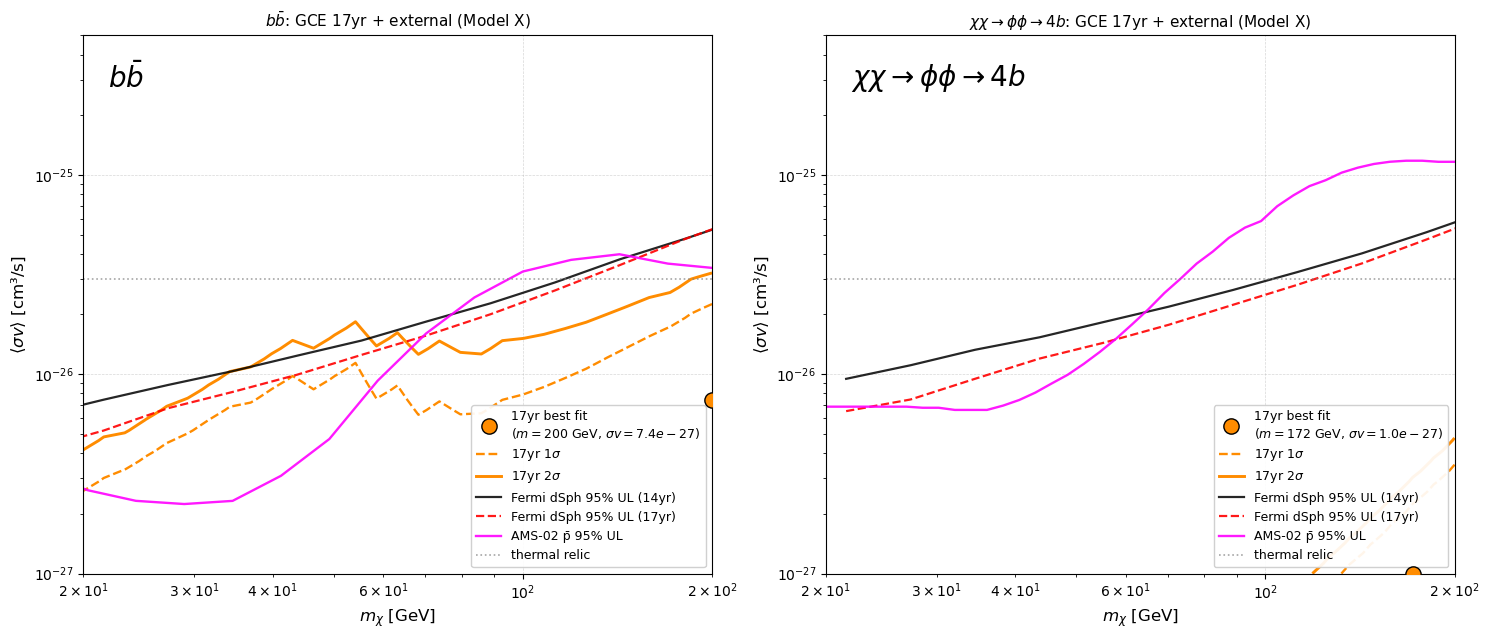

In [64]:
# Cell 16 — Plot 12: bb̄ + 4b contour + dSph + antiproton (graceful fallback)
def _try_load(prefix, fname_options):
    """Load 2-column txt from EXTERNAL_DATA_DIR; return (array, path-found) or (None, None)."""
    if EXTERNAL_DATA_DIR is None:
        return None, None
    for f in fname_options:
        p = f'{EXTERNAL_DATA_DIR}/{f}'
        if os.path.exists(p):
            try:
                d = np.loadtxt(p)
                d = d[d[:, 1] > 1.1e-28]   # filter sentinel rows
                return d, p
            except Exception:
                continue
    return None, None

# dSph
dsph_bb_14, _   = _try_load('bb14',   ['bb_14.0yr_30_dSphs.txt', 'bb_14_0yr_30_dSphs.txt'])
dsph_bb_17, _   = _try_load('bb17',   ['bb_17.0yr_30_dSphs.txt', 'bb_17_0yr_30_dSphs.txt'])
dsph_4b_14, _   = _try_load('4b14',   ['bbbb_14.0yr_30_dSphs.txt', 'bbbb_14_0yr_30_dSphs.txt'])
dsph_4b_17, _   = _try_load('4b17',   ['bbbb_17.0yr_30_dSphs.txt', 'bbbb_17_0yr_30_dSphs.txt'])
# Antiproton
ap_bb_17, _     = _try_load('apbb',   ['2b_phi_avg_prior_True_data_model_cov.txt',
                                       '2b_phi_avg_data_model_cov.txt',
                                       'antiproton_2b_17yr.txt'])
ap_4b_17, _     = _try_load('ap4b',   ['4b_phi_avg_prior_True_data_model_cov.txt',
                                       '4b_phi_avg_data_model_cov.txt',
                                       'antiproton_4b_17yr.txt'])

print('External constraint files:')
print(f'  dSph bb̄ 14yr: {"✓ " + str(len(dsph_bb_14)) + " pts" if dsph_bb_14 is not None else "✗"}')
print(f'  dSph bb̄ 17yr: {"✓ " + str(len(dsph_bb_17)) + " pts" if dsph_bb_17 is not None else "✗"}')
print(f'  dSph 4b 14yr: {"✓ " + str(len(dsph_4b_14)) + " pts" if dsph_4b_14 is not None else "✗"}')
print(f'  dSph 4b 17yr: {"✓ " + str(len(dsph_4b_17)) + " pts" if dsph_4b_17 is not None else "✗"}')
print(f'  AMS-02 bb̄  : {"✓ " + str(len(ap_bb_17)) + " pts" if ap_bb_17 is not None else "✗"}')
print(f'  AMS-02 4b   : {"✓ " + str(len(ap_4b_17)) + " pts" if ap_4b_17 is not None else "✗"}')

if bb_best is None:
    print('\n[skip] bb̄ contour not computed yet — run Cell 14')
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

    panel_specs = [
        ('bb̄', r'$b\bar{b}$', bb_best, 'chi2_bb',
         dsph_bb_14, dsph_bb_17, ap_bb_17),
        ('4b',  r'$\chi\chi\to\phi\phi\to 4b$', mg5_results.get('4b'), 'chi2_4b',
         dsph_4b_14, dsph_4b_17, ap_4b_17),
    ]
    for ax, (label, latex, info, _, d14, d17, ap17) in zip(axes, panel_specs):
        if info is None:
            ax.text(0.5, 0.5, f'{label} contour not available',
                    ha='center', va='center', transform=ax.transAxes, fontsize=12)
            ax.axis('off')
            continue

        chi2_g = info['chi2_grid']
        min_c  = info['min_chi2']
        bm, bs = info['m_DM'], info['sigmav']
        M_g, S_g = np.meshgrid(mass_range, sigmav_range, indexing='ij')
        levels = [min_c + 2.30, min_c + 6.18]
        try:
            ax.contour(M_g, S_g, chi2_g, levels=levels, colors='darkorange',
                       linestyles=['--', '-'], linewidths=[1.7, 2.1])
        except Exception:
            pass
        ax.plot(bm, bs, 'o', color='darkorange', ms=11, mec='black',
                label=f'17yr best fit\n($m={bm:.0f}$ GeV, $\\sigma v={bs:.1e}$)',
                zorder=20)
        ax.plot([], [], '--', color='darkorange', lw=1.7, label=r'17yr 1$\sigma$')
        ax.plot([], [], '-',  color='darkorange', lw=2.1, label=r'17yr 2$\sigma$')

        if d14 is not None:
            ax.plot(d14[:, 0], d14[:, 1], '-', color='black', lw=1.6,
                    alpha=0.85, label='Fermi dSph 95% UL (14yr)')
        if d17 is not None:
            ax.plot(d17[:, 0], d17[:, 1], '--', color='red', lw=1.6,
                    alpha=0.9, label='Fermi dSph 95% UL (17yr)')
        if ap17 is not None:
            ax.plot(ap17[:, 0], ap17[:, 1], '-', color='magenta', lw=1.7,
                    alpha=0.9, label='AMS-02 p̄ 95% UL')

        ax.axhline(3e-26, color='gray', ls=':', lw=1.2, alpha=0.7,
                   label=r'thermal relic')
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlim(20, 200); ax.set_ylim(1e-27, 5e-25)
        ax.set_xlabel(r'$m_\chi$ [GeV]', fontsize=12)
        ax.set_ylabel(r'$\langle\sigma v\rangle$ [cm³/s]', fontsize=12)
        ax.text(0.04, 0.95, latex, transform=ax.transAxes, ha='left', va='top',
                fontsize=20, fontweight='bold')
        ax.set_title(f'{latex}: GCE 17yr + external '
                     f'(Model {SELECTED_MODEL})', fontsize=11)
        ax.grid(True, which='major', ls='--', lw=0.5, alpha=0.5)
        ax.legend(loc='lower right', fontsize=9, framealpha=0.92)

    plt.tight_layout()
    out = f'{PLOTS_DIR}/12_external_constraints.png'
    plt.savefig(out, dpi=140, bbox_inches='tight')
    print(f'\n[saved] {out}')
    plt.show()


## Plot 13 — Cross-Comparison with Cholis 2022 Published Results (NEW)

Two-panel comparison showing analysis evolution from Cholis 2022 (12yr) to this
work (17yr). Useful as a thesis defense slide.

- **Left**: GCE flux for `SELECTED_MODEL` — Cholis Zenodo 12yr vs haebarg 17yr
- **Right**: bb̄ DM contour — Cholis 2022 Fig 18 published curves vs this analysis


[saved] ./GCE_17yr_results_plots/13_cholis_comparison.png


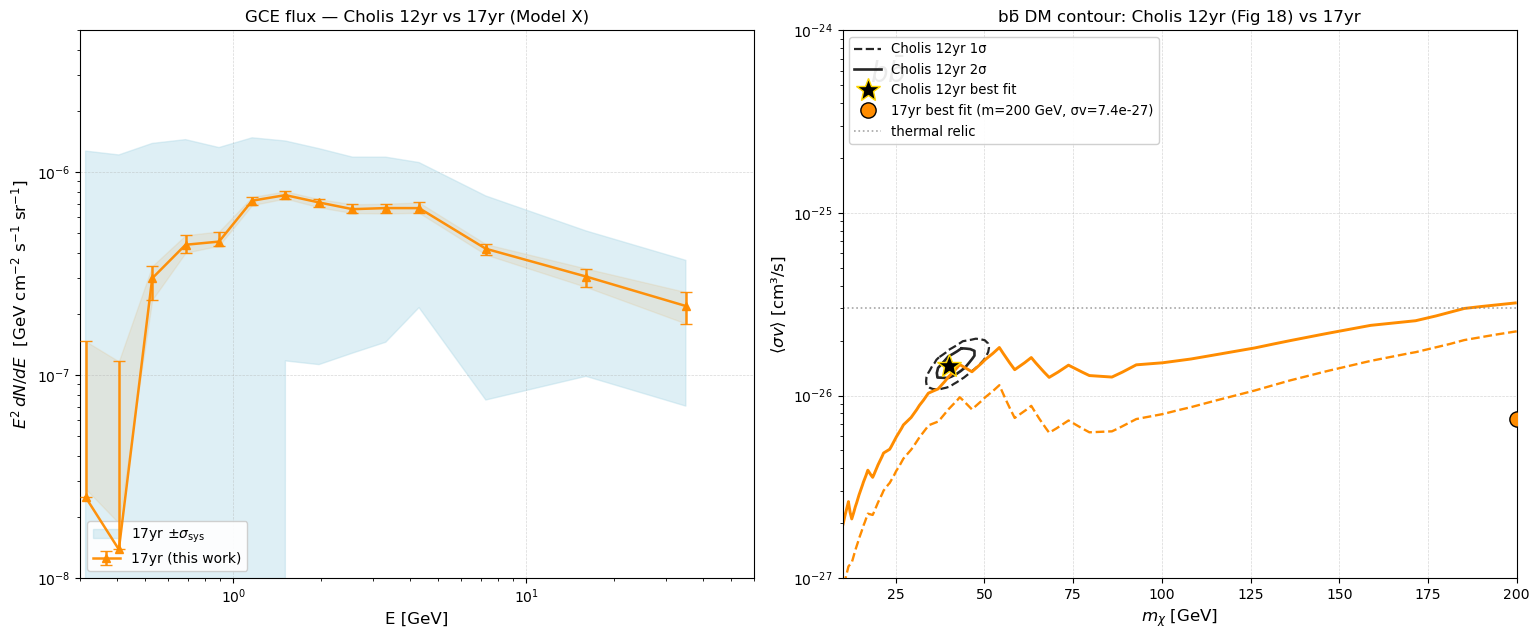

In [65]:
# Cell 17 — Plot 13: Cholis 12yr (published) vs haebarg 17yr
fig, axes = plt.subplots(1, 2, figsize=(15.5, 6.5))

# ---- Left: GCE flux comparison ----
ax = axes[0]
plotted_left = False
cholis_p = f'{CHOLIS_REF_DIR}/GCE_Model{SELECTED_MODEL}_flux_Inner40x40_masked_disk.dat'
if os.path.exists(cholis_p) and SELECTED_MODEL in all_flux:
    cd = np.loadtxt(cholis_p)
    if cd.shape[1] >= 4:
        E_c, f_c, lo_c, hi_c = cd[:, 0], cd[:, 1], cd[:, 2], cd[:, 3]
        yerr_c = [np.maximum(f_c - lo_c, 0), np.maximum(hi_c - f_c, 0)]
        ax.errorbar(E_c, f_c, yerr=yerr_c, marker='s', color='black',
                    ms=6, lw=1.6, capsize=4, label='Cholis+ 2022 (12yr)', zorder=10)
        ax.fill_between(E_c, lo_c, hi_c, color='black', alpha=0.10)
        plotted_left = True

if SELECTED_MODEL in all_flux:
    rm = all_flux[SELECTED_MODEL]
    yerr_h = [np.maximum(rm['flux'] - rm['lower'], 0),
              np.maximum(rm['upper'] - rm['flux'], 0)]
    ax.errorbar(rm['E'], rm['flux'], yerr=yerr_h, marker='^', color='darkorange',
                ms=6, lw=1.8, capsize=4, alpha=0.95,
                label='17yr (this work)', zorder=9)
    ax.fill_between(rm['E'], rm['lower'], rm['upper'],
                    color='darkorange', alpha=0.15)
    if sigma_sys is not None:
        ax.fill_between(rm['E'], rm['flux'] - sigma_sys, rm['flux'] + sigma_sys,
                        color='lightblue', alpha=0.40,
                        label=r'17yr $\pm\sigma_\mathrm{sys}$')
    plotted_left = True

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(0.3, 60); ax.set_ylim(1e-8, 5e-6)
ax.set_xlabel('E [GeV]', fontsize=12)
ax.set_ylabel(r'$E^2\,dN/dE$  [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', fontsize=12)
ax.set_title(f'GCE flux — Cholis 12yr vs 17yr (Model {SELECTED_MODEL})', fontsize=12)
ax.grid(True, which='major', ls='--', lw=0.5, alpha=0.5)
ax.legend(loc='lower left', fontsize=10, framealpha=0.92)
if not plotted_left:
    ax.text(0.5, 0.5, 'Cholis Zenodo flux not found\n(see CHOLIS_REF_DIR)',
            ha='center', va='center', transform=ax.transAxes, fontsize=11)

# ---- Right: bb̄ DM contour comparison ----
ax = axes[1]
plotted_right = False
if CHOLIS_FIG18_DIR is not None:
    def _safe_loadtxt(path):
        if not os.path.exists(path):
            return None
        for sk in (0, 1, 2):
            try:
                return np.loadtxt(path, skiprows=sk)
            except (ValueError, StopIteration):
                continue
        return None
    bf  = _safe_loadtxt(f'{CHOLIS_FIG18_DIR}/2112fig18left_best_fit_point.txt')
    da  = _safe_loadtxt(f'{CHOLIS_FIG18_DIR}/2112fig18left_dashed_line.txt')
    so  = _safe_loadtxt(f'{CHOLIS_FIG18_DIR}/2112fig18left_solid_line.txt')
    SCALE = 1e-26   # Cholis Fig 18 y-axis is in 10⁻²⁶ cm³/s
    for arr in (bf, da, so):
        if arr is None: continue
        if arr.ndim == 1:
            arr[1] *= SCALE
        else:
            arr[:, 1] *= SCALE
    if da is not None and da.ndim == 2 and da.shape[1] >= 2:
        ax.plot(da[:, 0], da[:, 1], '--', color='black', lw=1.6, alpha=0.85,
                label='Cholis 12yr 1σ')
    if so is not None and so.ndim == 2 and so.shape[1] >= 2:
        ax.plot(so[:, 0], so[:, 1], '-',  color='black', lw=1.9, alpha=0.85,
                label='Cholis 12yr 2σ')
    if bf is not None:
        if bf.ndim == 1:
            ax.plot(bf[0], bf[1], '*', color='black', ms=18, mec='gold',
                    label='Cholis 12yr best fit', zorder=12)
        else:
            ax.plot(bf[:, 0], bf[:, 1], '*', color='black', ms=14, mec='gold',
                    label='Cholis 12yr best fit', zorder=12)
    plotted_right = True

if bb_best is not None:
    M_g, S_g = np.meshgrid(mass_range, sigmav_range, indexing='ij')
    lvls = [bb_best['min_chi2'] + 2.30, bb_best['min_chi2'] + 6.18]
    try:
        ax.contour(M_g, S_g, bb_best['chi2_grid'], levels=lvls,
                   colors='darkorange', linestyles=['--', '-'],
                   linewidths=[1.7, 2.1])
    except Exception:
        pass
    ax.plot(bb_best['m_DM'], bb_best['sigmav'], 'o', color='darkorange',
            ms=11, mec='black',
            label=f"17yr best fit (m={bb_best['m_DM']:.0f} GeV, "
                  f"σv={bb_best['sigmav']:.1e})", zorder=11)
    plotted_right = True

ax.axhline(3e-26, color='gray', ls=':', lw=1.2, alpha=0.7, label='thermal relic')
ax.set_yscale('log')
ax.set_xlim(10, 200); ax.set_ylim(1e-27, 1e-24)
ax.set_xlabel(r'$m_\chi$ [GeV]', fontsize=12)
ax.set_ylabel(r'$\langle\sigma v\rangle$ [cm³/s]', fontsize=12)
ax.text(0.04, 0.95, r'$b\bar{b}$', transform=ax.transAxes,
        ha='left', va='top', fontsize=20, fontweight='bold')
ax.set_title(f'bb̄ DM contour: Cholis 12yr (Fig 18) vs 17yr', fontsize=12)
ax.grid(True, which='major', ls='--', lw=0.5, alpha=0.5)
ax.legend(loc='upper left', fontsize=9.5, framealpha=0.92)
if not plotted_right:
    ax.text(0.5, 0.5, 'Cholis Fig 18 reference\nnot available\n'
            '(see CHOLIS_FIG18_CANDIDATES in Cell 1)',
            ha='center', va='center', transform=ax.transAxes, fontsize=11)

plt.tight_layout()
out = f'{PLOTS_DIR}/13_cholis_comparison.png'
plt.savefig(out, dpi=140, bbox_inches='tight')
print(f'[saved] {out}')
plt.show()


## Plot 14 — Best-fit DM SED Overlay

All best-fit DM channel curves drawn on the GCE data, with stat ⊕ sys errors.


[saved] ./GCE_17yr_results_plots/14_best_fit_overlay.png


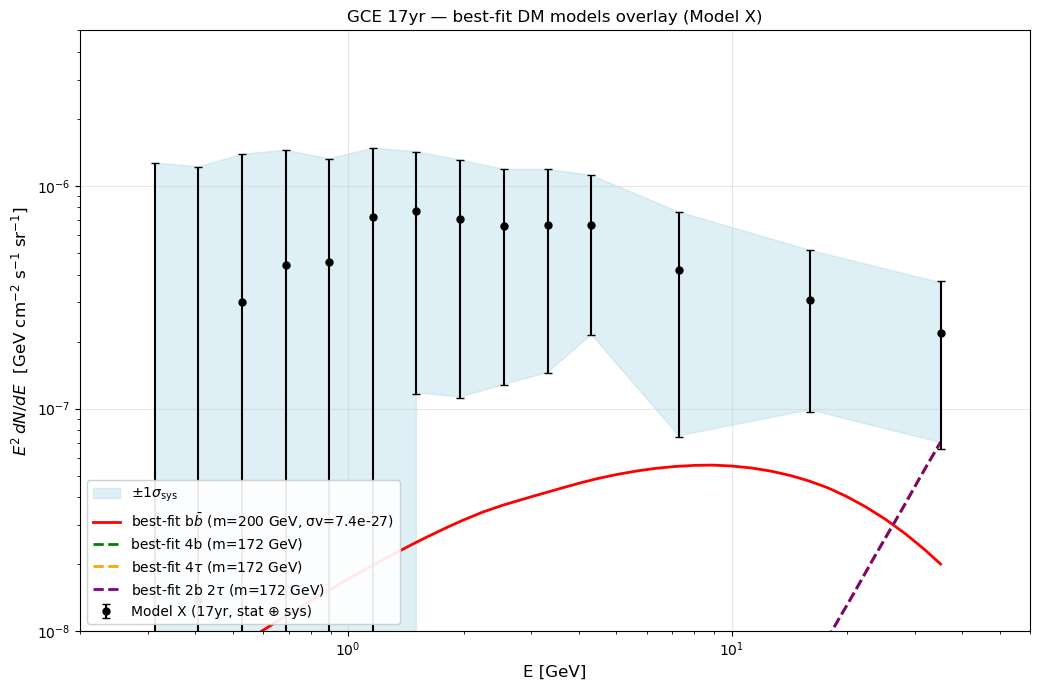

In [66]:
# Cell 18 — Plot 14: Best-fit DM SED overlay
if E is None:
    print('[skip] no GCE data')
else:
    fig, ax = plt.subplots(figsize=(10.5, 7))

    sigma_total = (np.sqrt(stat_err**2 + sigma_sys**2) if sigma_sys is not None
                   else stat_err)
    ax.errorbar(E, flux_X, yerr=sigma_total, fmt='o', color='black',
                ms=5, capsize=3,
                label=f'Model {SELECTED_MODEL} (17yr, stat ⊕ sys)', zorder=4)
    if sigma_sys is not None:
        ax.fill_between(E, flux_X - sigma_sys, flux_X + sigma_sys,
                        color='lightblue', alpha=0.40,
                        label=r'$\pm 1\sigma_\mathrm{sys}$', zorder=2)

    colors = {'bb': 'red', '4b': 'green', '4tau': 'orange', '2b2tau': 'purple'}
    chan_label = {'bb': r'b$\bar{b}$', '4b': '4b', '4tau': r'4$\tau$',
                  '2b2tau': r'2b 2$\tau$'}

    if bb_best is not None:
        E_fine = np.logspace(np.log10(E[0]), np.log10(E[-1]), 200)
        E_pp, dNdE_pp = exctractcirellitable(bb_best['m_DM'], 13, 'gammas', 'Yes')
        valid = (E_pp > 0) & (dNdE_pp > 0)
        f = interp1d(np.log10(E_pp[valid]), np.log10(dNdE_pp[valid]),
                     bounds_error=False, fill_value=-np.inf)
        dNdE_fine = 10**f(np.log10(E_fine))
        dNdE_fine = np.where(np.isfinite(dNdE_fine) & (E_fine < bb_best['m_DM']),
                             dNdE_fine, 0.0)
        flux_dm = (E_fine**2 * dNdE_fine
                   * (bb_best['sigmav'] / bb_best['m_DM']**2) * J_FACTOR / SR)
        ax.plot(E_fine, flux_dm, color=colors['bb'], lw=2,
                label=f"best-fit {chan_label['bb']} "
                      f"(m={bb_best['m_DM']:.0f} GeV, σv={bb_best['sigmav']:.1e})")

    for ch, info in mg5_results.items():
        try:
            E_fine = np.logspace(np.log10(E[0]), np.log10(E[-1]), 200)
            E_mg, dNdE_mg = MG5Interpolator(info['m_DM'], ch).interpolated_table()
            valid = (E_mg > 0) & (dNdE_mg > 0)
            f = interp1d(np.log10(E_mg[valid]), np.log10(dNdE_mg[valid]),
                         bounds_error=False, fill_value=-np.inf)
            dNdE_fine = 10**f(np.log10(E_fine))
            dNdE_fine = np.where(np.isfinite(dNdE_fine) & (E_fine < info['m_DM']),
                                 dNdE_fine, 0.0)
            flux_dm = (E_fine**2 * dNdE_fine
                       * (info['sigmav'] / info['m_DM']**2) * J_FACTOR / SR)
            ax.plot(E_fine, flux_dm, color=colors.get(ch, 'gray'), lw=2, ls='--',
                    label=f"best-fit {chan_label.get(ch, ch)} "
                          f"(m={info['m_DM']:.0f} GeV)")
        except Exception:
            continue

    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(0.2, 60); ax.set_ylim(1e-8, 5e-6)
    ax.set_xlabel('E [GeV]', fontsize=12)
    ax.set_ylabel(r'$E^2\,dN/dE$  [GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', fontsize=12)
    ax.set_title(f'GCE 17yr — best-fit DM models overlay (Model {SELECTED_MODEL})',
                 fontsize=12)
    ax.grid(True, which='major', alpha=0.3)
    ax.legend(loc='lower left', fontsize=10, framealpha=0.92)
    plt.tight_layout()
    out = f'{PLOTS_DIR}/14_best_fit_overlay.png'
    plt.savefig(out, dpi=130, bbox_inches='tight')
    print(f'[saved] {out}')
    plt.show()


In [67]:
# Cell 19 — Summary
print('=' * 64)
print(' Generated visualization outputs')
print('=' * 64)
for f in sorted(glob.glob(f'{PLOTS_DIR}/*.png')):
    sz = os.path.getsize(f) / 1024
    print(f'  {f}   ({sz:.0f} KB)')

print()
print(f'Reference Model:   {SELECTED_MODEL}')
print(f'Models compared:   {[m for m in MODELS_TO_COMPARE if m in coef_dict]}')
print()
print('Best-fit DM summary:')
if bb_best is not None:
    print(f'  bb̄    : m={bb_best["m_DM"]:>6.1f} GeV, '
          f'σv={bb_best["sigmav"]:.2e} cm³/s, TS={bb_best["TS"]:>5.1f}, '
          f'sig={bb_best["sig"]:.1f}σ')
for ch, info in mg5_results.items():
    print(f'  {ch:6s}: m={info["m_DM"]:>6.1f} GeV, '
          f'σv={info["sigmav"]:.2e} cm³/s, TS={info["TS"]:>5.1f}, '
          f'sig={info["sig"]:.1f}σ')


 Generated visualization outputs
  ./GCE_17yr_results_plots/01_gce_map.png   (1923 KB)
  ./GCE_17yr_results_plots/02_masked_map.png   (1450 KB)
  ./GCE_17yr_results_plots/02a_catalog_FL16Y_breakdown.png   (199 KB)
  ./GCE_17yr_results_plots/02b_mask_comparison_DR2_vs_FL16Y.png   (1816 KB)
  ./GCE_17yr_results_plots/03_SED_decomposition_X.png   (88 KB)
  ./GCE_17yr_results_plots/03b_grid_SED_X.png   (218 KB)
  ./GCE_17yr_results_plots/03b_postfit_SED_X_bin0.png   (162 KB)
  ./GCE_17yr_results_plots/04_envelope_best5_FIX1_FIX2.png   (294 KB)
  ./GCE_17yr_results_plots/05_covariance_matrix.png   (75 KB)
  ./GCE_17yr_results_plots/06_coefficient_comparison.png   (218 KB)
  ./GCE_17yr_results_plots/07a_residual_maps_X.png   (2182 KB)
  ./GCE_17yr_results_plots/07b_residual_profiles_X.png   (186 KB)
  ./GCE_17yr_results_plots/08_chi2_bb.png   (88 KB)
  ./GCE_17yr_results_plots/09_chi2_4b.png   (57 KB)
  ./GCE_17yr_results_plots/10_chi2_4tau.png   (56 KB)
  ./GCE_17yr_results_plots/11_chi2_2b

=== yerr 음수 발생 bin (clip 적용 부분) ===


FileNotFoundError: ./GCE_model_XV_front_16yr_cholis.dat not found.

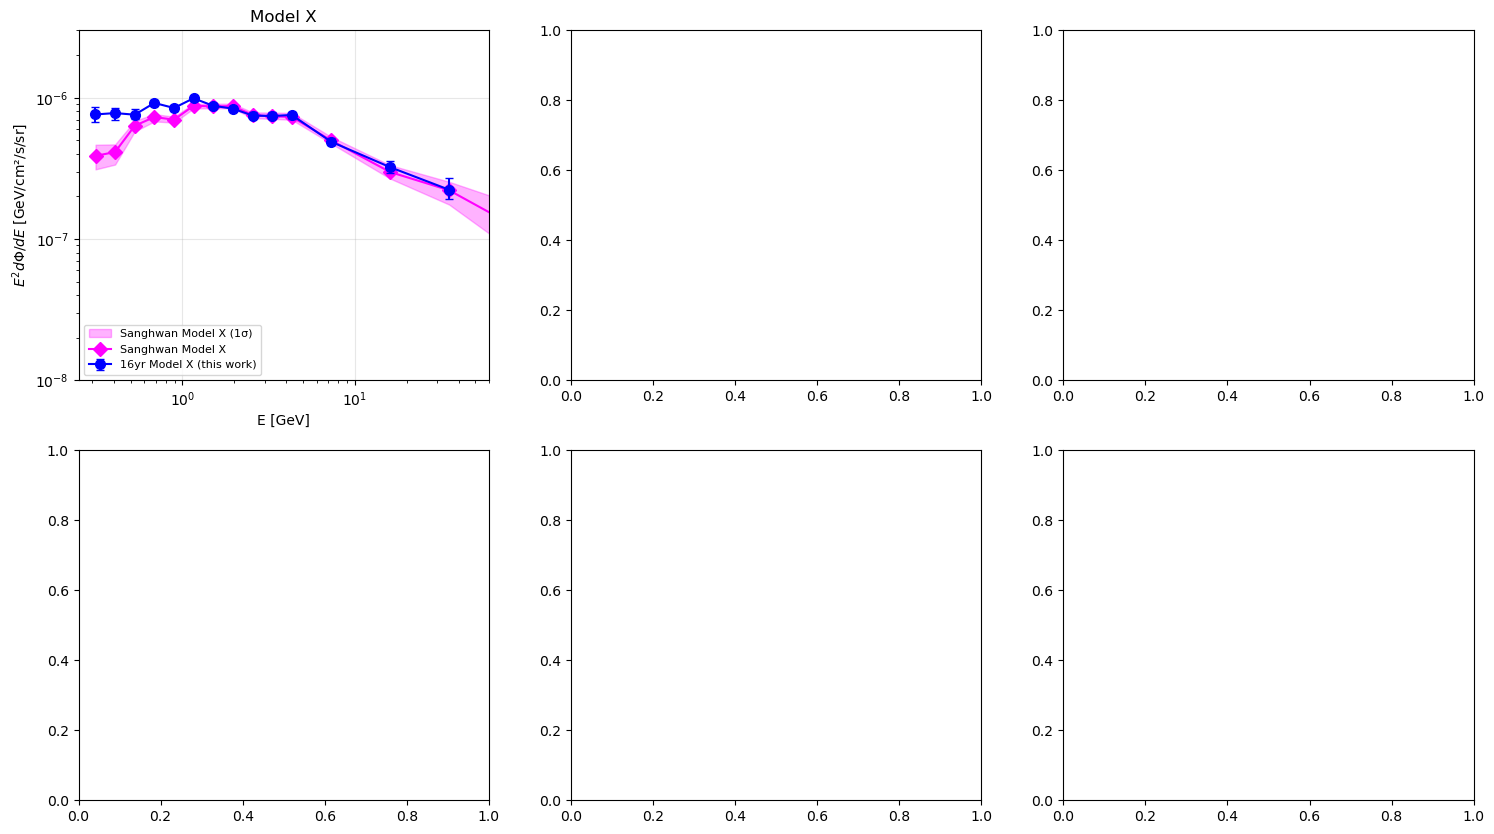

In [2]:
# Cell — Sanghwan 16yr overlay for best 5 GDE models (X, XV, XLVIII, XLIX, LIII)
# yerr 음수 clip + 발생 bin print (별도 진단 영역)
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

SW = '../GCE_16yr_data/Sanghwan_result'
BEST_MODELS = ['X', 'XV', 'XLVIII', 'XLIX', 'LIII']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

print('=== yerr 음수 발생 bin (clip 적용 부분) ===')
for i, N in enumerate(BEST_MODELS):
    ax = axes_flat[i]
    s = np.loadtxt(f'{SW}/GCE_model_{N}_front_16yr_cholis.dat')
    o = np.loadtxt(f'./GCE_model_{N}_front_16yr_cholis.dat')
    raw_lo = o[:, 1] - o[:, 3]
    raw_hi = o[:, 4] - o[:, 1]
    neg_lo = np.where(raw_lo < 0)[0].tolist()
    neg_hi = np.where(raw_hi < 0)[0].tolist()
    if neg_lo or neg_hi:
        print(f'  Model {N:>7}: lo<0 at bins {neg_lo}, hi<0 at bins {neg_hi}')
    yerr_lo = np.clip(raw_lo, 0, None)
    yerr_hi = np.clip(raw_hi, 0, None)

    sw_lo = np.clip(s[:, 1] - s[:, 3], 0, None) if s.shape[1] >= 5 else None
    sw_hi = np.clip(s[:, 4] - s[:, 1], 0, None) if s.shape[1] >= 5 else None
    if sw_lo is not None:
        ax.fill_between(s[:, 0], s[:, 1] - sw_lo, s[:, 1] + sw_hi,
                        alpha=0.3, color='magenta',
                        label=f'Sanghwan Model {N} (1σ)')
    ax.plot(s[:, 0], s[:, 1], 'D-', color='magenta', ms=7,
            label=f'Sanghwan Model {N}')
    ax.errorbar(o[:, 0], o[:, 1],
                yerr=[yerr_lo, yerr_hi],
                fmt='o-', color='blue', ms=7, capsize=3,
                label=f'16yr Model {N} (this work)')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(0.25, 60); ax.set_ylim(1e-8, 3e-6)
    ax.set_xlabel('E [GeV]')
    ax.set_ylabel(r'$E^2 d\Phi/dE$ [GeV/cm²/s/sr]')
    ax.set_title(f'Model {N}')
    ax.legend(loc='lower left', fontsize=8)
    ax.grid(True, alpha=0.3)

axes_flat[5].axis('off')
plt.tight_layout()
out = './overlay_16yr/best5_vs_sanghwan.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
print(f'\n[saved] {out}')

# 1-10 GeV mean ratio (검토 용)
print('\n=== 1-10 GeV mean GCE flux ratio (16yr this work / Sanghwan) ===')
for N in BEST_MODELS:
    s = np.loadtxt(f'{SW}/GCE_model_{N}_front_16yr_cholis.dat')
    o = np.loadtxt(f'./GCE_model_{N}_front_16yr_cholis.dat')
    s_at_us = interp1d(s[:, 0], s[:, 1], fill_value='extrapolate')(o[:, 0])
    ratio = o[:, 1] / s_at_us
    m = (o[:, 0] >= 1) & (o[:, 0] <= 10)
    print(f'  Model {N:>7}: {ratio[m].mean():.3f}')

=== bin 0-2: MAP / median / .dat(col1) / Sanghwan flux 직접 비교 ===
        X bin0-2:  MAP=[7.409958976733197e-07, 7.483927510639935e-07, 7.585928072934307e-07]
                  med=[7.54936840598772e-07, 7.623637616686086e-07, 7.55141779231846e-07]
                 .dat=[7.502216052638889e-07, 7.577100841157884e-07, 7.680378505786034e-07]
                 Sang=[3.8740825840421564e-07, 4.126308041350229e-07, 6.325979602279016e-07]
       XV bin0-2:  MAP=[3.468189883329115e-07, 2.968109554158157e-07, 2.8994176393831875e-07]
                  med=[3.5358201206783343e-07, 3.042695084229441e-07, 3.0177072242466516e-07]
                 .dat=[3.5113702920636727e-07, 3.0050618966427524e-07, 2.9355175402028034e-07]
                 Sang=[1.378728737234556e-09, 2.1806472499084963e-09, 2.0982229678780316e-07]
   XLVIII bin0-2:  MAP=[5.069978440975359e-07, 5.500856582773256e-07, 5.497199433410606e-07]
                  med=[5.454449540783132e-07, 5.470474212768679e-07, 5.464454013538351e-07]
     

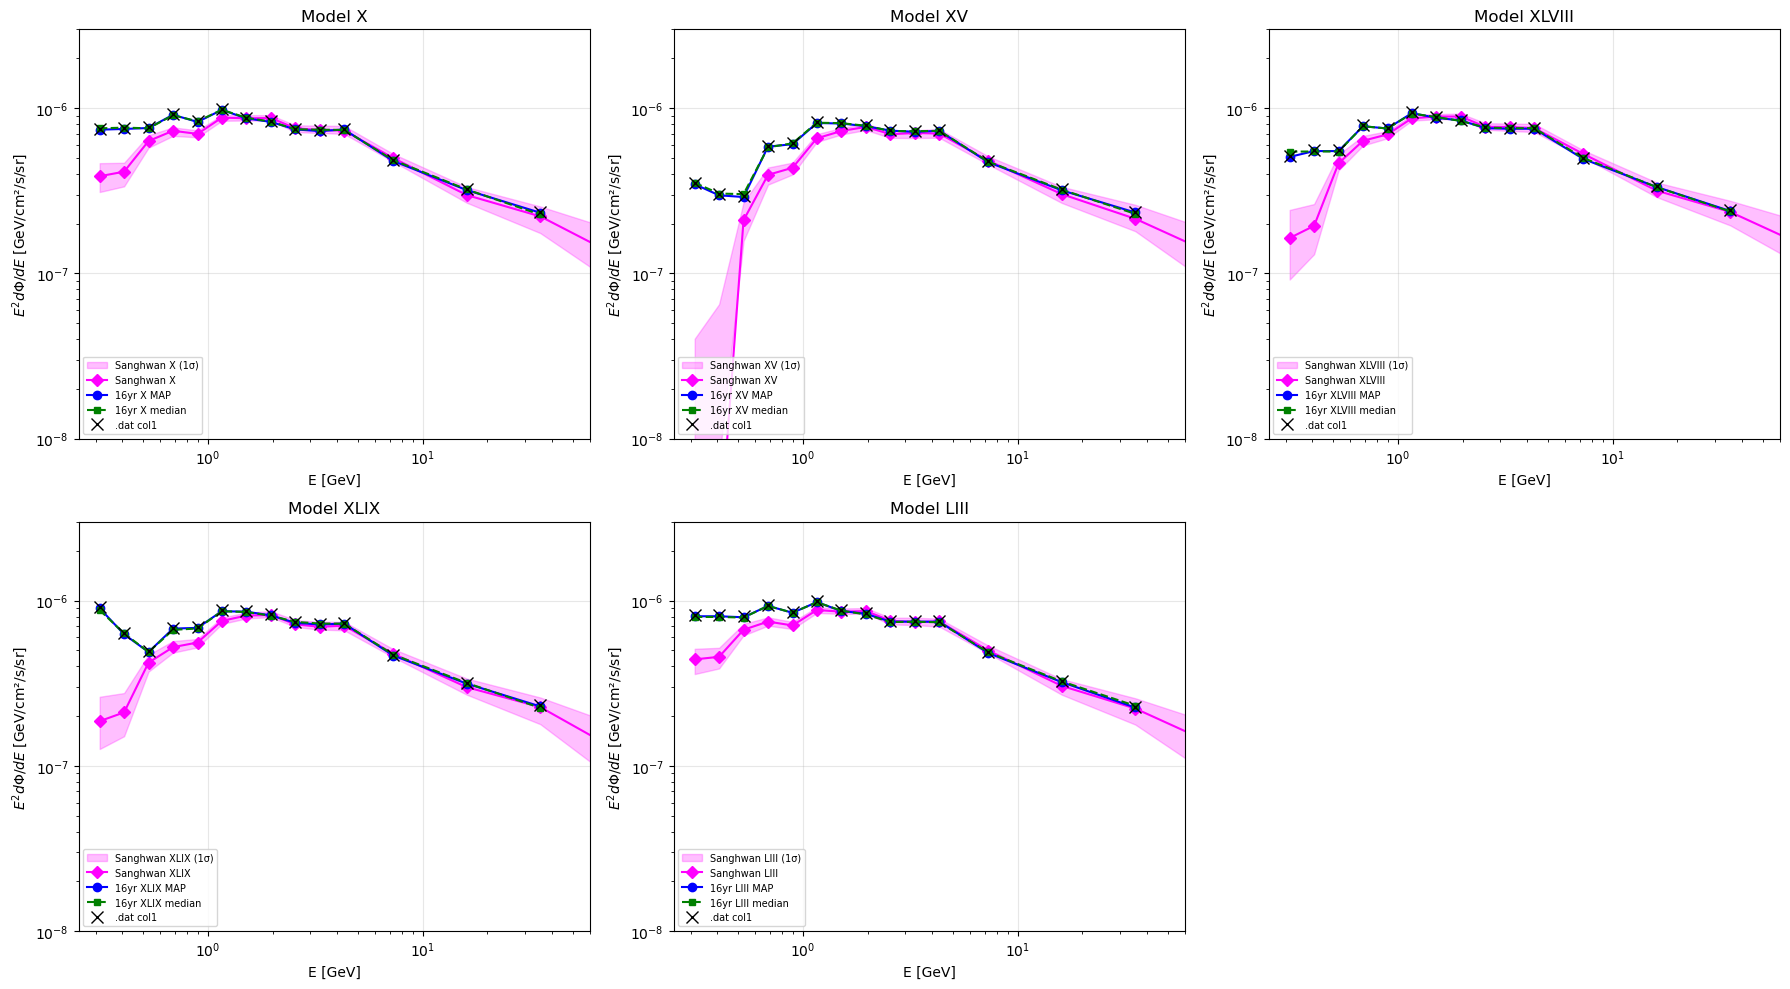

In [1]:
# Cell — MAP vs median vs Sanghwan, 한 panel에 3중 overlay (best 5)
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

SW  = '../GCE_16yr_data/Sanghwan_result'
RES = './results_16yr'
WORK_DIR = './GC_analysis_DR4'
BEST_MODELS = ['X', 'XV', 'XLVIII', 'XLIX', 'LIII']

disk_mask = np.load(f'{WORK_DIR}/Model/GC_disk_mask_60x60_definitions.npy')[100:500, 100:500]
spp = (np.pi/180.0)**2 * (0.1)**2

def _mask_avg_gce(front='_front'):
    exp_cube = (fits.open(f'{WORK_DIR}/GC_expcube_center_16yr{front}_clean.fits')[0].data
                [:, 100:500, 100:500] * spp)
    d = fits.open(f'{WORK_DIR}/GC_GCE_model_16yr{front}_clean_no_convol.fits')[0].data
    return np.array([np.sum(disk_mask*(d[i][100:500,100:500]/exp_cube[i]))/np.sum(disk_mask)
                     for i in range(d.shape[0])])

GCE_arr = _mask_avg_gce()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

print('=== bin 0-2: MAP / median / .dat(col1) / Sanghwan flux 직접 비교 ===')
for i, N in enumerate(BEST_MODELS):
    ax = axes_flat[i]
    s   = np.loadtxt(f'{SW}/GCE_model_{N}_front_16yr_cholis.dat')
    dat = np.loadtxt(f'{RES}/GCE_model_{N}_front_16yr_cholis.dat')
    npz = np.load(f'{RES}/GCE_model_{N}_front_16yr_cholis_fit.npz')

    E  = np.asarray(npz['E']).ravel()
    dE = np.asarray(npz['delta_E']).ravel()

    flux_map = npz['fitted_params'][2]        * GCE_arr * E**2 / dE  # MAP
    flux_med = npz['fitted_params_median'][2] * GCE_arr * E**2 / dE  # median

    # Sanghwan
    ax.fill_between(s[:,0], np.clip(s[:,3],1e-12,None), s[:,4],
                    alpha=0.25, color='magenta', label=f'Sanghwan {N} (1σ)')
    ax.plot(s[:,0], s[:,1], 'D-', color='magenta', ms=6, label=f'Sanghwan {N}')
    # 우리 MAP (.dat col1과 같아야 함)
    ax.plot(E, flux_map, 'o-', color='blue', ms=6, label=f'16yr {N} MAP')
    # 우리 median
    ax.plot(E, flux_med, 's--', color='green', ms=5, label=f'16yr {N} median')
    # .dat col1 (sanity: MAP과 겹쳐야)
    ax.plot(dat[:,0], dat[:,1], 'x', color='black', ms=8, label='.dat col1')

    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlim(0.25, 60); ax.set_ylim(1e-8, 3e-6)
    ax.set_xlabel('E [GeV]'); ax.set_ylabel(r'$E^2 d\Phi/dE$ [GeV/cm²/s/sr]')
    ax.set_title(f'Model {N}')
    ax.legend(loc='lower left', fontsize=7); ax.grid(True, alpha=0.3)

    # bin 0-2 수치 직접 출력
    print(f'  {N:>7} bin0-2:  MAP={flux_map[:3].tolist()}')
    print(f'  {" ":>7}         med={flux_med[:3].tolist()}')
    print(f'  {" ":>7}        .dat={dat[:3,1].tolist()}')
    print(f'  {" ":>7}        Sang={s[:3,1].tolist()}')

axes_flat[5].axis('off')
plt.tight_layout()
out = './overlay_16yr/best5_map_vs_median_vs_sanghwan.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
print(f'\n[saved] {out}')